# PPO–CBF Research Ladder in the Lane-Free Highway Environment

**Canonical default:** PPO in the MTM traffic model. All primary variants use the same 42D learned observation, the same physical 2D action bounds, the same CBF constraints, training budget, seeds, and ten-KPI evaluation protocol.

Research question: **How does progressively integrating a safety constraint—from external intervention, to learning feedback, to differentiable policy architecture—change safety, performance, and dependence on the filter?**

1. **External safety filter:** train nominal PPO once, then evaluate that exact frozen checkpoint with CBF OFF and ON.
2. **CBF-informed reward:** train PPO while the environment executes the hard-projected action; compare shield-only training against intervention/correction reward feedback. No gradient passes through the CBF.
3. **Differentiable final optimization/action layer:** project the PPO mean differentiably, sample and store the latent action (z), and hard-project (z) only for execution. PPO likelihood ratios are computed from the stored latent action. Mean-internalization loss teaches the raw mean to approach the feasible set.

The primary experiment cells are in Section B. Older DDPG material is retained below in a clearly labelled legacy reference section so it cannot be mistaken for the current PPO protocol.

## A. Shared Setup and Common Utilities

### Dependencies

If an import fails, install the dependencies in the selected notebook interpreter:

```python
#!python -m pip install -U stable-baselines3[extra] gymnasium highway-env torch numpy pandas matplotlib pygame qpsolvers osqp clarabel
```

In [2]:
import os
import sys
import json
import copy
import time
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import gymnasium as gym
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from datetime import datetime
from typing import Any, Optional, Union, List, Dict, Tuple, Callable
from stable_baselines3 import DDPG, PPO
from stable_baselines3.common.callbacks import BaseCallback, CallbackList
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise, VectorizedActionNoise
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv

# Initialize variables to avoid "possibly undefined" warnings
PROJECT_ROOT = None
ARTIFACT_DIR = None
DEVICE = "cpu"
SEED = 7
MODEL_PATH = None
HISTORY_PATH = None

# Setup paths for custom environment
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd

env_path = PROJECT_ROOT / "laneless highway env"
if str(env_path) not in sys.path:
    sys.path.insert(0, str(env_path))

try:
    import lane_free_env
except ImportError:
    pass 

# Global Constants & Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "lanelessKaralakou"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# TensorBoard setup
TENSORBOARD_CUSTOM_ROOT = ARTIFACT_DIR / "tensorboard"
try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD_IMPORT_ERROR = None
except ImportError as e:
    TENSORBOARD_IMPORT_ERROR = str(e)
    SummaryWriter = None

print(f"Setup complete. Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")
print(f"Artifacts: {ARTIFACT_DIR}")


Setup complete. Project root: C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making
Device: cpu
Artifacts: C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou


In [3]:
class KaralakouRewardWrapper(gym.Wrapper):
    """Reward wrapper for Fields + Zones + Overtake + Collision Avoidance."""

    def __init__(self, env: gym.Env, reward_config: Optional[dict[str, float]] = None) -> None:
        super().__init__(env)
        self.reward_config = {
            "epsilon_r": 0.4,
            "wx": 1.0,
            "wy": 0.65,
            "wf": 1.0,
            "collision_penalty": -2.5,
            "way": 0.0,
            "overtake_bonus": 0.5,
            "timegap": 0.7,
            "ego_desired_speed": 20.0,
            "field_magnitude": 0.5,
            "field_px": 2.0,
            "field_py": 2.0,
            "field_pt": 1.0,
            "zone_margin": 0.15,
            "progress_reward_weight": 0.0,
            "progress_clip": 1.25,
        }
        if reward_config:
            self.reward_config.update(reward_config)

    @property
    def base_env(self) -> Any:
        return self.env.unwrapped

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.base_env.vehicle.desired_speed = float(self.reward_config["ego_desired_speed"])
        return self._augment_observation(self.base_env._observe()), info

    def step(self, action):
        previous_dx = self._relative_dx_by_vehicle()
        previous_ego_x = float(self.base_env.vehicle.position[0])
        obs, _, terminated, truncated, info = self.env.step(action)
        reward, components = self._karalakou_reward(previous_dx, previous_ego_x)

        info = dict(info)
        info.update({f"karalakou_{key}": value for key, value in components.items()})
        return self._augment_observation(obs), reward, terminated, truncated, info

    def _augment_observation(self, obs: np.ndarray) -> np.ndarray:
        """Put ego lateral y into the otherwise-empty first ego-row slot; hide target_y."""
        augmented = np.asarray(obs, dtype=np.float32).reshape(-1).copy()
        if augmented.size < 2:
            return augmented
        base = self.base_env
        road_width = max(float(base.config["road_width"]), 1e-6)
        ego_y = float(base.vehicle.position[1])
        augmented[0] = np.clip((ego_y - 0.5 * road_width) / (0.5 * road_width), -1.0, 1.0)
        augmented[1] = 0.0
        return augmented.astype(np.float32)

    def _relative_dx_by_vehicle(self) -> dict[int, float]:
        base = self.base_env
        ego = base.vehicle
        return {
            id(vehicle): base._signed_distance(ego.position[0], vehicle.position[0])
            for vehicle in base.road.vehicles
            if vehicle is not ego
        }

    def _karalakou_reward(self, previous_dx: dict[int, float], previous_ego_x: Optional[float] = None) -> tuple[float, dict[str, float]]:
        base = self.base_env
        ego = base.vehicle
        cfg = self.reward_config

        target_y, target_speed, zone_found = self._lateral_target_and_speed()
        ego_y = float(ego.position[1])
        ego_speed = float(ego.vx)
        desired_speed = float(ego.desired_speed)
        road_width = max(float(base.config["road_width"]), 1e-6)
        cx = abs(ego_speed - target_speed) / max(target_speed, 1e-6)
        cy = abs(ego_y - target_y) / road_width
        lat_y_error_m = abs(ego_y - target_y)
        lat_y_coherence = float(np.clip(1.0 - cy, 0.0, 1.0))
        cf = self._potential_field_cost()
        cay = self._lateral_acceleration_cost()
        overtakes = self._overtake_count(previous_dx)
        progress_m = self._forward_progress(previous_ego_x)
        progress_normalized = self._normalized_forward_progress(progress_m, desired_speed)
        progress_clipped = float(np.clip(progress_normalized, 0.0, float(cfg.get("progress_clip", 1.25))))
        progress_reward = float(cfg.get("progress_reward_weight", 0.0)) * progress_clipped

        denom = cfg["epsilon_r"] + cfg["wx"] * cx + cfg["wy"] * cy + cfg["wf"] * cf + cfg.get("way", 0.0) * cay
        reward = cfg["epsilon_r"] / max(denom, 1e-9) + progress_reward
        if bool(base._last_ego_collision):
            reward += cfg["collision_penalty"]
        elif overtakes > 0:
            reward += cfg["overtake_bonus"] * min(overtakes, 1)

        components = {
            "reward": float(reward),
            "cx": float(cx),
            "cy": float(cy),
            "cf": float(cf),
            "cay": float(cay),
            "ay": float(self._ego_lateral_acceleration()),
            "ego_y": float(ego_y),
            "ego_speed": float(ego_speed),
            "desired_speed": float(desired_speed),
            "speed_deviation": float(ego_speed - desired_speed),
            "abs_speed_deviation": float(abs(ego_speed - desired_speed)),
            "target_speed_deviation": float(ego_speed - target_speed),
            "abs_target_speed_deviation": float(abs(ego_speed - target_speed)),
            "target_y": float(target_y),
            "lat_y_error_m": float(lat_y_error_m),
            "lat_y_coherence": float(lat_y_coherence),
            "target_speed": float(target_speed),
            "zone_found": float(zone_found),
            "overtakes": float(overtakes),
            "progress_m": float(progress_m),
            "progress_normalized": float(progress_normalized),
            "progress_clipped": float(progress_clipped),
            "progress_reward": float(progress_reward),
            "ego_collision": float(base._last_ego_collision),
        }
        return float(reward), components

    def _forward_progress(self, previous_ego_x: Optional[float]) -> float:
        if previous_ego_x is None:
            return 0.0
        base = self.base_env
        current_x = float(base.vehicle.position[0])
        return float(max(base._signed_distance(float(previous_ego_x), current_x), 0.0))

    def _policy_dt(self) -> float:
        base = self.base_env
        dt = float(base.config.get("dt", 1.0 / max(float(base.config.get("simulation_frequency", 1.0)), 1e-6)))
        frames = max(1, int(round(float(base.config.get("simulation_frequency", 1.0)) / max(float(base.config.get("policy_frequency", 1.0)), 1e-6))))
        return float(frames * dt)

    def _normalized_forward_progress(self, progress_m: float, desired_speed: float) -> float:
        denom = max(float(desired_speed) * self._policy_dt(), 1e-6)
        return float(max(progress_m, 0.0) / denom)

    def _ego_lateral_acceleration(self) -> float:
        base = self.base_env
        if len(base._last_accelerations) == 0:
            return 0.0
        return float(base._last_accelerations[0, 1])

    def _lateral_acceleration_cost(self) -> float:
        base = self.base_env
        bounds = base.config["bounds"]
        ay_scale = max(abs(float(bounds["ay_min"])), abs(float(bounds["ay_max"])), 1e-6)
        return float(min(abs(self._ego_lateral_acceleration()) / ay_scale, 1.0))

    def _potential_field_cost(self) -> float:
        base = self.base_env
        ego = base.vehicle
        cfg = self.reward_config
        sensing_range = float(base.config["sensing_range"])
        total_cost = 0.0

        for vehicle in base.road.vehicles:
            if vehicle is ego:
                continue
            dx = base._signed_distance(ego.position[0], vehicle.position[0])
            if abs(dx) > sensing_range:
                continue
            dy = float(vehicle.position[1] - ego.position[1])
            critical_a = max(0.5 * (ego.length + vehicle.length), 1e-3)
            critical_b = max(0.5 * (ego.width + vehicle.width), 1e-3)
            broad_a = critical_a + cfg["timegap"] * max(ego.vx - vehicle.vx, 0.0)
            broad_b = critical_b + cfg["timegap"] * abs(ego.vy - vehicle.vy)

            total_cost += self._ellipsoid(dx, dy, critical_a, critical_b)
            total_cost += self._ellipsoid(dx, dy, broad_a, broad_b)

        return float(min(total_cost, 1.0))

    def _ellipsoid(self, dx: float, dy: float, a: float, b: float) -> float:
        cfg = self.reward_config
        scaled = (abs(dx) / max(a, 1e-6)) ** cfg["field_px"] + (abs(dy) / max(b, 1e-6)) ** cfg["field_py"] + 1.0
        return float(cfg["field_magnitude"] / (scaled ** cfg["field_pt"]))

    def _lateral_target_and_speed(self) -> tuple[float, float, bool]:
        base = self.base_env
        ego = base.vehicle
        road_width = float(base.config["road_width"])
        sensing_range = float(base.config["sensing_range"])
        cfg = self.reward_config
        scan_distance = min(max(ego.vx * cfg["timegap"], 1.0), sensing_range)
        blockers: list[tuple[float, Any]] = []

        for vehicle in base.road.vehicles:
            if vehicle is ego:
                continue
            dx = base._forward_distance(ego.position[0], vehicle.position[0])
            if 0.0 < dx < scan_distance:
                blockers.append((dx, vehicle))

        if not blockers:
            return road_width / 2.0, ego.desired_speed, True

        y_min = ego.width / 2.0
        y_max = road_width - ego.width / 2.0
        free_intervals = [(y_min, y_max)]

        for _, vehicle in blockers:
            blocked_low = float(vehicle.position[1] - 0.5 * (ego.width + vehicle.width) - cfg["zone_margin"])
            blocked_high = float(vehicle.position[1] + 0.5 * (ego.width + vehicle.width) + cfg["zone_margin"])
            blocked_low = max(blocked_low, y_min)
            blocked_high = min(blocked_high, y_max)
            free_intervals = self._subtract_interval(free_intervals, blocked_low, blocked_high)

        free_intervals = [(lo, hi) for lo, hi in free_intervals if hi - lo > 0.05]
        if free_intervals:
            ego_y = float(ego.position[1])

            def interval_distance(interval: tuple[float, float]) -> float:
                lo, hi = interval
                if lo <= ego_y <= hi:
                    return 0.0
                return min(abs(ego_y - lo), abs(ego_y - hi))

            best_low, best_high = min(free_intervals, key=interval_distance)
            return 0.5 * (best_low + best_high), ego.desired_speed, True

        slowest_blocker = min((vehicle for _, vehicle in blockers), key=lambda vehicle: vehicle.vx)
        fastest_blocker = max((vehicle for _, vehicle in blockers), key=lambda vehicle: vehicle.vx)
        target_y = float(np.clip(fastest_blocker.position[1], y_min, y_max))
        target_speed = float(min(float(ego.desired_speed), float(slowest_blocker.vx)))
        return target_y, target_speed, False

    @staticmethod
    def _subtract_interval(intervals: list[tuple[float, float]], low: float, high: float) -> list[tuple[float, float]]:
        if high <= low:
            return intervals
        remaining: list[tuple[float, float]] = []
        for interval_low, interval_high in intervals:
            if high <= interval_low or low >= interval_high:
                remaining.append((interval_low, interval_high))
                continue
            if low > interval_low:
                remaining.append((interval_low, low))
            if high < interval_high:
                remaining.append((high, interval_high))
        return remaining

    def _overtake_count(self, previous_dx: dict[int, float]) -> int:
        base = self.base_env
        ego = base.vehicle
        sensing_range = float(base.config["sensing_range"])
        overtakes = 0
        for vehicle in base.road.vehicles:
            if vehicle is ego:
                continue
            old_dx = previous_dx.get(id(vehicle))
            if old_dx is None:
                continue
            new_dx = base._signed_distance(ego.position[0], vehicle.position[0])
            if 0.0 < old_dx < sensing_range and new_dx < -0.5 * ego.length:
                overtakes += 1
        return overtakes


### A.1 Experiment Config

The canonical default is the MTM congested/uncertain environment: a 380 m road, 10.2 m width, 55 vehicles, 200 s episodes, a 0.05 s physics step, a 0.10 s policy interval, 5 observed neighbors, and 90 m sensing. Traffic profiles are 45% normal, 30% aggressive, and 25% cautious. The legacy force model is available only through its explicit activation cell.

In [4]:
ENV_CONFIG = {
    "road_length": 380.0,
    "road_width": 10.2,
    "dt": 0.05,
    "simulation_frequency": 20,
    "policy_frequency": 10,
    "vehicles_count": 55,
    "neighbors_count": 5,
    "sensing_range": 90.0,
    # LaneFreeTrafficEnv counts this horizon in physics integrations.
    "episode_steps": 4000,
    "duration": 4000,
    "terminate_on_collision": True,
    "gamma_nudge": 0.0,
    # Canonical experiment default: MTM congested/uncertain traffic.
    "traffic_model": "mtm",
    "mtm": {
        "leader_range": 90.0,
        "profile_probabilities": {"normal": 0.45, "aggressive": 0.30, "cautious": 0.25},
    },
    "bounds": {
        "ax_min": -3.0,
        "ax_max": 3.0,
        "ay_min": -3.0,
        "ay_max": 3.0,
    },
    "ego_controlled": True,
    # Match the controlled vehicle footprint to every surrounding vehicle.
    "ego_dimensions": [3.5, 1.8],
    "vehicle_dimensions": [[3.5, 1.8], [3.5, 1.8]],
    "placeholder_neighbor": [80.0, 10.2, 0.0, 0.0],
    "desired_speed_range": [15.0, 25.0],
    "initial_speed_fraction_range": [0.55, 1.10],
    "observation_vmax": 24.0,
    "observation_vymax": 7.2,
    "screen_width": 900,
    "screen_height": 260,
    "real_time_rendering": True,
}

REWARD_CONFIG = {
    "ego_desired_speed": 20.0,
    "epsilon_r": 0.4,
    "wx": 1.0,
    "wy": 0.65,
    "wf": 1.0,
    "collision_penalty": -2.5,
    "way": 0.0,
    "overtake_bonus": 0.5,
    "timegap": 0.7,
    "progress_reward_weight": 0.0,
    "progress_clip": 1.25,
}
REWARD_CONFIG_EPSILON_01_ABLATION = {**REWARD_CONFIG, "epsilon_r": 0.1}

TRAINING_EPISODES = 625
# LaneFreeTrafficEnv counts episode_steps in physics integrations.
EPISODE_STEPS = 4_000
EPISODE_POLICY_STEPS = int(round(EPISODE_STEPS * ENV_CONFIG["policy_frequency"] / ENV_CONFIG["simulation_frequency"]))
TOTAL_TIMESTEPS = TRAINING_EPISODES * EPISODE_POLICY_STEPS
DDPG_TOTAL_TIMESTEPS = 50_000
DDPG_CBF_TOTAL_TIMESTEPS = 50_000
EVAL_EVERY = EPISODE_POLICY_STEPS
EVAL_EPISODES = 5
TRAIN_EVAL_EVERY = 10_000
TRAIN_EVAL_EPISODES = 2
FINAL_EVAL_EPISODES = 50
PAPER_EVAL_STEPS = EPISODE_STEPS
TASK_DISTANCE_M = float(os.environ.get("LANELESS_TASK_DISTANCE_M", "1000.0"))
TASK_MAX_STEPS = int(os.environ.get("LANELESS_TASK_MAX_STEPS", "3000"))
TASK_TERMINATE_ON_COMPLETION = True
TASK_TERMINATE_ON_TIMEOUT = True
USE_DISTANCE_TASK_EVALUATION = bool(int(os.environ.get("LANELESS_USE_DISTANCE_TASK_EVAL", "1")))
PAPER_RANDOM_SEEDS = list(range(10))
DENSITY_VEHICLE_COUNTS = {70: 35, 90: 45, 120: 60}
NORMALIZE_RL_OBSERVATIONS = False
OBSERVATION_CLIP = 5.0
OBS_VMAX = 24.0
OBS_VYMAX = 0.3 * OBS_VMAX
DDPG_REPLAY_MEMORY = 100_000
DDPG_BATCH_SIZE = 64
DDPG_TAU = 0.001
DDPG_GAMMA = 0.98
DDPG_LEARNING_RATE = 0.001
DDPG_LEARNING_STARTS = 1_000
DDPG_OU_SIGMA = 0.1
# Stable-Baselines3 uses gradient_steps=-1 to match updates to transitions
# collected in the rollout. With train_freq=(1, 'step'), this is UTD = 1.
DDPG_UTD = 1.0
DDPG_GRADIENT_STEPS = -1
# Use up to eight environments in separate processes so CBF/environment
# stepping is genuinely parallel without oversubscribing typical CPUs.
DEFAULT_PARALLEL_ENVS = min(8, max(1, (os.cpu_count() or 1) // 2))
DDPG_NUM_ENVS = int(os.environ.get("LANELESS_DDPG_NUM_ENVS", DEFAULT_PARALLEL_ENVS))
DDPG_CBF_NUM_ENVS = int(os.environ.get("LANELESS_DDPG_CBF_NUM_ENVS", DDPG_NUM_ENVS))
DDPG_USE_SUBPROC_VEC_ENV = bool(int(os.environ.get("LANELESS_USE_SUBPROC", "1")))
DDPG_SUBPROC_START_METHOD = os.environ.get("LANELESS_SUBPROC_START_METHOD", "spawn")
# Keep detailed traces, but avoid repeatedly rewriting growing CSV files and
# emitting dozens of TensorBoard scalars on every environment transition.
DDPG_STEP_TRACE_SAVE_FREQ = int(os.environ.get("LANELESS_STEP_TRACE_SAVE_FREQ", "25000"))
DDPG_TENSORBOARD_WRITE_FREQ = int(os.environ.get("LANELESS_TB_WRITE_FREQ", "20"))
if "SEED" not in globals():
    SEED = 7

if "MODEL_PATH" not in globals():
    MODEL_PATH = ARTIFACT_DIR / "ppo_laneless_karalakou.zip"
if "HISTORY_PATH" not in globals():
    HISTORY_PATH = ARTIFACT_DIR / "ppo_laneless_karalakou_eval_history.csv"
PLOT_PATH = ARTIFACT_DIR / "ppo_laneless_karalakou_metrics.png"
DDPG_MODEL_PATH = ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou.zip"
DDPG_HISTORY_PATH = ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_eval_history.csv"
DDPG_PLOT_PATH = ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_metrics.png"
DDPG_CBF_MODEL_PATH = ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou.zip"
DDPG_CBF_HISTORY_PATH = ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_eval_history.csv"
DDPG_CBF_PLOT_PATH = ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_metrics.png"


In [5]:
class LaneFreeObservationNormalizationWrapper(gym.ObservationWrapper):
    """Optional scaler for the 24D paper-state observation; keep disabled for flat 42D legacy observations."""

    def __init__(self, env: gym.Env, clip: float = OBSERVATION_CLIP) -> None:
        super().__init__(env)
        self.clip = float(clip)
        self.observation_space = gym.spaces.Box(
            low=-self.clip,
            high=self.clip,
            shape=self.env.observation_space.shape,
            dtype=np.float32,
        )

    @property
    def base_env(self):
        return self.env.unwrapped

    def observation(self, observation: np.ndarray) -> np.ndarray:
        obs = np.asarray(observation, dtype=np.float32).reshape(-1).copy()
        config = self.base_env.config
        road_width = max(float(config["road_width"]), 1e-6)
        sensing_range = max(float(config["sensing_range"]), 1e-6)
        v_max = max(float(OBS_VMAX), 1e-6)
        vy_max = max(float(OBS_VYMAX), 1e-6)

        if obs.size >= 4:
            obs[0] = (obs[0] - 0.5 * road_width) / (0.5 * road_width)
            obs[1] = obs[1] / v_max
            obs[2] = obs[2] / vy_max
            obs[3] = obs[3] / v_max

        for start in range(4, obs.size, 4):
            obs[start] = obs[start] / sensing_range
            obs[start + 1] = obs[start + 1] / road_width
            obs[start + 2] = obs[start + 2] / v_max
            obs[start + 3] = obs[start + 3] / vy_max

        return np.clip(obs, -self.clip, self.clip).astype(np.float32)


class TaskProgressWrapper(gym.Wrapper):
    """Track an x-meter driving task and optionally end the episode on completion/timeout."""

    def __init__(
        self,
        env: gym.Env,
        task_distance_m: float = TASK_DISTANCE_M,
        max_steps: Optional[int] = TASK_MAX_STEPS,
        terminate_on_completion: bool = TASK_TERMINATE_ON_COMPLETION,
        terminate_on_timeout: bool = TASK_TERMINATE_ON_TIMEOUT,
    ) -> None:
        super().__init__(env)
        self.task_distance_m = float(max(task_distance_m, 1e-6))
        self.max_steps = None if max_steps is None else int(max_steps)
        self.terminate_on_completion = bool(terminate_on_completion)
        self.terminate_on_timeout = bool(terminate_on_timeout)
        self._task_steps = 0
        self._task_start_x = 0.0
        self._task_last_x = 0.0
        self._task_distance_traveled_m = 0.0

    def _ego_x(self) -> float:
        return float(self.unwrapped.vehicle.position[0])

    def _forward_delta(self, previous_x: float, current_x: float) -> float:
        base = self.unwrapped
        if hasattr(base, "_signed_distance"):
            delta = float(base._signed_distance(previous_x, current_x))
        else:
            delta = float(current_x - previous_x)
        return float(max(delta, 0.0))

    def _task_info(self, *, step_progress_m: float = 0.0) -> dict[str, Any]:
        progress_ratio = float(np.clip(self._task_distance_traveled_m / self.task_distance_m, 0.0, np.inf))
        completed = bool(self._task_distance_traveled_m >= self.task_distance_m)
        timeout = bool(self.max_steps is not None and self._task_steps >= self.max_steps and not completed)
        return {
            "task_distance_m": float(self.task_distance_m),
            "task_distance_traveled_m": float(self._task_distance_traveled_m),
            "task_step_progress_m": float(step_progress_m),
            "task_progress_ratio": progress_ratio,
            "task_completed": completed,
            "task_timeout": timeout,
            "task_steps": float(self._task_steps),
        }

    def reset(self, *args, **kwargs):
        obs, info = self.env.reset(*args, **kwargs)
        self._task_steps = 0
        self._task_start_x = self._ego_x()
        self._task_last_x = self._task_start_x
        self._task_distance_traveled_m = 0.0
        info = dict(info)
        info.update(self._task_info(step_progress_m=0.0))
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        current_x = self._ego_x()
        step_progress_m = self._forward_delta(self._task_last_x, current_x)
        self._task_last_x = current_x
        self._task_steps += 1
        self._task_distance_traveled_m += step_progress_m
        task_info = self._task_info(step_progress_m=step_progress_m)
        if self.terminate_on_completion and bool(task_info["task_completed"]):
            terminated = True
        if self.terminate_on_timeout and bool(task_info["task_timeout"]):
            truncated = True
        info = dict(info)
        info.update(task_info)
        return obs, reward, terminated, truncated, info


def task_progress_config(
    *,
    terminate_on_completion: bool,
    terminate_on_timeout: bool,
    task_distance_m: float = TASK_DISTANCE_M,
    max_steps: Optional[int] = TASK_MAX_STEPS,
) -> dict[str, Any]:
    return {
        "task_distance_m": float(task_distance_m),
        "max_steps": None if max_steps is None else int(max_steps),
        "terminate_on_completion": bool(terminate_on_completion),
        "terminate_on_timeout": bool(terminate_on_timeout),
    }


def wrap_task_progress_env(env: gym.Env, task_config: Optional[dict[str, Any]]) -> gym.Env:
    if task_config is None:
        return env
    return TaskProgressWrapper(env, **task_config)



KPI_DEFAULT_INTERVENTION_THRESHOLD = 0.03
KPI_ACTION_SATURATION_TOL = 1e-3
KPI_NEIGHBOR_DENSITY_WINDOW_M = 2.0


def _kpi_scalar(value: Any, default: float = np.nan) -> float:
    if value is None:
        return default
    if isinstance(value, (bool, np.bool_)):
        return float(value)
    if isinstance(value, (list, tuple, np.ndarray)):
        array = np.asarray(value, dtype=float).reshape(-1)
        if array.size != 1:
            return default
        value = array[0]
    try:
        scalar = float(value)
    except (TypeError, ValueError):
        return default
    return scalar if np.isfinite(scalar) else default


def _kpi_first(info: dict[str, Any], keys: list[str], default: float = np.nan) -> float:
    for key in keys:
        if key not in info:
            continue
        value = _kpi_scalar(info.get(key), default=np.nan)
        if np.isfinite(value):
            return value
    return default


def _kpi_base_env(env: gym.Env):
    return env.unwrapped


def kpi_policy_dt(env: gym.Env) -> float:
    base = _kpi_base_env(env)
    config = getattr(base, "config", {})
    dt = float(config.get("dt", 1.0 / max(float(config.get("simulation_frequency", 1.0)), 1e-6)))
    frames = max(
        1,
        int(round(float(config.get("simulation_frequency", 1.0)) / max(float(config.get("policy_frequency", 1.0)), 1e-6))),
    )
    return float(frames * dt)


def _kpi_default_eps_side(env: gym.Env) -> float:
    if "CBF_EPS_SIDE" in globals():
        return float(globals()["CBF_EPS_SIDE"])
    base = _kpi_base_env(env)
    config = getattr(base, "config", {})
    ego_width = float(config.get("ego_dimensions", [3.5, 1.8])[1])
    social_dims = config.get("vehicle_dimensions", [[3.5, 1.8], [3.5, 1.8]])
    social_width = float(social_dims[0][1]) if social_dims else ego_width
    return float(max((3.0 - (ego_width + social_width) / np.sqrt(2.0)) / 4.0, 0.0))


def _kpi_inflated_axes(length: float, width: float, eps_side: float) -> tuple[float, float]:
    a = float(length) / np.sqrt(2.0) + 2.0 * float(eps_side)
    b = float(width) / np.sqrt(2.0) + 2.0 * float(eps_side)
    return max(a, 1e-6), max(b, 1e-6)


def _kpi_wrap_angle(angle: float) -> float:
    return float((float(angle) + np.pi) % (2.0 * np.pi) - np.pi)


def _kpi_ellipse_radius(a: float, b: float, delta: float) -> float:
    cos_delta = np.cos(float(delta))
    sin_delta = np.sin(float(delta))
    denom = np.sqrt((float(b) * cos_delta) ** 2 + (float(a) * sin_delta) ** 2)
    return float(float(a) * float(b) / max(float(denom), 1e-9))


def _kpi_current_acceleration(env: gym.Env) -> np.ndarray:
    base = _kpi_base_env(env)
    accelerations = getattr(base, "_last_accelerations", None)
    if accelerations is None:
        return np.asarray([np.nan, np.nan], dtype=float)
    array = np.asarray(accelerations, dtype=float)
    if array.size < 2:
        return np.asarray([np.nan, np.nan], dtype=float)
    return array.reshape((-1, 2))[0].astype(float)


def _kpi_action_bounds(env: gym.Env) -> tuple[np.ndarray, np.ndarray]:
    base = _kpi_base_env(env)
    bounds = getattr(base, "config", {}).get("bounds", {})
    low = np.asarray([float(bounds.get("ax_min", -np.inf)), float(bounds.get("ay_min", -np.inf))], dtype=float)
    high = np.asarray([float(bounds.get("ax_max", np.inf)), float(bounds.get("ay_max", np.inf))], dtype=float)
    return low, high


def _kpi_saturation(action: np.ndarray, low: np.ndarray, high: np.ndarray, tol: float = KPI_ACTION_SATURATION_TOL) -> tuple[float, float, float]:
    action = np.asarray(action, dtype=float).reshape(-1)[:2]
    sat_x = float(np.isfinite(action[0]) and (abs(action[0] - low[0]) <= tol or abs(action[0] - high[0]) <= tol))
    sat_y = float(np.isfinite(action[1]) and (abs(action[1] - low[1]) <= tol or abs(action[1] - high[1]) <= tol))
    return sat_x, sat_y, float(0.5 * (sat_x + sat_y))


def _kpi_relative_dx_by_vehicle(env: gym.Env) -> dict[int, float]:
    base = _kpi_base_env(env)
    ego = getattr(base, "vehicle", None)
    road = getattr(base, "road", None)
    if ego is None or road is None:
        return {}
    result: dict[int, float] = {}
    for vehicle in getattr(road, "vehicles", []):
        if vehicle is ego:
            continue
        if hasattr(base, "_signed_distance"):
            dx = float(base._signed_distance(ego.position[0], vehicle.position[0]))
        else:
            dx = float(vehicle.position[0] - ego.position[0])
        result[id(vehicle)] = dx
    return result


def kpi_neighbor_and_h_metrics(env: gym.Env, eps_side: Optional[float] = None, neighbor_range: Optional[float] = None) -> dict[str, float]:
    base = _kpi_base_env(env)
    ego = getattr(base, "vehicle", None)
    road = getattr(base, "road", None)
    config = getattr(base, "config", {})
    if ego is None or road is None:
        return {
            "kpi_neighbor_count": 0.0,
            "kpi_neighbor_density_per_km": 0.0,
            "kpi_h_min": np.nan,
            "kpi_pairwise_h_min": np.nan,
            "kpi_boundary_h_min": np.nan,
            "kpi_min_center_distance_m": np.nan,
            "kpi_min_required_distance_m": np.nan,
        }

    eps = _kpi_default_eps_side(env) if eps_side is None else float(eps_side)
    sensing_range = float(config.get("sensing_range", 80.0) if neighbor_range is None else neighbor_range)
    road_width = float(config.get("road_width", np.nan))
    ego_y = float(ego.position[1])
    ego_width = float(getattr(ego, "width", config.get("ego_dimensions", [3.5, 1.8])[1]))
    left_h = ego_y - 0.5 * ego_width
    right_h = road_width - 0.5 * ego_width - ego_y if np.isfinite(road_width) else np.nan
    boundary_h = float(np.nanmin([left_h, right_h])) if np.isfinite(left_h) or np.isfinite(right_h) else np.nan

    h_values: list[float] = []
    center_distances: list[float] = []
    required_distances: list[float] = []
    neighbor_count = 0
    for vehicle in getattr(road, "vehicles", []):
        if vehicle is ego:
            continue
        if hasattr(base, "_signed_distance"):
            dx = float(base._signed_distance(ego.position[0], vehicle.position[0]))
        else:
            dx = float(vehicle.position[0] - ego.position[0])
        dy = float(vehicle.position[1] - ego.position[1])
        center_distance = float(np.hypot(dx, dy))
        if center_distance > sensing_range:
            continue
        neighbor_count += 1
        phi = float(np.arctan2(dy, dx)) if center_distance > 1e-9 else 0.0
        ego_a, ego_b = _kpi_inflated_axes(float(ego.length), float(ego.width), eps)
        other_a, other_b = _kpi_inflated_axes(float(vehicle.length), float(vehicle.width), eps)
        ego_radius = _kpi_ellipse_radius(ego_a, ego_b, _kpi_wrap_angle(phi - float(getattr(ego, "heading", 0.0))))
        other_radius = _kpi_ellipse_radius(other_a, other_b, _kpi_wrap_angle(phi - float(getattr(vehicle, "heading", 0.0))))
        required_distance = float(ego_radius + other_radius)
        h_values.append(float(center_distance - required_distance))
        center_distances.append(center_distance)
        required_distances.append(required_distance)

    window_km = max(2.0 * sensing_range / 1000.0, 1e-6)
    return {
        "kpi_neighbor_count": float(neighbor_count),
        "kpi_neighbor_density_per_km": float(neighbor_count / window_km),
        "kpi_h_min": float(np.min(h_values)) if h_values else np.nan,
        "kpi_pairwise_h_min": float(np.min(h_values)) if h_values else np.nan,
        "kpi_boundary_h_min": boundary_h,
        "kpi_min_center_distance_m": float(np.min(center_distances)) if center_distances else np.nan,
        "kpi_min_required_distance_m": float(np.min(required_distances)) if required_distances else np.nan,
    }


class KPIInfoWrapper(gym.Wrapper):
    """Attach task, safety, efficiency, comfort, filter, and traffic KPI fields to info."""

    def __init__(
        self,
        env: gym.Env,
        intervention_threshold: float = KPI_DEFAULT_INTERVENTION_THRESHOLD,
        action_saturation_tol: float = KPI_ACTION_SATURATION_TOL,
    ) -> None:
        super().__init__(env)
        self.intervention_threshold = float(intervention_threshold)
        self.action_saturation_tol = float(action_saturation_tol)
        self._episode_steps = 0
        self._episode_time_s = 0.0
        self._episode_distance_m = 0.0
        self._episode_lateral_shift_m = 0.0
        self._episode_ego_collisions = 0.0
        self._episode_total_collisions = 0.0
        self._previous_y = np.nan
        self._previous_acceleration: Optional[np.ndarray] = None
        self._previous_dx_by_vehicle: dict[int, float] = {}

    def _reset_kpi_state(self) -> None:
        base = _kpi_base_env(self)
        ego = getattr(base, "vehicle", None)
        self._episode_steps = 0
        self._episode_time_s = 0.0
        self._episode_distance_m = 0.0
        self._episode_lateral_shift_m = 0.0
        self._episode_ego_collisions = 0.0
        self._episode_total_collisions = 0.0
        self._previous_y = float(ego.position[1]) if ego is not None else np.nan
        self._previous_acceleration = None
        self._previous_dx_by_vehicle = _kpi_relative_dx_by_vehicle(self)

    def reset(self, *args, **kwargs):
        obs, info = self.env.reset(*args, **kwargs)
        self._reset_kpi_state()
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        info = dict(info)
        self._episode_steps += 1
        dt = kpi_policy_dt(self)
        self._episode_time_s += dt

        base = _kpi_base_env(self)
        ego = getattr(base, "vehicle", None)
        speed = float(getattr(ego, "vx", np.nan)) if ego is not None else np.nan
        desired_speed = float(getattr(ego, "desired_speed", np.nan)) if ego is not None else np.nan
        speed_deviation = speed - desired_speed if np.isfinite(speed) and np.isfinite(desired_speed) else np.nan
        progress_m = _kpi_first(info, ["task_step_progress_m", "karalakou_progress_m"], default=np.nan)
        if not np.isfinite(progress_m):
            progress_m = 0.0
        progress_m = float(max(progress_m, 0.0))
        self._episode_distance_m = float(max(_kpi_first(info, ["task_distance_traveled_m"], default=self._episode_distance_m + progress_m), self._episode_distance_m + progress_m))
        distance_km = self._episode_distance_m / 1000.0

        current_y = float(ego.position[1]) if ego is not None else np.nan
        lateral_shift_step = float(abs(current_y - self._previous_y)) if np.isfinite(current_y) and np.isfinite(self._previous_y) else 0.0
        self._episode_lateral_shift_m += lateral_shift_step

        acceleration = _kpi_current_acceleration(self)
        if self._previous_acceleration is None or not np.all(np.isfinite(self._previous_acceleration)):
            delta_acc = np.asarray([np.nan, np.nan], dtype=float)
            jerk = np.asarray([np.nan, np.nan], dtype=float)
        else:
            delta_acc = acceleration - self._previous_acceleration
            jerk = delta_acc / max(dt, 1e-6)
        low, high = _kpi_action_bounds(self)
        sat_x, sat_y, sat_rate = _kpi_saturation(acceleration, low, high, tol=self.action_saturation_tol)

        raw_action = np.asarray(
            [
                _kpi_first(info, ["cbf_a_rl_x"], default=acceleration[0]),
                _kpi_first(info, ["cbf_a_rl_y"], default=acceleration[1]),
            ],
            dtype=float,
        )
        safe_action = np.asarray(
            [
                _kpi_first(info, ["cbf_a_safe_x"], default=acceleration[0]),
                _kpi_first(info, ["cbf_a_safe_y"], default=acceleration[1]),
            ],
            dtype=float,
        )
        raw_safe_gap = safe_action - raw_action
        raw_safe_gap_norm = float(np.linalg.norm(raw_safe_gap)) if np.all(np.isfinite(raw_safe_gap)) else 0.0
        correction_norm = _kpi_first(info, ["cbf_correction_norm", "correction_norm"], default=raw_safe_gap_norm)
        event_threshold = float(_kpi_first(info, ["cbf_event_intervention_threshold"], default=self.intervention_threshold))
        meaningful_intervention = float(bool(info.get("cbf_event_intervened", info.get("intervention", correction_norm > event_threshold))))
        numerical_intervention = float(bool(info.get("cbf_intervened", correction_norm > 1e-6)))
        meaningful_correction_norm = _kpi_first(
            info,
            ["cbf_meaningful_correction_norm", "meaningful_correction_norm"],
            default=max(float(correction_norm) - event_threshold, 0.0),
        )

        qp_attempt = float("cbf_qp_success" in info or "qp_success" in info)
        qp_success = bool(info.get("cbf_qp_success", info.get("qp_success", True)))
        qp_failure = float(qp_attempt > 0.5 and not qp_success)

        ego_collision_events = _kpi_first(info, ["ego_collision_events"], default=0.0)
        if ego_collision_events <= 0.0 and bool(info.get("ego_collision", False)):
            ego_collision_events = 1.0
        total_collision_events = _kpi_first(info, ["collisions", "total_collision_events"], default=0.0)
        self._episode_ego_collisions += float(ego_collision_events)
        self._episode_total_collisions += float(total_collision_events)

        current_dx = _kpi_relative_dx_by_vehicle(self)
        computed_overtakes = 0.0
        computed_overtaken = 0.0
        ego_length = float(getattr(ego, "length", 0.0)) if ego is not None else 0.0
        for vehicle_id, old_dx in self._previous_dx_by_vehicle.items():
            if vehicle_id not in current_dx:
                continue
            new_dx = current_dx[vehicle_id]
            if 0.0 < old_dx and new_dx < -0.5 * ego_length:
                computed_overtakes += 1.0
            if old_dx < 0.0 and new_dx > 0.5 * ego_length:
                computed_overtaken += 1.0
        reward_overtakes = _kpi_first(info, ["karalakou_overtakes"], default=0.0)
        overtakes_step = max(computed_overtakes, reward_overtakes)

        neighbor_h = kpi_neighbor_and_h_metrics(self)
        cbf_h = _kpi_first(info, ["cbf_min_h", "min_h"], default=np.nan)
        if np.isfinite(cbf_h):
            if np.isfinite(neighbor_h["kpi_h_min"]):
                neighbor_h["kpi_h_min"] = float(min(neighbor_h["kpi_h_min"], cbf_h))
            else:
                neighbor_h["kpi_h_min"] = float(cbf_h)

        per_km_denom = distance_km if distance_km > 1e-9 else np.nan
        info.update(
            {
                "kpi_dt_s": float(dt),
                "kpi_episode_time_s": float(self._episode_time_s),
                "kpi_step_progress_m": float(progress_m),
                "kpi_distance_traveled_m": float(self._episode_distance_m),
                "kpi_distance_km": float(distance_km),
                "kpi_speed_mps": float(speed),
                "kpi_desired_speed_mps": float(desired_speed),
                "kpi_speed_deviation_mps": float(speed_deviation),
                "kpi_abs_speed_deviation_mps": float(abs(speed_deviation)) if np.isfinite(speed_deviation) else np.nan,
                "kpi_accel_x": float(acceleration[0]),
                "kpi_accel_y": float(acceleration[1]),
                "kpi_abs_accel_x": float(abs(acceleration[0])) if np.isfinite(acceleration[0]) else np.nan,
                "kpi_abs_accel_y": float(abs(acceleration[1])) if np.isfinite(acceleration[1]) else np.nan,
                "kpi_accel_norm": float(np.linalg.norm(acceleration)) if np.all(np.isfinite(acceleration)) else np.nan,
                "kpi_delta_accel_x": float(delta_acc[0]),
                "kpi_delta_accel_y": float(delta_acc[1]),
                "kpi_abs_delta_accel_x": float(abs(delta_acc[0])) if np.isfinite(delta_acc[0]) else np.nan,
                "kpi_abs_delta_accel_y": float(abs(delta_acc[1])) if np.isfinite(delta_acc[1]) else np.nan,
                "kpi_delta_accel_norm": float(np.linalg.norm(delta_acc)) if np.all(np.isfinite(delta_acc)) else np.nan,
                "kpi_jerk_x": float(jerk[0]),
                "kpi_jerk_y": float(jerk[1]),
                "kpi_abs_jerk_x": float(abs(jerk[0])) if np.isfinite(jerk[0]) else np.nan,
                "kpi_abs_jerk_y": float(abs(jerk[1])) if np.isfinite(jerk[1]) else np.nan,
                "kpi_jerk_norm": float(np.linalg.norm(jerk)) if np.all(np.isfinite(jerk)) else np.nan,
                "kpi_action_saturation_x": sat_x,
                "kpi_action_saturation_y": sat_y,
                "kpi_action_saturation_rate": sat_rate,
                "kpi_raw_safe_gap_x": float(raw_safe_gap[0]) if np.isfinite(raw_safe_gap[0]) else np.nan,
                "kpi_raw_safe_gap_y": float(raw_safe_gap[1]) if np.isfinite(raw_safe_gap[1]) else np.nan,
                "kpi_raw_safe_gap_norm": float(raw_safe_gap_norm),
                "kpi_correction_norm": float(correction_norm),
                "kpi_meaningful_correction_norm": float(meaningful_correction_norm),
                "kpi_meaningful_intervention": meaningful_intervention,
                "kpi_numerical_intervention": numerical_intervention,
                "kpi_qp_attempt": qp_attempt,
                "kpi_qp_failure": qp_failure,
                "kpi_ego_collision_events": float(ego_collision_events),
                "kpi_total_collision_events": float(total_collision_events),
                "kpi_episode_ego_collisions": float(self._episode_ego_collisions),
                "kpi_episode_total_collision_events": float(self._episode_total_collisions),
                "kpi_ego_collisions_per_km": float(self._episode_ego_collisions / per_km_denom) if np.isfinite(per_km_denom) else 0.0,
                "kpi_total_collision_events_per_km": float(self._episode_total_collisions / per_km_denom) if np.isfinite(per_km_denom) else 0.0,
                "kpi_lateral_shift_step_m": float(lateral_shift_step),
                "kpi_lateral_shift_total_m": float(self._episode_lateral_shift_m),
                "kpi_overtakes_step": float(overtakes_step),
                "kpi_overtaken_step": float(computed_overtaken),
                **neighbor_h,
            }
        )

        self._previous_y = current_y
        self._previous_acceleration = acceleration.copy()
        self._previous_dx_by_vehicle = current_dx
        return obs, reward, terminated, truncated, info


KPI_STEP_RECORD_KEYS = [
    "kpi_dt_s",
    "kpi_episode_time_s",
    "kpi_step_progress_m",
    "kpi_distance_traveled_m",
    "kpi_distance_km",
    "kpi_speed_mps",
    "kpi_desired_speed_mps",
    "kpi_speed_deviation_mps",
    "kpi_abs_speed_deviation_mps",
    "kpi_h_min",
    "kpi_pairwise_h_min",
    "kpi_boundary_h_min",
    "kpi_qp_attempt",
    "kpi_qp_failure",
    "kpi_ego_collisions_per_km",
    "kpi_total_collision_events_per_km",
    "kpi_accel_x",
    "kpi_abs_accel_x",
    "kpi_accel_y",
    "kpi_abs_accel_y",
    "kpi_accel_norm",
    "kpi_delta_accel_x",
    "kpi_abs_delta_accel_x",
    "kpi_delta_accel_y",
    "kpi_abs_delta_accel_y",
    "kpi_delta_accel_norm",
    "kpi_jerk_x",
    "kpi_abs_jerk_x",
    "kpi_jerk_y",
    "kpi_abs_jerk_y",
    "kpi_jerk_norm",
    "kpi_action_saturation_rate",
    "kpi_raw_safe_gap_norm",
    "kpi_correction_norm",
    "kpi_meaningful_correction_norm",
    "kpi_meaningful_intervention",
    "kpi_numerical_intervention",
    "kpi_lateral_shift_step_m",
    "kpi_lateral_shift_total_m",
    "kpi_overtakes_step",
    "kpi_overtaken_step",
    "kpi_neighbor_count",
    "kpi_neighbor_density_per_km",
]



KPI_EVAL_MEAN_COLUMNS = [
    "episode_time_s",
    "completion_time_s",
    "distance_traveled_m",
    "progress_rate_mps",
    "speed_std",
    "mean_abs_accel_x",
    "mean_abs_accel_y",
    "mean_accel_norm",
    "mean_abs_delta_accel_x",
    "mean_abs_delta_accel_y",
    "mean_delta_accel_norm",
    "mean_abs_jerk_x",
    "mean_abs_jerk_y",
    "mean_jerk_norm",
    "action_saturation_rate",
    "ego_collisions_per_km",
    "total_collision_events_per_km",
    "qp_attempt_count",
    "qp_failure_count",
    "qp_failure_rate",
    "mean_meaningful_correction_norm",
    "max_meaningful_correction_norm",
    "numerical_intervention_rate",
    "event_intervention_rate",
    "intervention_rate",
    "mean_raw_safe_gap_norm",
    "max_raw_safe_gap_norm",
    "lateral_shift_total_m",
    "mean_lateral_shift_step_m",
    "lateral_shift_rate_mps",
    "overtakes_count",
    "overtaken_count",
    "mean_neighbor_count",
    "mean_neighbor_density_per_km",
    "max_neighbor_density_per_km",
    "mean_lat_y_error_m",
]

KPI_EVAL_MIN_COLUMNS = ["h_min", "min_h", "boundary_h_min"]


def append_metric_frame_kpis(row: dict[str, float], metrics: pd.DataFrame) -> dict[str, float]:
    for column in KPI_EVAL_MEAN_COLUMNS:
        if column not in metrics.columns:
            continue
        values = pd.to_numeric(metrics[column], errors="coerce").dropna()
        if not values.empty:
            row[column] = float(values.mean())
    for column in KPI_EVAL_MIN_COLUMNS:
        if column not in metrics.columns:
            continue
        values = pd.to_numeric(metrics[column], errors="coerce").dropna()
        if not values.empty:
            row[column] = float(values.min())
    return row


def extract_kpi_step_record(info: dict[str, Any]) -> dict[str, float]:
    return {key: _kpi_first(info, [key], default=np.nan) for key in KPI_STEP_RECORD_KEYS if key in info}


def _kpi_series(info_rows: list[dict[str, Any]], keys: list[str]) -> list[float]:
    values: list[float] = []
    for info in info_rows:
        value = _kpi_first(info, keys, default=np.nan)
        if np.isfinite(value):
            values.append(float(value))
    return values


def _kpi_mean(values: list[float], default: float = 0.0) -> float:
    return float(np.mean(values)) if values else default


def _kpi_std(values: list[float], default: float = 0.0) -> float:
    return float(np.std(values)) if values else default


def _kpi_sum(values: list[float], default: float = 0.0) -> float:
    return float(np.sum(values)) if values else default


def _kpi_min(values: list[float], default: float = np.nan) -> float:
    return float(np.min(values)) if values else default


def _kpi_max(values: list[float], default: float = 0.0) -> float:
    return float(np.max(values)) if values else default


def summarize_episode_kpis(
    info_rows: list[dict[str, Any]],
    rewards: Optional[list[float]] = None,
    task_completed: bool = False,
    fallback_steps: Optional[int] = None,
    fallback_distance_m: float = 0.0,
    fallback_dt_s: float = np.nan,
) -> dict[str, float]:
    if not info_rows:
        steps = int(fallback_steps or 0)
        episode_time_s = float(steps * fallback_dt_s) if np.isfinite(fallback_dt_s) else np.nan
        return {
            "episode_time_s": episode_time_s,
            "completion_time_s": episode_time_s if task_completed else np.nan,
            "distance_traveled_m": float(fallback_distance_m),
        }

    last_info = info_rows[-1]
    steps = int(fallback_steps if fallback_steps is not None else len(info_rows))
    dt_values = _kpi_series(info_rows, ["kpi_dt_s"])
    dt = _kpi_mean(dt_values, default=fallback_dt_s if np.isfinite(fallback_dt_s) else np.nan)
    episode_time_s = _kpi_first(last_info, ["kpi_episode_time_s"], default=float(steps * dt) if np.isfinite(dt) else np.nan)
    distance_traveled_m = max(
        _kpi_first(last_info, ["task_distance_traveled_m", "kpi_distance_traveled_m"], default=float(fallback_distance_m)),
        float(fallback_distance_m),
    )
    distance_km = distance_traveled_m / 1000.0
    per_km_denom = distance_km if distance_km > 1e-9 else np.nan

    speed_values = _kpi_series(info_rows, ["kpi_speed_mps", "karalakou_ego_speed"])
    speed_dev_values = _kpi_series(info_rows, ["kpi_speed_deviation_mps", "karalakou_speed_deviation"])
    abs_speed_dev_values = _kpi_series(info_rows, ["kpi_abs_speed_deviation_mps", "karalakou_abs_speed_deviation"])
    h_values = _kpi_series(info_rows, ["kpi_h_min", "cbf_min_h", "min_h"])
    boundary_h_values = _kpi_series(info_rows, ["kpi_boundary_h_min", "cbf_min_boundary_h"])
    qp_attempts = _kpi_series(info_rows, ["kpi_qp_attempt"])
    qp_failures = _kpi_series(info_rows, ["kpi_qp_failure"])
    ego_collision_events = _kpi_series(info_rows, ["kpi_ego_collision_events", "ego_collision_events"])
    total_collision_events = _kpi_series(info_rows, ["kpi_total_collision_events", "collisions", "total_collision_events"])
    correction_norms = _kpi_series(info_rows, ["kpi_correction_norm", "cbf_correction_norm", "correction_norm"])
    meaningful_correction_norms = _kpi_series(info_rows, ["kpi_meaningful_correction_norm", "cbf_meaningful_correction_norm", "meaningful_correction_norm"])
    event_interventions = _kpi_series(info_rows, ["kpi_meaningful_intervention", "cbf_event_intervened", "intervention"])
    numerical_interventions = _kpi_series(info_rows, ["kpi_numerical_intervention", "cbf_intervened"])
    raw_safe_gaps = _kpi_series(info_rows, ["kpi_raw_safe_gap_norm"])
    accel_x = _kpi_series(info_rows, ["kpi_abs_accel_x", "kpi_accel_x"])
    accel_y = _kpi_series(info_rows, ["kpi_abs_accel_y", "kpi_accel_y", "karalakou_ay"])
    accel_norm = _kpi_series(info_rows, ["kpi_accel_norm"])
    delta_accel_x = _kpi_series(info_rows, ["kpi_abs_delta_accel_x", "kpi_delta_accel_x"])
    delta_accel_y = _kpi_series(info_rows, ["kpi_abs_delta_accel_y", "kpi_delta_accel_y"])
    delta_accel_norm = _kpi_series(info_rows, ["kpi_delta_accel_norm"])
    jerk_x = _kpi_series(info_rows, ["kpi_abs_jerk_x", "kpi_jerk_x"])
    jerk_y = _kpi_series(info_rows, ["kpi_abs_jerk_y", "kpi_jerk_y"])
    jerk_norm = _kpi_series(info_rows, ["kpi_jerk_norm"])
    saturation = _kpi_series(info_rows, ["kpi_action_saturation_rate"])
    lateral_shift_steps = _kpi_series(info_rows, ["kpi_lateral_shift_step_m"])
    overtakes = _kpi_series(info_rows, ["kpi_overtakes_step", "karalakou_overtakes"])
    overtaken = _kpi_series(info_rows, ["kpi_overtaken_step"])
    neighbor_counts = _kpi_series(info_rows, ["kpi_neighbor_count"])
    neighbor_density = _kpi_series(info_rows, ["kpi_neighbor_density_per_km"])
    lat_y_errors = _kpi_series(info_rows, ["karalakou_lat_y_error_m"])

    ego_collision_count = _kpi_first(last_info, ["kpi_episode_ego_collisions"], default=_kpi_sum(ego_collision_events))
    total_collision_count = _kpi_first(last_info, ["kpi_episode_total_collision_events"], default=_kpi_sum(total_collision_events))
    qp_attempt_count = _kpi_sum(qp_attempts)
    qp_failure_count = _kpi_sum(qp_failures)
    lateral_shift_total_m = _kpi_first(last_info, ["kpi_lateral_shift_total_m"], default=_kpi_sum(lateral_shift_steps))

    summary = {
        "episode_time_s": float(episode_time_s),
        "completion_time_s": float(episode_time_s) if bool(task_completed) else np.nan,
        "distance_traveled_m": float(distance_traveled_m),
        "progress_rate_mps": float(distance_traveled_m / episode_time_s) if np.isfinite(episode_time_s) and episode_time_s > 0.0 else np.nan,
        "mean_speed": _kpi_mean(speed_values),
        "speed_std": _kpi_std(speed_values),
        "mean_signed_speed_deviation": _kpi_mean(speed_dev_values),
        "mean_abs_speed_deviation": _kpi_mean(abs_speed_dev_values),
        "ego_collisions_per_km": float(ego_collision_count / per_km_denom) if np.isfinite(per_km_denom) else 0.0,
        "total_collision_events_per_km": float(total_collision_count / per_km_denom) if np.isfinite(per_km_denom) else 0.0,
        "qp_attempt_count": float(qp_attempt_count),
        "qp_failure_count": float(qp_failure_count),
        "qp_failure_rate": float(qp_failure_count / qp_attempt_count) if qp_attempt_count > 0.0 else 0.0,
        "h_min": _kpi_min(h_values),
        "min_h": _kpi_min(h_values),
        "boundary_h_min": _kpi_min(boundary_h_values),
        "mean_abs_accel_x": _kpi_mean(accel_x),
        "mean_abs_accel_y": _kpi_mean(accel_y),
        "mean_accel_norm": _kpi_mean(accel_norm),
        "mean_abs_delta_accel_x": _kpi_mean(delta_accel_x),
        "mean_abs_delta_accel_y": _kpi_mean(delta_accel_y),
        "mean_delta_accel_norm": _kpi_mean(delta_accel_norm),
        "mean_abs_jerk_x": _kpi_mean(jerk_x),
        "mean_abs_jerk_y": _kpi_mean(jerk_y),
        "mean_jerk_norm": _kpi_mean(jerk_norm),
        "action_saturation_rate": _kpi_mean(saturation),
        "mean_correction_norm": _kpi_mean(correction_norms),
        "max_correction_norm": _kpi_max(correction_norms),
        "mean_meaningful_correction_norm": _kpi_mean(meaningful_correction_norms),
        "max_meaningful_correction_norm": _kpi_max(meaningful_correction_norms),
        "event_intervention_rate": _kpi_mean(event_interventions),
        "numerical_intervention_rate": _kpi_mean(numerical_interventions),
        "mean_raw_safe_gap_norm": _kpi_mean(raw_safe_gaps),
        "max_raw_safe_gap_norm": _kpi_max(raw_safe_gaps),
        "lateral_shift_total_m": float(lateral_shift_total_m),
        "mean_lateral_shift_step_m": _kpi_mean(lateral_shift_steps),
        "lateral_shift_rate_mps": float(lateral_shift_total_m / episode_time_s) if np.isfinite(episode_time_s) and episode_time_s > 0.0 else np.nan,
        "overtakes_count": _kpi_sum(overtakes),
        "overtaken_count": _kpi_sum(overtaken),
        "mean_neighbor_count": _kpi_mean(neighbor_counts),
        "mean_neighbor_density_per_km": _kpi_mean(neighbor_density),
        "max_neighbor_density_per_km": _kpi_max(neighbor_density),
        "mean_lat_y_error_m": _kpi_mean(lat_y_errors, default=np.nan),
    }
    return summary

def make_single_env(
    seed: int = SEED,
    render_mode: Optional[str] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
    task_config: Optional[dict[str, Any]] = None,
) -> gym.Env:
    env = gym.make("lane-free-v0", render_mode=render_mode, config=env_config or ENV_CONFIG)
    env = KaralakouRewardWrapper(env, reward_config=reward_config or REWARD_CONFIG)
    if normalize_observation:
        env = LaneFreeObservationNormalizationWrapper(env, clip=OBSERVATION_CLIP)
    env = wrap_task_progress_env(env, task_config)
    env = KPIInfoWrapper(env)
    env = Monitor(env)
    env.reset(seed=seed)
    return env


def make_ou_action_noise(n_actions: int, n_envs: int = 1):
    base_noise = OrnsteinUhlenbeckActionNoise(
        mean=np.zeros(n_actions, dtype=np.float32),
        sigma=DDPG_OU_SIGMA * np.ones(n_actions, dtype=np.float32),
    )
    if int(n_envs) > 1:
        return VectorizedActionNoise(base_noise, int(n_envs))
    return base_noise


def _make_vectorized_env(
    single_env_builder,
    seed: int,
    n_envs: int = 1,
    use_subproc: bool = DDPG_USE_SUBPROC_VEC_ENV,
    start_method: Optional[str] = DDPG_SUBPROC_START_METHOD,
):
    n_envs = max(1, int(n_envs))
    lane_free_env_path = str((Path(PROJECT_ROOT) / "laneless highway env").resolve())

    def _make_env(rank: int):
        env_seed = int(seed) + int(rank)

        def _init() -> gym.Env:
            # Windows spawn starts a fresh interpreter: register the local
            # Gymnasium environment inside every worker before gym.make().
            if lane_free_env_path not in sys.path:
                sys.path.insert(0, lane_free_env_path)
            import lane_free_env  # noqa: F401
            return single_env_builder(env_seed)

        return _init

    env_fns = [_make_env(rank) for rank in range(n_envs)]
    if n_envs > 1 and use_subproc:
        try:
            return SubprocVecEnv(env_fns, start_method=start_method)
        except Exception as exc:
            warnings.warn(
                f"SubprocVecEnv failed ({exc!r}); falling back to DummyVecEnv. "
                "For real parallelism on Windows, run from an importable .py script if notebook subprocesses are blocked.",
                RuntimeWarning,
            )
    return DummyVecEnv(env_fns)


def make_training_env(
    seed: int = SEED,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
    task_config: Optional[dict[str, Any]] = None,
    n_envs: int = 1,
    use_subproc: bool = DDPG_USE_SUBPROC_VEC_ENV,
):
    def _single_env(env_seed: int) -> gym.Env:
        return make_single_env(
            seed=env_seed,
            render_mode=None,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
            task_config=task_config,
        )

    return _make_vectorized_env(
        _single_env,
        seed=seed,
        n_envs=n_envs,
        use_subproc=use_subproc,
        start_method=DDPG_SUBPROC_START_METHOD,
    )


def make_density_env_config(density_veh_per_km: int) -> dict[str, Any]:
    config = dict(ENV_CONFIG)
    config["vehicles_count"] = DENSITY_VEHICLE_COUNTS[int(density_veh_per_km)]
    return config


def configure_paper_evaluation_env(env: gym.Env, steps: int = PAPER_EVAL_STEPS) -> None:
    """Run fixed-length paper-style evaluation without ending on ego collisions."""
    base = env.unwrapped
    if hasattr(base, "config"):
        base.config["episode_steps"] = int(steps)
        base.config["duration"] = int(steps)
        base.config["terminate_on_collision"] = False


def make_task_evaluation_wrapper(
    env: gym.Env,
    task_distance_m: float = TASK_DISTANCE_M,
    max_steps: int = TASK_MAX_STEPS,
) -> gym.Env:
    """Use an x-meter task for evaluation, with max steps as a timeout guard."""
    configure_paper_evaluation_env(env, steps=max_steps)
    task_env = TaskProgressWrapper(
        env,
        task_distance_m=task_distance_m,
        max_steps=max_steps,
        terminate_on_completion=True,
        terminate_on_timeout=True,
    )
    return KPIInfoWrapper(task_env)


smoke_env = make_single_env(seed=SEED)
obs, info = smoke_env.reset(seed=SEED)
print("Observation shape:", obs.shape)
print("Action space:", smoke_env.action_space)
print("Initial ego desired speed:", smoke_env.unwrapped.vehicle.desired_speed)
smoke_ego = smoke_env.unwrapped.vehicle
smoke_dimensions = {(round(float(vehicle.length), 3), round(float(vehicle.width), 3)) for vehicle in smoke_env.unwrapped.road.vehicles}
smoke_ego_dimensions = (round(float(smoke_ego.length), 3), round(float(smoke_ego.width), 3))
if smoke_dimensions != {smoke_ego_dimensions} or smoke_ego_dimensions != (3.5, 1.8):
    raise RuntimeError(f"Vehicle footprint mismatch: ego={smoke_ego_dimensions}, all={smoke_dimensions}")
print("Vehicle footprint (ego and surrounding):", smoke_ego_dimensions, "m")
smoke_env.close()


Observation shape: (42,)
Action space: Box(-1.0, 1.0, (2,), float32)
Initial ego desired speed: 20.0


### A.2 Evaluation Helpers

The callback evaluates the current policy every few thousand training steps and records:

- mean signed speed deviation `vx - desired_speed`
- mean absolute speed deviation `abs(vx - desired_speed)`
- ego collision count
- total traffic collision events

In [6]:
def evaluate_policy_with_metrics(
    model: Any,
    episodes: int = EVAL_EPISODES,
    seed: int = SEED + 1_000,
    render_mode: Optional[str] = None,
    deterministic: bool = True,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
    use_distance_task: bool = USE_DISTANCE_TASK_EVALUATION,
    task_distance_m: float = TASK_DISTANCE_M,
    task_max_steps: int = TASK_MAX_STEPS,
) -> pd.DataFrame:
    rows: list[dict[str, float]] = []
    for episode in range(episodes):
        env = make_single_env(
            seed=seed + episode,
            render_mode=render_mode,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
        )
        if use_distance_task:
            env = make_task_evaluation_wrapper(env, task_distance_m=task_distance_m, max_steps=task_max_steps)
        else:
            configure_paper_evaluation_env(env, steps=PAPER_EVAL_STEPS)
        obs, _ = env.reset(seed=seed + episode)
        done = False
        step_count = 0
        rewards = []
        signed_deviations = []
        abs_deviations = []
        speeds = []
        kpi_info_rows: list[dict[str, Any]] = []
        last_task_info: dict[str, Any] = {}
        ego_collisions = 0
        ego_collision_steps = 0
        all_collision_events = 0

        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            base = env.unwrapped
            desired = float(base.vehicle.desired_speed)
            speed = float(base.vehicle.vx)
            deviation = speed - desired

            rewards.append(float(reward))
            signed_deviations.append(deviation)
            abs_deviations.append(abs(deviation))
            speeds.append(speed)
            kpi_info_rows.append(dict(info))
            last_task_info = {
                "task_distance_m": float(info.get("task_distance_m", task_distance_m)),
                "task_distance_traveled_m": float(info.get("task_distance_traveled_m", 0.0)),
                "task_progress_ratio": float(info.get("task_progress_ratio", 0.0)),
                "task_completed": bool(info.get("task_completed", False)),
                "task_timeout": bool(info.get("task_timeout", False)),
            }
            all_collision_events += int(info.get("collisions", 0))
            ego_collisions += int(info.get("ego_collision_events", 0))
            if bool(info.get("ego_collision", False)):
                ego_collision_steps += 1

            step_count += 1
            done = bool(terminated or truncated)

        episode_row = {
            "episode": episode,
            "steps": step_count,
            "episode_length_steps": float(step_count),
            "return": float(np.sum(rewards)),
            "episode_return": float(np.sum(rewards)),
            "task_completed": float(last_task_info.get("task_completed", False)),
            "task_timeout": float(last_task_info.get("task_timeout", False)),
            "task_distance_m": float(last_task_info.get("task_distance_m", task_distance_m)),
            "task_distance_traveled_m": float(last_task_info.get("task_distance_traveled_m", 0.0)),
            "task_progress_ratio": float(last_task_info.get("task_progress_ratio", 0.0)),
            "mean_speed": float(np.mean(speeds)) if speeds else 0.0,
            "mean_signed_speed_deviation": float(np.mean(signed_deviations)) if signed_deviations else 0.0,
            "mean_abs_speed_deviation": float(np.mean(abs_deviations)) if abs_deviations else 0.0,
            "ego_collisions": float(ego_collisions),
            "ego_collision_steps": float(ego_collision_steps),
            "total_collision_events": float(all_collision_events),
        }
        episode_row.update(
            summarize_episode_kpis(
                kpi_info_rows,
                rewards=rewards,
                task_completed=bool(last_task_info.get("task_completed", False)),
                fallback_steps=step_count,
                fallback_distance_m=float(last_task_info.get("task_distance_traveled_m", 0.0)),
                fallback_dt_s=kpi_policy_dt(env),
            )
        )
        rows.append(episode_row)
        env.close()
    return pd.DataFrame(rows)



class EvalMetricsCallback(BaseCallback):
    def __init__(self, eval_freq: int, n_eval_episodes: int, seed: int, tb_prefix: str = "eval", verbose: int = 1) -> None:
        super().__init__(verbose=verbose)
        self.eval_freq = int(eval_freq)
        self.n_eval_episodes = int(n_eval_episodes)
        self.seed = int(seed)
        self.tb_prefix = str(tb_prefix)
        self.records: list[dict[str, float]] = []
        self._last_eval_step = 0

    def _on_step(self) -> bool:
        if self.num_timesteps - self._last_eval_step < self.eval_freq:
            return True
        self._last_eval_step = self.num_timesteps
        metrics = evaluate_policy_with_metrics(
            self.model,
            episodes=self.n_eval_episodes,
            seed=self.seed + self.num_timesteps,
            deterministic=True,
        )
        row = {
            "timesteps": float(self.num_timesteps),
            "return": float(metrics["return"].mean()),
            "episode_return": float(metrics["episode_return"].mean()),
            "episode_length_steps": float(metrics["episode_length_steps"].mean()),
            "completion_rate": float(metrics["task_completed"].mean()),
            "task_distance_traveled_m": float(metrics["task_distance_traveled_m"].mean()),
            "task_progress_ratio": float(metrics["task_progress_ratio"].mean()),
            "mean_signed_speed_deviation": float(metrics["mean_signed_speed_deviation"].mean()),
            "mean_abs_speed_deviation": float(metrics["mean_abs_speed_deviation"].mean()),
            "ego_collisions": float(metrics["ego_collisions"].mean()),
            "total_collision_events": float(metrics["total_collision_events"].mean()),
        }
        append_metric_frame_kpis(row, metrics)
        self.records.append(row)
        recorder = globals().get("record_tensorboard_row")
        if recorder:
            recorder(self.logger, self.tb_prefix, row, step=self.num_timesteps)
        if self.verbose:
            print(
                f"steps={self.num_timesteps:,} | "
                f"completion={row['completion_rate']:.2%} | "
                f"abs dev={row['mean_abs_speed_deviation']:.3f} m/s | "
                f"ego collisions={row['ego_collisions']:.2f} | "
                f"traffic collisions={row['total_collision_events']:.2f}"
            )
        return True


def _info_float(info: dict[str, Any], keys: list[str], default: float = np.nan) -> float:
    for key in keys:
        if key not in info:
            continue
        value = info.get(key)
        if value is None:
            continue
        try:
            return float(value)
        except (TypeError, ValueError):
            return default
    return default


class StepwiseTrainingMetricsCallback(BaseCallback):
    """Log direct training environment transitions and completed training episodes."""

    def __init__(
        self,
        variant: str,
        step_trace_path: Path,
        episode_trace_path: Path,
        save_freq: int = DDPG_STEP_TRACE_SAVE_FREQ,
        intervention_threshold: float = 0.03,
        verbose: int = 1,
    ) -> None:
        super().__init__(verbose=verbose)
        self.variant = variant
        self.step_trace_path = step_trace_path
        self.episode_trace_path = episode_trace_path
        self.save_freq = int(save_freq)
        self.intervention_threshold = float(intervention_threshold)
        self.step_records: list[dict[str, Any]] = []
        self.episode_records: list[dict[str, Any]] = []
        self._episode_ids: list[int] = []
        self._episode_returns: list[float] = []
        self._episode_lengths: list[int] = []
        self._episode_abs_speed_deviation: list[list[float]] = []
        self._episode_lat_y_coherence: list[list[float]] = []
        self._episode_lat_y_error: list[list[float]] = []
        self._episode_interventions: list[list[float]] = []
        self._episode_task_distance_m: list[float] = []
        self._episode_kpi_infos: list[list[dict[str, Any]]] = []
        self._last_saved_timestep = 0

    def _on_training_start(self) -> None:
        n_envs = int(getattr(self.training_env, "num_envs", 1))
        self._episode_ids = [0 for _ in range(n_envs)]
        self._episode_returns = [0.0 for _ in range(n_envs)]
        self._episode_lengths = [0 for _ in range(n_envs)]
        self._episode_abs_speed_deviation = [[] for _ in range(n_envs)]
        self._episode_lat_y_coherence = [[] for _ in range(n_envs)]
        self._episode_lat_y_error = [[] for _ in range(n_envs)]
        self._episode_interventions = [[] for _ in range(n_envs)]
        self._episode_task_distance_m = [0.0 for _ in range(n_envs)]
        self._episode_kpi_infos = [[] for _ in range(n_envs)]
        self.step_trace_path.parent.mkdir(parents=True, exist_ok=True)
        self.episode_trace_path.parent.mkdir(parents=True, exist_ok=True)

    def _write_logs(self) -> None:
        pd.DataFrame(self.step_records).to_csv(self.step_trace_path, index=False)
        pd.DataFrame(self.episode_records).to_csv(self.episode_trace_path, index=False)

    def _on_step(self) -> bool:
        rewards = np.asarray(self.locals.get("rewards", []), dtype=float).reshape(-1)
        dones = np.asarray(self.locals.get("dones", []), dtype=bool).reshape(-1)
        infos = list(self.locals.get("infos", []))
        n_envs = len(rewards)
        base_timestep = int(self.num_timesteps) - n_envs

        for env_index in range(n_envs):
            info = dict(infos[env_index]) if env_index < len(infos) else {}
            reward = float(rewards[env_index])
            done = bool(dones[env_index])
            global_timestep = float(base_timestep + env_index + 1)

            abs_speed_deviation = _info_float(info, ["karalakou_abs_speed_deviation"], default=np.nan)
            lat_y_error = _info_float(info, ["karalakou_lat_y_error_m"], default=np.nan)
            lat_y_coherence = _info_float(info, ["karalakou_lat_y_coherence"], default=np.nan)
            progress_m = _info_float(info, ["karalakou_progress_m"], default=np.nan)
            progress_normalized = _info_float(info, ["karalakou_progress_normalized"], default=np.nan)
            progress_reward = _info_float(info, ["karalakou_progress_reward"], default=np.nan)
            correction_norm = _info_float(info, ["cbf_correction_norm", "correction_norm"], default=0.0)
            event_threshold = float(info.get("cbf_event_intervention_threshold", self.intervention_threshold))
            intervention = float(bool(info.get("cbf_event_intervened", info.get("intervention", correction_norm > event_threshold))))
            step_task_progress_m = max(float(progress_m), 0.0) if np.isfinite(progress_m) else 0.0
            self._episode_task_distance_m[env_index] += step_task_progress_m
            task_distance_m = float(info.get("task_distance_m", TASK_DISTANCE_M))
            task_distance_traveled_m = float(info.get("task_distance_traveled_m", self._episode_task_distance_m[env_index]))
            task_progress_ratio = float(info.get("task_progress_ratio", task_distance_traveled_m / max(task_distance_m, 1e-6)))
            task_completed = float(bool(info.get("task_completed", task_distance_traveled_m >= task_distance_m)))
            current_episode_step = self._episode_lengths[env_index] + 1
            task_timeout = float(bool(info.get("task_timeout", current_episode_step >= TASK_MAX_STEPS and not bool(task_completed))))

            self._episode_returns[env_index] += reward
            self._episode_lengths[env_index] += 1
            if not np.isnan(abs_speed_deviation):
                self._episode_abs_speed_deviation[env_index].append(abs_speed_deviation)
            if not np.isnan(lat_y_coherence):
                self._episode_lat_y_coherence[env_index].append(lat_y_coherence)
            if not np.isnan(lat_y_error):
                self._episode_lat_y_error[env_index].append(lat_y_error)
            self._episode_interventions[env_index].append(intervention)
            self._episode_kpi_infos[env_index].append(info)

            step_record = {
                    "variant": self.variant,
                    "global_timestep": global_timestep,
                    "sb3_num_timesteps": float(self.num_timesteps),
                    "env_index": float(env_index),
                    "episode": float(self._episode_ids[env_index]),
                    "episode_step": float(self._episode_lengths[env_index]),
                    "reward": reward,
                    "episode_return_so_far": float(self._episode_returns[env_index]),
                    "done": float(done),
                    "karalakou_abs_speed_deviation": abs_speed_deviation,
                    "karalakou_speed_deviation": _info_float(info, ["karalakou_speed_deviation"], default=np.nan),
                    "karalakou_lat_y_error_m": lat_y_error,
                    "karalakou_lat_y_coherence": lat_y_coherence,
                    "karalakou_cy": _info_float(info, ["karalakou_cy"], default=np.nan),
                    "karalakou_ego_y": _info_float(info, ["karalakou_ego_y"], default=np.nan),
                    "karalakou_target_y": _info_float(info, ["karalakou_target_y"], default=np.nan),
                    "karalakou_zone_found": _info_float(info, ["karalakou_zone_found"], default=np.nan),
                    "task_distance_m": task_distance_m,
                    "task_step_progress_m": step_task_progress_m,
                    "task_distance_traveled_m": task_distance_traveled_m,
                    "task_progress_ratio": task_progress_ratio,
                    "task_completed": task_completed,
                    "task_timeout": task_timeout,
                    "cbf_correction_norm": correction_norm,
                    "cbf_intervention": intervention,
                    "cbf_qp_success": float(bool(info.get("cbf_qp_success", info.get("qp_success", True)))),
                    "cbf_min_h": _info_float(info, ["cbf_min_h", "min_h"], default=np.nan),
                    "ego_collision": float(bool(info.get("ego_collision", False))),
                    "ego_collision_events": _info_float(info, ["ego_collision_events"], default=0.0),
                    "total_collision_events": _info_float(info, ["collisions"], default=0.0),
                }
            step_record.update(extract_kpi_step_record(info))
            self.step_records.append(step_record)

            if done:
                episode_kpi_summary = summarize_episode_kpis(
                    self._episode_kpi_infos[env_index],
                    task_completed=bool(task_completed),
                    fallback_steps=self._episode_lengths[env_index],
                    fallback_distance_m=float(self._episode_task_distance_m[env_index]),
                )
                episode_record = {
                        "variant": self.variant,
                        "env_index": float(env_index),
                        "episode": float(self._episode_ids[env_index]),
                        "end_global_timestep": global_timestep,
                        "length": float(self._episode_lengths[env_index]),
                        "return": float(self._episode_returns[env_index]),
                        "episode_length_steps": float(self._episode_lengths[env_index]),
                        "episode_return": float(self._episode_returns[env_index]),
                        "task_distance_m": float(TASK_DISTANCE_M),
                        "task_distance_traveled_m": float(self._episode_task_distance_m[env_index]),
                        "task_progress_ratio": float(self._episode_task_distance_m[env_index] / max(TASK_DISTANCE_M, 1e-6)),
                        "task_completed": float(self._episode_task_distance_m[env_index] >= TASK_DISTANCE_M),
                        "task_timeout": float(self._episode_lengths[env_index] >= TASK_MAX_STEPS and self._episode_task_distance_m[env_index] < TASK_DISTANCE_M),
                        "mean_abs_speed_deviation": float(np.mean(self._episode_abs_speed_deviation[env_index]))
                        if self._episode_abs_speed_deviation[env_index]
                        else np.nan,
                        "mean_lat_y_error_m": float(np.mean(self._episode_lat_y_error[env_index]))
                        if self._episode_lat_y_error[env_index]
                        else np.nan,
                        "mean_lat_y_coherence": float(np.mean(self._episode_lat_y_coherence[env_index]))
                        if self._episode_lat_y_coherence[env_index]
                        else np.nan,
                        "intervention_rate": float(np.mean(self._episode_interventions[env_index]))
                        if self._episode_interventions[env_index]
                        else 0.0,
                    }
                episode_record.update(episode_kpi_summary)
                self.episode_records.append(episode_record)
                self._episode_ids[env_index] += 1
                self._episode_returns[env_index] = 0.0
                self._episode_lengths[env_index] = 0
                self._episode_abs_speed_deviation[env_index].clear()
                self._episode_lat_y_coherence[env_index].clear()
                self._episode_lat_y_error[env_index].clear()
                self._episode_interventions[env_index].clear()
                self._episode_task_distance_m[env_index] = 0.0
                self._episode_kpi_infos[env_index].clear()

        if self.save_freq > 0 and self.num_timesteps - self._last_saved_timestep >= self.save_freq:
            self._last_saved_timestep = int(self.num_timesteps)
            self._write_logs()
            if self.verbose:
                print(
                    f"{self.variant} stepwise log saved at {self.num_timesteps:,} timesteps | "
                    f"rows={len(self.step_records):,} | episodes={len(self.episode_records):,}"
                )
        return True

    def _on_training_end(self) -> None:
        self._write_logs()
        if self.verbose:
            print("Saved stepwise training trace to", self.step_trace_path)
            print("Saved episode training trace to", self.episode_trace_path)


In [7]:
import json
from datetime import datetime

try:
    from torch.utils.tensorboard import SummaryWriter
except Exception as exc:
    SummaryWriter = None
    TENSORBOARD_IMPORT_ERROR = exc
else:
    TENSORBOARD_IMPORT_ERROR = None


TENSORBOARD_ROOT = ARTIFACT_DIR / "tensorboard"
TENSORBOARD_CUSTOM_ROOT = TENSORBOARD_ROOT / "custom_metrics"
TENSORBOARD_CUSTOM_ROOT.mkdir(parents=True, exist_ok=True)


DEFAULT_TENSORBOARD_INFO_METRICS: dict[str, list[str]] = {
    "00_reward/step_reward": ["reward", "karalakou_reward"],
    "00_reward/abs_speed_deviation": ["karalakou_abs_speed_deviation", "mean_abs_speed_deviation", "mean_abs_speed_error", "kpi_abs_speed_deviation_mps"],
    "00_reward/lateral_y_error_m": ["karalakou_lat_y_error_m", "mean_lat_y_error_m"],
    "00_reward/lateral_y_cost": ["karalakou_cy", "mean_lateral_y_cost"],
    "00_reward/safety_potential_cost": ["karalakou_safety_cf", "mean_safety_potential_cost"],
    "00_reward/old_potential_cost": ["karalakou_cf", "mean_old_potential_cost"],
    "00_reward/progress_reward": ["karalakou_progress_reward", "mean_progress_reward"],
    "01_task/episode_return": ["episode_return", "episode_return_mean", "return", "return_mean"],
    "01_task/episode_length_steps": ["episode_length_steps", "episode_length_steps_mean", "steps", "steps_mean", "length"],
    "01_task/episode_time_s": ["episode_time_s", "episode_time_s_mean", "kpi_episode_time_s"],
    "01_task/completion_time_s": ["completion_time_s", "completion_time_s_mean"],
    "01_task/task_distance_m": ["task_distance_m"],
    "01_task/distance_traveled_m": ["task_distance_traveled_m", "task_distance_traveled_m_mean", "distance_traveled_m", "distance_traveled_m_mean", "kpi_distance_traveled_m"],
    "01_task/step_progress_m": ["task_step_progress_m", "kpi_step_progress_m", "karalakou_progress_m"],
    "01_task/progress_ratio": ["task_progress_ratio", "task_progress_ratio_mean"],
    "01_task/completed": ["task_completed"],
    "01_task/completion_rate": ["completion_rate"],
    "01_task/timeout": ["task_timeout"],
    "02_safety/ego_collisions": ["ego_collisions", "ego_collisions_mean", "kpi_episode_ego_collisions"],
    "02_safety/ego_collisions_per_km": ["ego_collisions_per_km", "ego_collisions_per_km_mean", "kpi_ego_collisions_per_km"],
    "02_safety/total_collision_events": ["total_collision_events", "total_collision_events_mean", "kpi_episode_total_collision_events"],
    "02_safety/total_collision_events_per_km": ["total_collision_events_per_km", "total_collision_events_per_km_mean", "kpi_total_collision_events_per_km"],
    "02_safety/h_min": ["h_min", "min_h", "kpi_h_min", "cbf_min_h"],
    "02_safety/boundary_h_min": ["boundary_h_min", "kpi_boundary_h_min", "cbf_min_boundary_h"],
    "02_safety/qp_failure_count": ["qp_failure_count", "qp_failure_count_mean"],
    "02_safety/qp_failure_rate": ["qp_failure_rate"],
    "02_safety/qp_attempt_count": ["qp_attempt_count", "qp_attempt_count_mean"],
    "03_efficiency/mean_speed_mps": ["mean_speed", "kpi_speed_mps"],
    "03_efficiency/speed_std_mps": ["speed_std", "speed_std_mean"],
    "03_efficiency/signed_speed_deviation_mps": ["mean_signed_speed_deviation", "kpi_speed_deviation_mps"],
    "03_efficiency/abs_speed_deviation_mps": ["mean_abs_speed_deviation", "mean_abs_speed_error", "kpi_abs_speed_deviation_mps"],
    "03_efficiency/distance_traveled_m": ["distance_traveled_m", "distance_traveled_m_mean", "task_distance_traveled_m", "task_distance_traveled_m_mean", "kpi_distance_traveled_m"],
    "03_efficiency/progress_rate_mps": ["progress_rate_mps", "progress_rate_mps_mean"],
    "04_comfort/mean_abs_accel_x": ["mean_abs_accel_x", "kpi_abs_accel_x"],
    "04_comfort/mean_abs_accel_y": ["mean_abs_accel_y", "kpi_abs_accel_y"],
    "04_comfort/mean_accel_norm": ["mean_accel_norm", "kpi_accel_norm"],
    "04_comfort/mean_abs_delta_accel_x": ["mean_abs_delta_accel_x", "kpi_abs_delta_accel_x"],
    "04_comfort/mean_abs_delta_accel_y": ["mean_abs_delta_accel_y", "kpi_abs_delta_accel_y"],
    "04_comfort/mean_delta_accel_norm": ["mean_delta_accel_norm", "kpi_delta_accel_norm"],
    "04_comfort/mean_abs_jerk_x": ["mean_abs_jerk_x", "kpi_abs_jerk_x"],
    "04_comfort/mean_abs_jerk_y": ["mean_abs_jerk_y", "kpi_abs_jerk_y"],
    "04_comfort/mean_jerk_norm": ["mean_jerk_norm", "kpi_jerk_norm"],
    "04_comfort/action_saturation_rate": ["action_saturation_rate", "kpi_action_saturation_rate"],
    "05_filter/intervention_rate": ["intervention_rate", "event_intervention_rate", "kpi_meaningful_intervention", "cbf_event_intervened", "intervention"],
    "05_filter/numerical_intervention_rate": ["numerical_intervention_rate", "kpi_numerical_intervention", "cbf_intervened"],
    "05_filter/correction_norm_mean": ["mean_correction_norm", "kpi_correction_norm", "cbf_correction_norm", "correction_norm"],
    "05_filter/correction_norm_max": ["max_correction_norm"],
    "05_filter/meaningful_correction_norm_mean": ["mean_meaningful_correction_norm", "kpi_meaningful_correction_norm", "cbf_meaningful_correction_norm", "meaningful_correction_norm"],
    "05_filter/raw_safe_gap_mean": ["mean_raw_safe_gap_norm", "kpi_raw_safe_gap_norm"],
    "05_filter/raw_safe_gap_max": ["max_raw_safe_gap_norm"],
    "05_filter/fallback_used": ["cbf_fallback_used", "fallback_used"],
    "06_traffic/lateral_shift_total_m": ["lateral_shift_total_m", "lateral_shift_total_m_mean", "kpi_lateral_shift_total_m"],
    "06_traffic/lateral_shift_rate_mps": ["lateral_shift_rate_mps", "lateral_shift_rate_mps_mean"],
    "06_traffic/overtakes_count": ["overtakes_count", "overtakes_count_mean", "kpi_overtakes_step", "karalakou_overtakes"],
    "06_traffic/overtaken_count": ["overtaken_count", "overtaken_count_mean", "kpi_overtaken_step"],
    "06_traffic/neighbor_count": ["mean_neighbor_count", "kpi_neighbor_count"],
    "06_traffic/neighbor_density_per_km": ["mean_neighbor_density_per_km", "kpi_neighbor_density_per_km"],
    "06_traffic/max_neighbor_density_per_km": ["max_neighbor_density_per_km"],
}

TENSORBOARD_KPI_INDEX_MARKDOWN = """
# KPI Index

| Group | Purpose | Main Scalars |
| --- | --- | --- |
| `01_task` | x-meter task completion behavior | return, length, completion, distance, time |
| `02_safety` | collisions and safety-set diagnostics | collisions/km, h_min, QP failures |
| `03_efficiency` | how fast and directly ego completes the task | speed, speed error, progress rate, distance |
| `04_comfort` | smoothness of the executed control | acceleration, delta acceleration, jerk, saturation |
| `05_filter` | dependence on the CBF/safety filter | intervention rate, correction norm, raw-safe gap |
| `06_traffic` | context and realism of surrounding traffic | lateral shifts, overtakes, neighbor density |
""".strip()


def _tb_scalar(value: Any, default: float = np.nan) -> float:
    if value is None:
        return default
    if isinstance(value, (bool, np.bool_)):
        return float(value)
    if isinstance(value, (list, tuple, np.ndarray)):
        array = np.asarray(value, dtype=float).reshape(-1)
        if array.size != 1:
            return default
        value = array[0]
    try:
        scalar = float(value)
    except (TypeError, ValueError):
        return default
    return scalar if np.isfinite(scalar) else default


def _tb_first_scalar(info: dict[str, Any], keys: list[str], default: float = np.nan) -> float:
    for key in keys:
        if key in info:
            value = _tb_scalar(info.get(key), default=np.nan)
            if np.isfinite(value):
                return value
    return default


def _tb_write_scalar(writer: Any, tag: str, value: Any, step: int) -> None:
    scalar = _tb_scalar(value, default=np.nan)
    if np.isfinite(scalar):
        writer.add_scalar(tag, scalar, int(step))


def record_tensorboard_row(logger: Any, prefix: str, row: dict[str, Any], step: Optional[int] = None) -> None:
    if logger is None:
        return
    tb_step = int(step if step is not None else row.get("timesteps", 0))
    logged_keys: set[str] = set()
    for tag, keys in DEFAULT_TENSORBOARD_INFO_METRICS.items():
        value = _tb_first_scalar(row, keys, default=np.nan)
        if np.isfinite(value):
            logger.record(f"{prefix}/{tag}", value, exclude=("stdout", "log", "csv", "json"))
            logged_keys.update(key for key in keys if key in row)
    for key, value in row.items():
        if key == "timesteps" or key in logged_keys:
            continue
        scalar = _tb_scalar(value, default=np.nan)
        if np.isfinite(scalar):
            logger.record(f"{prefix}/99_raw/{key}", scalar, exclude=("stdout", "log", "csv", "json"))
    logger.dump(step=tb_step)


class TensorBoardMetricsBridgeCallback(BaseCallback):
    """Write custom env/eval metrics to TensorBoard beside SB3's own logs."""

    def __init__(
        self,
        variant: str,
        run_name: Optional[str] = None,
        metric_specs: Optional[dict[str, list[str]]] = None,
        tb_root: Optional[Path] = None,
        write_freq: int = DDPG_TENSORBOARD_WRITE_FREQ,
        flush_freq: int = 500,
        config: Optional[dict[str, Any]] = None,
        verbose: int = 0,
    ) -> None:
        super().__init__(verbose=verbose)
        self.variant = str(variant)
        safe_variant = self.variant.lower().replace(" ", "_").replace("/", "_").replace("+", "plus")
        self.run_name = run_name or f"{safe_variant}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        self.metric_specs = dict(DEFAULT_TENSORBOARD_INFO_METRICS)
        if metric_specs:
            self.metric_specs.update(metric_specs)
        self.tb_root = TENSORBOARD_CUSTOM_ROOT if tb_root is None else Path(tb_root)
        self.write_freq = max(int(write_freq), 1)
        self.flush_freq = max(int(flush_freq), 1)
        self.config = dict(config or {})
        self.writer = None
        self.run_dir: Optional[Path] = None
        self._last_write_step = -1
        self._episode_returns: list[float] = []
        self._episode_lengths: list[int] = []
        self._episode_metric_values: list[dict[str, list[float]]] = []

    def _on_training_start(self) -> None:
        if SummaryWriter is None:
            if self.verbose:
                print("TensorBoard SummaryWriter unavailable:", repr(TENSORBOARD_IMPORT_ERROR))
            return
        self.run_dir = self.tb_root / self.run_name
        self.run_dir.mkdir(parents=True, exist_ok=True)
        self.writer = SummaryWriter(log_dir=str(self.run_dir))
        n_envs = int(getattr(self.training_env, "num_envs", 1))
        self._episode_returns = [0.0 for _ in range(n_envs)]
        self._episode_lengths = [0 for _ in range(n_envs)]
        self._episode_metric_values = [{tag: [] for tag in self.metric_specs} for _ in range(n_envs)]
        run_config = {"variant": self.variant, "run_name": self.run_name, **self.config}
        self.writer.add_text("run/config_json", json.dumps(run_config, indent=2, sort_keys=True), 0)
        self.writer.add_text("00_kpi_index", TENSORBOARD_KPI_INDEX_MARKDOWN, 0)
        if self.verbose:
            print("TensorBoard custom metrics:", self.run_dir)

    def _write_step_metrics(self, infos: list[dict[str, Any]], rewards: np.ndarray) -> None:
        if self.writer is None:
            return
        step = int(self.num_timesteps)
        if step - self._last_write_step < self.write_freq:
            return
        self._last_write_step = step
        if rewards.size:
            _tb_write_scalar(self.writer, f"train_step/{self.variant}/00_reward/reward_mean", float(np.mean(rewards)), step)
            _tb_write_scalar(self.writer, f"train_step/{self.variant}/00_reward/reward_min", float(np.min(rewards)), step)
            _tb_write_scalar(self.writer, f"train_step/{self.variant}/00_reward/reward_max", float(np.max(rewards)), step)
        for tag, keys in self.metric_specs.items():
            values = [_tb_first_scalar(info, keys) for info in infos]
            values = [value for value in values if np.isfinite(value)]
            if values:
                _tb_write_scalar(self.writer, f"train_step/{self.variant}/{tag}", float(np.mean(values)), step)

    def _write_episode_metrics(self, env_index: int) -> None:
        if self.writer is None:
            return
        step = int(self.num_timesteps)
        _tb_write_scalar(self.writer, f"train_episode/{self.variant}/01_task/episode_return", self._episode_returns[env_index], step)
        _tb_write_scalar(self.writer, f"train_episode/{self.variant}/01_task/episode_length_steps", self._episode_lengths[env_index], step)
        for tag, values in self._episode_metric_values[env_index].items():
            finite_values = [value for value in values if np.isfinite(value)]
            if finite_values:
                _tb_write_scalar(self.writer, f"train_episode/{self.variant}/{tag}", float(np.mean(finite_values)), step)

    def _on_step(self) -> bool:
        rewards = np.asarray(self.locals.get("rewards", []), dtype=float).reshape(-1)
        dones = np.asarray(self.locals.get("dones", []), dtype=bool).reshape(-1)
        infos = [dict(info) for info in self.locals.get("infos", [])]
        n_envs = max(len(infos), int(getattr(self.training_env, "num_envs", 1)))
        if not self._episode_returns or len(self._episode_returns) != n_envs:
            self._episode_returns = [0.0 for _ in range(n_envs)]
            self._episode_lengths = [0 for _ in range(n_envs)]
            self._episode_metric_values = [{tag: [] for tag in self.metric_specs} for _ in range(n_envs)]
        self._write_step_metrics(infos, rewards)
        for env_index in range(min(n_envs, len(infos))):
            reward = float(rewards[env_index]) if env_index < len(rewards) else 0.0
            self._episode_returns[env_index] += reward
            self._episode_lengths[env_index] += 1
            info = infos[env_index]
            for tag, keys in self.metric_specs.items():
                value = _tb_first_scalar(info, keys)
                if np.isfinite(value):
                    self._episode_metric_values[env_index][tag].append(value)
            done = bool(dones[env_index]) if env_index < len(dones) else False
            if done:
                self._write_episode_metrics(env_index)
                self._episode_returns[env_index] = 0.0
                self._episode_lengths[env_index] = 0
                self._episode_metric_values[env_index] = {tag: [] for tag in self.metric_specs}
        if self.writer is not None and self.num_timesteps % self.flush_freq == 0:
            self.writer.flush()
        return True

    def _on_training_end(self) -> None:
        if self.writer is not None:
            self.writer.flush()
            self.writer.close()


def make_tensorboard_metrics_callback(
    variant: str,
    run_name: Optional[str] = None,
    extra_metric_specs: Optional[dict[str, list[str]]] = None,
    write_freq: int = DDPG_TENSORBOARD_WRITE_FREQ,
    config: Optional[dict[str, Any]] = None,
) -> TensorBoardMetricsBridgeCallback:
    return TensorBoardMetricsBridgeCallback(
        variant=variant,
        run_name=run_name,
        metric_specs=extra_metric_specs,
        write_freq=write_freq,
        config=config,
    )


def callback_list_with_tensorboard(variant: str, *callbacks: BaseCallback, **tb_kwargs: Any) -> CallbackList:
    callbacks_with_tb = [callback for callback in callbacks if callback is not None]
    callbacks_with_tb.append(make_tensorboard_metrics_callback(variant, **tb_kwargs))
    return CallbackList(callbacks_with_tb)


print("TensorBoard custom metrics root:", TENSORBOARD_CUSTOM_ROOT)


TensorBoard custom metrics root: C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou\tensorboard\custom_metrics


## B. Primary PPO Experiment Ladder

Run the next cell to train and evaluate the complete study. Subexperiments are grouped under their causal umbrella:

| Level | Training condition | Deployment comparison |
| --- | --- | --- |
| 1 | PPO without CBF | Same checkpoint: CBF OFF vs CBF ON |
| 2 control | PPO with CBF execution, reward penalty OFF | Raw vs shielded |
| 2 primary | PPO with CBF execution, intervention/correction reward ON | Raw vs shielded |
| 3 control | PPO projected mean, reward penalty OFF | Raw vs shielded |
| 3 primary | PPO projected mean, reward penalty ON | Raw vs shielded |

The runner uses MTM by default, writes separate model directories, and prints the agreed 10 KPI tables inline. The next cell has the only primary PPO controls: with `PPO_RUN_TRAINING = True`, it reuses an exact completed variant or trains a missing one; with `False`, it evaluates only verified existing checkpoints. Visualization cells only read saved artifacts.


In [8]:
from pathlib import Path
import subprocess
import sys

# Primary PPO workflow controls — edit these explicit values before running.
# True means: reuse an exactly matching completed checkpoint, otherwise train it.
# False means: evaluation-only; every requested checkpoint must already exist.
PPO_RUN_TRAINING = True
PPO_FORCE_RETRAIN = False
# After every newly trained model: 200 complete episodes CBF OFF + 200 CBF ON.
PPO_RUN_POST_TRAIN_EVALUATION = True
PPO_POST_TRAIN_EVAL_EPISODES = 200
PPO_POST_TRAIN_EVAL_SEED_START = 1100000
# Leave False for normal reruns: exact checkpoints are reused, not retrained.
# Set True to generate the same 200 OFF + 200 ON table for reused models.
PPO_POST_TRAIN_EVALUATE_REUSED = True
PPO_RUN_EVALUATION = True
PPO_RUN_COUNTERFACTUALS = True
PPO_PROGRESSION_SMOKE = False
# PPO collects simulator rollouts in parallel spawned workers. Set to 1 only for debugging.
PPO_PROGRESSION_NUM_ENVS = min(8, max(1, os.cpu_count() or 1))

# The isolated `ppo-train` command may inject a timestep override. Ordinary
# notebook execution always starts from the explicit protocol values below.
PPO_PROGRESSION_TIMESTEPS = int(
    globals().get("_PPO_TASK_TIMESTEPS_OVERRIDE", 50_000)
)
# Keep the prior one-worker checkpoints intact; topology is part of the PPO contract.
PPO_PROGRESSION_DIR = PROJECT_ROOT / "artifacts" / "ppo_cbf_progression_parallel_v3"
PPO_PROGRESSION_VARIANTS = [
    "ppo_nominal",
    "ppo_cbf_shield_only",
    "ppo_cbf_reward",
    "ppo_cbf_projected_reward_off",
    "ppo_cbf_projected",
]
PPO_PROGRESSION_EVAL_SEEDS = list(range(900000, 900010))
PPO_PROGRESSION_EVAL_TIMESTEPS = 800

if PPO_PROGRESSION_SMOKE:
    PPO_PROGRESSION_TIMESTEPS = 32
    PPO_PROGRESSION_NUM_ENVS = 1
    PPO_PROGRESSION_EVAL_SEEDS = [900000]
    PPO_PROGRESSION_EVAL_TIMESTEPS = 30
    PPO_POST_TRAIN_EVAL_EPISODES = 1

ppo_progression_command = [
    sys.executable,
    "-u",
    str(PROJECT_ROOT / "scripts" / "run_ppo_cbf_progression.py"),
    "--project-root", str(PROJECT_ROOT),
    "--output-dir", str(PPO_PROGRESSION_DIR),
    "--traffic-model", "mtm",
    "--device", str(DEVICE),
    "--timesteps", str(PPO_PROGRESSION_TIMESTEPS),
    "--n-envs", str(PPO_PROGRESSION_NUM_ENVS),
    "--seeds", "307",
    "--variants", *PPO_PROGRESSION_VARIANTS,
    "--eval-seeds", *[str(seed) for seed in PPO_PROGRESSION_EVAL_SEEDS],
    "--eval-timesteps", str(PPO_PROGRESSION_EVAL_TIMESTEPS),
    "--post-train-eval-episodes", str(PPO_POST_TRAIN_EVAL_EPISODES),
    "--post-train-eval-seed-start", str(PPO_POST_TRAIN_EVAL_SEED_START),
]
if PPO_PROGRESSION_SMOKE:
    ppo_progression_command.extend(
        [
            "--n-steps", "32",
            "--batch-size", "32",
            "--n-epochs", "1",
            "--skip-counterfactual",
        ]
    )
if not PPO_RUN_TRAINING:
    ppo_progression_command.append("--skip-training")
if PPO_FORCE_RETRAIN:
    if not PPO_RUN_TRAINING:
        raise ValueError("PPO_FORCE_RETRAIN requires PPO_RUN_TRAINING = True.")
    ppo_progression_command.append("--force-retrain")
if not PPO_RUN_POST_TRAIN_EVALUATION:
    ppo_progression_command.append("--skip-post-train-evaluation")
elif PPO_POST_TRAIN_EVALUATE_REUSED:
    ppo_progression_command.append("--post-train-evaluate-reused")
if not PPO_RUN_EVALUATION:
    ppo_progression_command.append("--skip-evaluation")
elif not PPO_RUN_COUNTERFACTUALS:
    ppo_progression_command.append("--skip-counterfactual")

PPO_PROGRESSION_COMPLETED = False
print(
    "Launching canonical PPO workflow.",
    {
        "training": PPO_RUN_TRAINING,
        "force_retrain": PPO_FORCE_RETRAIN,
        "post_train_episodes_per_mode": (
            PPO_POST_TRAIN_EVAL_EPISODES if PPO_RUN_POST_TRAIN_EVALUATION else 0
        ),
        "post_train_evaluate_reused": PPO_POST_TRAIN_EVALUATE_REUSED,
        "evaluation": PPO_RUN_EVALUATION,
        "counterfactuals": PPO_RUN_COUNTERFACTUALS,
    },
)
PPO_PROGRESSION_LOG_PATH = PPO_PROGRESSION_DIR / "ppo_progression.log"
PPO_PROGRESSION_DIR.mkdir(parents=True, exist_ok=True)
with PPO_PROGRESSION_LOG_PATH.open("w", encoding="utf-8") as ppo_progression_log:
    ppo_progression_result = subprocess.Popen(
        ppo_progression_command,
        cwd=str(PROJECT_ROOT),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
        bufsize=1,
    )
    if ppo_progression_result.stdout is None:
        raise RuntimeError("PPO progression subprocess did not expose stdout.")
    for ppo_progression_line in ppo_progression_result.stdout:
        print(ppo_progression_line, end="", flush=True)
        ppo_progression_log.write(ppo_progression_line)
        ppo_progression_log.flush()
    ppo_progression_result.wait()
if ppo_progression_result.returncode != 0:
    raise RuntimeError(
        f"PPO progression failed with exit code {ppo_progression_result.returncode}; "
        f"child output was streamed above and saved to {PPO_PROGRESSION_LOG_PATH}"
    )
PPO_PROGRESSION_COMPLETED = True
print("Canonical PPO workflow completed.")

Launching canonical PPO workflow. {'training': True, 'force_retrain': False, 'post_train_episodes_per_mode': 200, 'post_train_evaluate_reused': True, 'evaluation': True, 'counterfactuals': True}
[ablation] executing notebook definitions from cell 3
[ablation] executing notebook definitions from cell 5
[ablation] executing notebook definitions from cell 6
Observation shape: (42,)
Action space: Box(-1.0, 1.0, (2,), float32)
Initial ego desired speed: 20.0
[ablation] executing notebook definitions from cell 31
[ablation] executing notebook definitions from cell 33
[ablation] executing notebook definitions from cell 35
[ablation] executing notebook definitions from cell 37
[ablation] executing notebook definitions from cell 39
Tuned no-slack CBF override active: {'k0': 5.29, 'k1': 3.68, 'correction_reward_lambda': 0.05, 'max_neighbor_constraints': 12}
[ppo-progression] starting {'variants': ['ppo_nominal', 'ppo_cbf_shield_only', 'ppo_cbf_reward', 'ppo_cbf_projected_reward_off', 'ppo_cbf_pr

### B.1 Level 1 — Nominal PPO and External CBF

Train one nominal PPO checkpoint without a CBF. Evaluate that exact checkpoint twice on paired scenario seeds:

- CBF OFF: execute the policy action through the common physical action box only.
- CBF ON: apply the external hard CBF projection before execution.

This is the pure shielding experiment; there is no policy adaptation between the two deployment modes.


In [9]:
from pathlib import Path
import pandas as pd
from IPython.display import display

PPO_PROGRESSION_DIR = Path(
    globals().get(
        "PPO_PROGRESSION_DIR",
        PROJECT_ROOT / "artifacts" / "ppo_cbf_progression",
    )
)
PPO_PROGRESSION_KPI_PATH = PPO_PROGRESSION_DIR / "ten_kpi_summary.csv"
PPO_PROGRESSION_MANIFEST_PATH = PPO_PROGRESSION_DIR / "model_manifest.csv"

if not PPO_PROGRESSION_KPI_PATH.exists():
    print("No PPO progression results yet. Run the primary launcher cell first.")
else:
    ppo_progression_kpis = pd.read_csv(PPO_PROGRESSION_KPI_PATH)
    ppo_level1_kpis = ppo_progression_kpis.loc[
        ppo_progression_kpis["variant"].eq("ppo_nominal")
    ].copy()
    display(ppo_level1_kpis[["mode", "KPI", "Mean", "SD", "N"]])
    if PPO_PROGRESSION_MANIFEST_PATH.exists():
        ppo_progression_manifest = pd.read_csv(PPO_PROGRESSION_MANIFEST_PATH)
        ppo_nominal_manifest = ppo_progression_manifest.loc[
            ppo_progression_manifest["variant"].eq("ppo_nominal")
        ]
        display(ppo_nominal_manifest)
        print(
            "Level 1 checkpoint count:",
            len(ppo_nominal_manifest),
            "— each checkpoint is evaluated in both deployment modes.",
        )


,mode,KPI,Mean,SD,N
0,raw,Episode return,14.688028,6.009684,10
1,raw,Episode length (steps),58.652672,16.929566,10
2,raw,Ego collisions / km,5.384885,3.289904,10
3,raw,Minimum h,-1.595535,0.463526,10
4,raw,QP failure rate,0.000000,0.000000,10
5,raw,Abs speed error (m/s),5.796458,0.780227,10
6,raw,Mean lateral tracking error (m),1.927963,0.269750,10
7,raw,Intervention rate,0.000000,0.000000,10
8,raw,Correction norm,0.000000,0.000000,10
9,raw,Mean jerk norm,3.234658,0.268575,10


,training_seed,variant,variant_label,model_path,tensorboard_log_dir,trained_this_invocation,post_train_200ep_evaluated,checkpoint_policy
0,307,ppo_nominal,PPO without CBF,C:\Users\aha173\OneDrive - American University...,C:\Users\aha173\OneDrive - American University...,False,True,ensure_checkpoint


Level 1 checkpoint count: 1 — each checkpoint is evaluated in both deployment modes.


In [ ]:
from pathlib import Path
import os
import json
import pandas as pd
import subprocess
import sys
from IPython.display import Image as IPythonImage
from IPython.display import display

# Elongated nominal-only PPO experiment.  This cell is intentionally
# separate from the five-variant ladder above.
PPO_NOMINAL_500K_RUN_TRAINING = True
PPO_NOMINAL_500K_FORCE_RETRAIN = False
PPO_NOMINAL_500K_TIMESTEPS = 500_000
PPO_NOMINAL_500K_PPO_CONFIG = 'Q1_stable'
PPO_NOMINAL_500K_NUM_ENVS = min(8, max(1, int(os.cpu_count() or 1)))
PPO_NOMINAL_500K_SEED = 307
PPO_NOMINAL_500K_EVAL_EPISODES = 200
PPO_NOMINAL_500K_EVAL_SEED_START = 1_100_000
PPO_NOMINAL_500K_DIR = PROJECT_ROOT / 'artifacts' / 'ppo_nominal_500k_seed307'
# Keep this namespace short because the workspace is already a deep Windows path.
# n5 denotes the nominal 5e5-timestep run.
PPO_NOMINAL_500K_TB_LABEL = 'n5'
PPO_NOMINAL_500K_CONFIG_NOTE = (
    'Q1_stable: lr=1e-4, global rollout=1000 (125/env), batch=100, '
    'epochs=10, gamma=0.99, GAE=0.95, clip=0.20, ent_coef=0.005, '
    'log_std_init=-0.5'
)

ppo_nominal_500k_command = [
    sys.executable, '-u',
    str(PROJECT_ROOT / 'scripts' / 'run_ppo_cbf_progression.py'),
    '--project-root', str(PROJECT_ROOT),
    '--output-dir', str(PPO_NOMINAL_500K_DIR),
    '--traffic-model', 'mtm',
    '--device', str(DEVICE),
    '--timesteps', str(PPO_NOMINAL_500K_TIMESTEPS),
    '--ppo-config', PPO_NOMINAL_500K_PPO_CONFIG,
    '--n-envs', str(PPO_NOMINAL_500K_NUM_ENVS),
    '--checkpoint-freq', '10000',
    '--seeds', str(PPO_NOMINAL_500K_SEED),
    '--variants', 'ppo_nominal',
    '--post-train-eval-episodes', str(PPO_NOMINAL_500K_EVAL_EPISODES),
    '--post-train-eval-seed-start', str(PPO_NOMINAL_500K_EVAL_SEED_START),
    '--tensorboard-run-label', PPO_NOMINAL_500K_TB_LABEL,
    '--post-train-evaluate-reused',
    '--skip-evaluation',
    '--skip-counterfactual',
]
if not PPO_NOMINAL_500K_RUN_TRAINING and PPO_NOMINAL_500K_FORCE_RETRAIN:
    raise ValueError('PPO_NOMINAL_500K_FORCE_RETRAIN requires training to be enabled.')
if not PPO_NOMINAL_500K_RUN_TRAINING:
    ppo_nominal_500k_command.append('--skip-training')
elif PPO_NOMINAL_500K_FORCE_RETRAIN:
    ppo_nominal_500k_command.append('--force-retrain')

PPO_NOMINAL_500K_DIR.mkdir(parents=True, exist_ok=True)
PPO_NOMINAL_500K_LOG_PATH = PPO_NOMINAL_500K_DIR / 'nominal_500k.log'
print(
    'Launching nominal PPO elongated run.',
    {
        'timesteps': PPO_NOMINAL_500K_TIMESTEPS,
        'variant': 'ppo_nominal',
        'ppo_config': PPO_NOMINAL_500K_PPO_CONFIG,
        'hyperparameters': PPO_NOMINAL_500K_CONFIG_NOTE,
        'parallel_envs': PPO_NOMINAL_500K_NUM_ENVS,
        'post_train_episodes': f'{PPO_NOMINAL_500K_EVAL_EPISODES} OFF + {PPO_NOMINAL_500K_EVAL_EPISODES} ON',
        'old_evaluation_and_counterfactuals': 'disabled',
    },
)
with PPO_NOMINAL_500K_LOG_PATH.open('w', encoding='utf-8') as ppo_nominal_500k_log:
    ppo_nominal_500k_result = subprocess.Popen(
        ppo_nominal_500k_command,
        cwd=str(PROJECT_ROOT),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding='utf-8',
        errors='replace',
        bufsize=1,
    )
    if ppo_nominal_500k_result.stdout is None:
        raise RuntimeError('Nominal PPO subprocess did not expose stdout.')
    for ppo_nominal_500k_line in ppo_nominal_500k_result.stdout:
        print(ppo_nominal_500k_line, end='', flush=True)
        ppo_nominal_500k_log.write(ppo_nominal_500k_line)
        ppo_nominal_500k_log.flush()
    ppo_nominal_500k_result.wait()
if ppo_nominal_500k_result.returncode != 0:
    raise RuntimeError(
        f'Nominal PPO elongated run failed with exit code {ppo_nominal_500k_result.returncode}; '
        f'child output was saved to {PPO_NOMINAL_500K_LOG_PATH}'
    )

PPO_NOMINAL_500K_KPI_PATH = PPO_NOMINAL_500K_DIR / 'post_train_200ep_kpis.csv'
if not PPO_NOMINAL_500K_KPI_PATH.is_file():
    raise FileNotFoundError(f'Expected 400-episode KPI table was not written: {PPO_NOMINAL_500K_KPI_PATH}')
ppo_nominal_500k_kpis = pd.read_csv(PPO_NOMINAL_500K_KPI_PATH)
ppo_nominal_500k_nominal_kpis = ppo_nominal_500k_kpis.loc[
    ppo_nominal_500k_kpis['variant'].eq('ppo_nominal')
]
if set(ppo_nominal_500k_nominal_kpis['episodes_per_mode'].astype(int)) != {PPO_NOMINAL_500K_EVAL_EPISODES}:
    raise RuntimeError('The saved KPI table does not contain exactly 200 episodes per CBF mode.')
print('Verified post-training evaluation: 400 complete episodes (200 CBF OFF + 200 CBF ON).')
display(
    ppo_nominal_500k_nominal_kpis.loc[
        ['external_cbf', 'KPI', 'Mean', 'SD', 'N'],
    ]
)
PPO_NOMINAL_500K_MANIFEST_PATH = PPO_NOMINAL_500K_DIR / 'model_manifest.csv'
if PPO_NOMINAL_500K_MANIFEST_PATH.is_file():
    display(pd.read_csv(PPO_NOMINAL_500K_MANIFEST_PATH))
print('Nominal PPO 500k artifacts:', PPO_NOMINAL_500K_DIR)
print('Detailed episodes:', PPO_NOMINAL_500K_DIR / 'ppo_nominal' / 'seed_307' / 'pe' / 'e.csv')
PPO_NOMINAL_500K_TB_MANIFEST_PATH = PPO_NOMINAL_500K_DIR / 'ppo_nominal' / 'seed_307' / 'tb.json'
print('TensorBoard manifest:', PPO_NOMINAL_500K_TB_MANIFEST_PATH)
if PPO_NOMINAL_500K_TB_MANIFEST_PATH.is_file():
    ppo_nominal_500k_tb_manifest = json.loads(PPO_NOMINAL_500K_TB_MANIFEST_PATH.read_text(encoding='utf-8'))
    print('TensorBoard command:', ppo_nominal_500k_tb_manifest.get('command'))
PPO_NOMINAL_500K_GRAPH_DIR = PPO_NOMINAL_500K_DIR / 'figures'
ppo_nominal_500k_graph_command = [
    sys.executable, '-u',
    str(PROJECT_ROOT / 'scripts' / 'plot_nominal_ppo_results.py'),
    '--study-dir', str(PPO_NOMINAL_500K_DIR),
    '--output-dir', str(PPO_NOMINAL_500K_GRAPH_DIR),
]
ppo_nominal_500k_graph_result = subprocess.run(
    ppo_nominal_500k_graph_command,
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
    encoding='utf-8',
    errors='replace',
)
print(ppo_nominal_500k_graph_result.stdout)
if ppo_nominal_500k_graph_result.returncode != 0:
    print(ppo_nominal_500k_graph_result.stderr)
    raise RuntimeError('Nominal PPO graph report generation failed.')
PPO_NOMINAL_500K_GRAPH_MANIFEST_PATH = PPO_NOMINAL_500K_GRAPH_DIR / 'graph_manifest.json'
ppo_nominal_500k_graph_manifest = json.loads(PPO_NOMINAL_500K_GRAPH_MANIFEST_PATH.read_text(encoding='utf-8'))
PPO_NOMINAL_500K_DISPLAY_FIGURES = [
    '01_post_training_kpi_table.png',
    '02_post_training_400_episode_kpis.png',
    '03_post_training_episode_distributions.png',
    '04_post_training_block_trends.png',
    '05_training_episode_traces.png',
    '06_tensorboard_rollout_scalars.png',
    '07_tensorboard_optimization_scalars.png',
]
for ppo_nominal_500k_figure_name in PPO_NOMINAL_500K_DISPLAY_FIGURES:
    ppo_nominal_500k_figure_path = PPO_NOMINAL_500K_GRAPH_DIR / ppo_nominal_500k_figure_name
    if ppo_nominal_500k_figure_path.is_file():
        print('Displaying:', ppo_nominal_500k_figure_path)
        display(IPythonImage(filename=str(ppo_nominal_500k_figure_path), width=1200))


### B.2 Level 2 — CBF Execution and Reward Feedback

Both Level-2 policies execute the non-differentiable hard CBF projection during training.

#### B.2.1 Shield-only control

Reward penalty OFF. This isolates the effect of collecting PPO rollouts under shielded transitions.

#### B.2.2 CBF-informed reward

Reward penalty ON. The penalty uses intervention/correction information, but PPO still receives ordinary policy gradients through its state-value advantage objective; no gradient passes through the CBF.

The control is required to identify the reward effect cleanly.


In [10]:
from pathlib import Path
import pandas as pd
from IPython.display import display

PPO_PROGRESSION_DIR = Path(
    globals().get(
        "PPO_PROGRESSION_DIR",
        PROJECT_ROOT / "artifacts" / "ppo_cbf_progression",
    )
)
PPO_PROGRESSION_KPI_PATH = PPO_PROGRESSION_DIR / "ten_kpi_summary.csv"

if not PPO_PROGRESSION_KPI_PATH.exists():
    print("No PPO Level-2 results yet. Run the primary launcher cell first.")
else:
    ppo_progression_kpis = pd.read_csv(PPO_PROGRESSION_KPI_PATH)
    ppo_level2_kpis = ppo_progression_kpis.loc[
        ppo_progression_kpis["variant"].isin(
            ["ppo_cbf_shield_only", "ppo_cbf_reward"]
        )
    ].copy()
    display(
        ppo_level2_kpis[
            ["variant_label", "mode", "KPI", "Mean", "SD", "N"]
        ]
    )


,variant_label,mode,KPI,Mean,SD,N
20,PPO trained with CBF execution (reward-off con...,raw,Episode return,13.195113,7.188180,10
21,PPO trained with CBF execution (reward-off con...,raw,Episode length (steps),51.883934,23.174247,10
22,PPO trained with CBF execution (reward-off con...,raw,Ego collisions / km,6.445878,2.789709,10
23,PPO trained with CBF execution (reward-off con...,raw,Minimum h,-1.605766,0.446895,10
24,PPO trained with CBF execution (reward-off con...,raw,QP failure rate,0.000000,0.000000,10
25,PPO trained with CBF execution (reward-off con...,raw,Abs speed error (m/s),4.658954,1.037569,10
26,PPO trained with CBF execution (reward-off con...,raw,Mean lateral tracking error (m),1.756716,0.221289,10
27,PPO trained with CBF execution (reward-off con...,raw,Intervention rate,0.000000,0.000000,10
28,PPO trained with CBF execution (reward-off con...,raw,Correction norm,0.000000,0.000000,10
29,PPO trained with CBF execution (reward-off con...,raw,Mean jerk norm,2.164929,0.194808,10


### B.3 Level 3 — Differentiable CBF Final Optimization/Action Layer

The actor produces a raw Gaussian mean, which is projected by the exact state-dependent CBF-QP:

\[
\mu_{\mathrm{safe}} = P_s(\mu_{\mathrm{raw}}).
\]

PPO samples the latent action

\[
z \sim \mathcal N(\mu_{\mathrm{safe}}, \sigma^2),
\]

stores z and its Gaussian log probability in the rollout buffer, and executes the separate hard projection

\[
a_{\mathrm{executed}} = P_s(z).
\]

The actor objective adds mean internalization loss. The optional fresh-sample loss is an explicit ablation and is OFF in the primary run. Infeasible no-slack CBF states are reported as fallbacks, never labelled successful safe projections.

Level 3 includes both reward-OFF and reward-ON projected variants. Together with the two Level-2 variants, this completes the filtered-training 2×2 ablation: reward off/on × projected actor off/on.


In [11]:
from pathlib import Path
import pandas as pd
from IPython.display import display

PPO_PROGRESSION_DIR = Path(
    globals().get(
        "PPO_PROGRESSION_DIR",
        PROJECT_ROOT / "artifacts" / "ppo_cbf_progression",
    )
)
PPO_PROGRESSION_KPI_PATH = PPO_PROGRESSION_DIR / "ten_kpi_summary.csv"

if not PPO_PROGRESSION_KPI_PATH.exists():
    print("No PPO Level-3 results yet. Run the primary launcher cell first.")
else:
    ppo_progression_kpis = pd.read_csv(PPO_PROGRESSION_KPI_PATH)
    ppo_level3_kpis = ppo_progression_kpis.loc[
        ppo_progression_kpis["variant"].isin(
            ["ppo_cbf_projected_reward_off", "ppo_cbf_projected"]
        )
    ].copy()
    display(
        ppo_level3_kpis[
            ["variant_label", "mode", "KPI", "Mean", "SD", "N"]
        ]
    )
    print(
        "RAW measures safety internalized by the projected policy; "
        "CBF measures the final deployed system."
    )


,variant_label,mode,KPI,Mean,SD,N
60,PPO projected CBF (reward-off architecture con...,raw,Episode return,6.590177e+01,2.340597e+01,10
61,PPO projected CBF (reward-off architecture con...,raw,Episode length (steps),2.266667e+02,7.166451e+01,10
62,PPO projected CBF (reward-off architecture con...,raw,Ego collisions / km,9.673713e-01,6.040236e-01,10
63,PPO projected CBF (reward-off architecture con...,raw,Minimum h,-1.102725e+00,2.596727e-01,10
64,PPO projected CBF (reward-off architecture con...,raw,QP failure rate,0.000000e+00,0.000000e+00,10
65,PPO projected CBF (reward-off architecture con...,raw,Abs speed error (m/s),3.313265e+00,3.659722e-01,10
66,PPO projected CBF (reward-off architecture con...,raw,Mean lateral tracking error (m),2.583616e+00,8.920763e-01,10
67,PPO projected CBF (reward-off architecture con...,raw,Intervention rate,0.000000e+00,0.000000e+00,10
68,PPO projected CBF (reward-off architecture con...,raw,Correction norm,0.000000e+00,0.000000e+00,10
69,PPO projected CBF (reward-off architecture con...,raw,Mean jerk norm,1.803986e+00,3.785042e-01,10


RAW measures safety internalized by the projected policy; CBF measures the final deployed system.


## C. Legacy DDPG Experiments (Reference Only)

The following cells preserve the earlier DDPG baseline and observation checks for reproducibility. They are not part of the canonical PPO ladder in Section B.

### C.1 DDPG Observation Preflight

Run this immediately before the DDPG training cell. It verifies that the non-CBF DDPG environment is using the current flat 42D legacy vehicle-table observation.

In [44]:
ddpg_preflight_env = make_training_env(seed=SEED)
try:
    ddpg_preflight_obs = ddpg_preflight_env.reset()

    print("NORMALIZE_RL_OBSERVATIONS:", NORMALIZE_RL_OBSERVATIONS)
    print("DDPG_MODEL_PATH:", DDPG_MODEL_PATH)
    print("DDPG_HISTORY_PATH:", DDPG_HISTORY_PATH)
    print("DDPG env observation_space:", ddpg_preflight_env.observation_space)
    print("DDPG reset obs shape:", ddpg_preflight_obs.shape)
    print("DDPG first two 7-feature rows:")
    print(ddpg_preflight_obs[0, :14].reshape(2, 7))

    assert ddpg_preflight_env.observation_space.shape == (42,), ddpg_preflight_env.observation_space
    assert ddpg_preflight_obs.shape == (1, 42), ddpg_preflight_obs.shape
    assert DDPG_MODEL_PATH.parent.exists(), DDPG_MODEL_PATH.parent
    expected_ddpg_filename = "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou.zip"
    assert DDPG_MODEL_PATH.name == expected_ddpg_filename, DDPG_MODEL_PATH
    if DDPG_MODEL_PATH.exists():
        print("Existing DDPG model found; SB3 load check is skipped in the notebook kernel to avoid native/pickle crashes.")
finally:
    ddpg_preflight_env.close()

print("DDPG non-CBF observation preflight passed: model will be built with obs shape (42,) and ego-y-only observation slot.")


NORMALIZE_RL_OBSERVATIONS: False
DDPG_MODEL_PATH: C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou\ddpg_flat42_vmax24_ego_y_only_laneless_karalakou.zip
DDPG_HISTORY_PATH: C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou\ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_eval_history.csv
DDPG env observation_space: Box(-inf, inf, (42,), float32)
DDPG reset obs shape: (1, 42)
DDPG first two 7-feature rows:
[[ 0.01092034  0.          0.7812875   0.          0.6213592   0.8695652
   0.8333333 ]
 [-0.07350472  0.16122702  0.7855214   0.          0.6796116   0.9782609
   0.7364924 ]]
Existing DDPG model found; SB3 load check is skipped in the notebook kernel to avoid native/pickle crashes.
DDPG non-CBF observation preflight passed: model will be built wi

### C.2 Train DDPG Without CBF

In [45]:
RUN_DDPG_TRAIN = bool(globals().get("RUN_DDPG_TRAIN", False))
RUN_DDPG_TRAIN_SUBPROCESS = bool(globals().get("RUN_DDPG_TRAIN_SUBPROCESS", False))

if RUN_DDPG_TRAIN_SUBPROCESS:
    import subprocess

    ddpg_train_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "run_laneless_notebook_task.py"),
        "ddpg-train",
        "--timesteps",
        str(DDPG_TOTAL_TIMESTEPS),
        "--n-envs",
        str(DDPG_NUM_ENVS),
        "--device",
        DEVICE,
        "--project-root",
        str(PROJECT_ROOT),
    ]
    ddpg_train_result = subprocess.run(ddpg_train_command, cwd=str(PROJECT_ROOT), text=True)
    if ddpg_train_result.returncode != 0:
        raise RuntimeError(f"DDPG training subprocess failed with exit code {ddpg_train_result.returncode}")
elif RUN_DDPG_TRAIN:
    ddpg_train_env = make_training_env(
        seed=SEED,
        n_envs=DDPG_NUM_ENVS,
        use_subproc=DDPG_USE_SUBPROC_VEC_ENV,
    )
    ddpg_n_envs = int(getattr(ddpg_train_env, "num_envs", 1))
    n_actions = ddpg_train_env.action_space.shape[-1]
    ddpg_action_noise = make_ou_action_noise(n_actions, n_envs=ddpg_n_envs)
    ddpg_eval_callback = EvalMetricsCallback(
        eval_freq=TRAIN_EVAL_EVERY,
        n_eval_episodes=TRAIN_EVAL_EPISODES,
        seed=SEED + 20_000,
        tb_prefix="eval/DDPG_without_CBF",
    )
    ddpg_stepwise_callback = StepwiseTrainingMetricsCallback(
        variant="DDPG without CBF",
        step_trace_path=ARTIFACT_DIR / "ddpg_without_cbf_training_step_trace.csv",
        episode_trace_path=ARTIFACT_DIR / "ddpg_without_cbf_training_episode_trace.csv",
    )
    ddpg_training_callback = globals().get("callback_list_with_tensorboard")(
        "DDPG without CBF",
        ddpg_eval_callback,
        ddpg_stepwise_callback,
        config={"policy_family": "ddpg", "cbf": False, "env_kind": "current"},
    )
    print(f"DDPG training envs: {ddpg_n_envs} | backend={type(ddpg_train_env).__name__} | UTD={DDPG_UTD:g} | eval every {TRAIN_EVAL_EVERY:,} steps x {TRAIN_EVAL_EPISODES} episodes")

    ddpg_model = DDPG(
        "MlpPolicy",
        ddpg_train_env,
        learning_rate=DDPG_LEARNING_RATE,
        buffer_size=DDPG_REPLAY_MEMORY,
        learning_starts=DDPG_LEARNING_STARTS,
        batch_size=DDPG_BATCH_SIZE,
        tau=DDPG_TAU,
        gamma=DDPG_GAMMA,
        train_freq=(1, "step"),
        gradient_steps=DDPG_GRADIENT_STEPS,
        action_noise=ddpg_action_noise,
        policy_kwargs={"net_arch": [256, 128]},
        tensorboard_log=str(ARTIFACT_DIR / "tensorboard"),
        verbose=1,
        seed=SEED,
        device=DEVICE,
    )

    start_time = time.time()
    ddpg_model.learn(total_timesteps=DDPG_TOTAL_TIMESTEPS, callback=ddpg_training_callback, progress_bar=False)
    ddpg_elapsed = time.time() - start_time

    ddpg_model.save(str(DDPG_MODEL_PATH))
    ddpg_train_env.close()

    ddpg_eval_history = pd.DataFrame(ddpg_eval_callback.records)
    ddpg_eval_history.to_csv(DDPG_HISTORY_PATH, index=False)
    print(f"Saved DDPG model to {DDPG_MODEL_PATH}")
    print(f"Saved DDPG eval history to {DDPG_HISTORY_PATH}")
    print(f"Saved DDPG stepwise trace to {ddpg_stepwise_callback.step_trace_path}")
    print(f"Saved DDPG episode trace to {ddpg_stepwise_callback.episode_trace_path}")
    print(f"DDPG training time: {ddpg_elapsed / 60:.1f} min")
    display(ddpg_eval_history)
else:
    print("Skipped DDPG training in the notebook kernel. Set RUN_DDPG_TRAIN_SUBPROCESS = True to train safely out of process.")


Skipped DDPG training in the notebook kernel. Set RUN_DDPG_TRAIN_SUBPROCESS = True to train safely out of process.


### C.3 Plot DDPG Without CBF Training Results

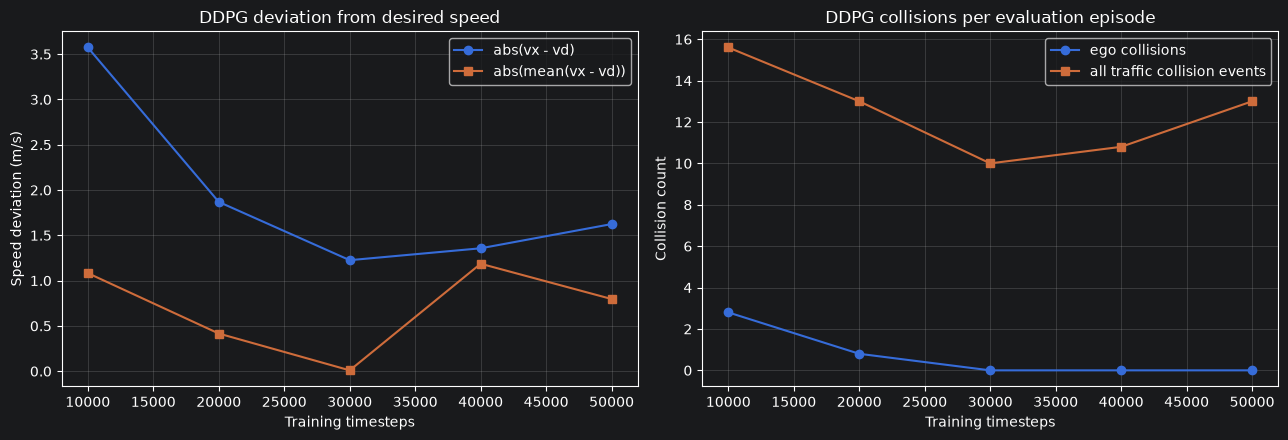

Saved DDPG plot to C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou\ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_metrics.png


In [46]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

if "ARTIFACT_DIR" not in globals():
    _cwd = Path.cwd().resolve()
    for _candidate in [_cwd, *_cwd.parents]:
        _artifact = _candidate / "artifacts" / "lanelessKaralakou"
        _nested_artifact = _candidate / "highway-rl-decision-making" / "artifacts" / "lanelessKaralakou"
        if _artifact.exists():
            ARTIFACT_DIR = _artifact
            break
        if _nested_artifact.exists():
            ARTIFACT_DIR = _nested_artifact
            break
    else:
        ARTIFACT_DIR = _cwd / "artifacts" / "lanelessKaralakou"
DDPG_HISTORY_PATH = globals().get("DDPG_HISTORY_PATH", ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_eval_history.csv")
DDPG_PLOT_PATH = globals().get("DDPG_PLOT_PATH", ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_metrics.png")

if "ddpg_eval_history" not in globals() or ddpg_eval_history.empty:
    ddpg_eval_history = pd.read_csv(DDPG_HISTORY_PATH)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(ddpg_eval_history["timesteps"], ddpg_eval_history["mean_abs_speed_deviation"], marker="o", label="abs(vx - vd)")
axes[0].plot(ddpg_eval_history["timesteps"], ddpg_eval_history["mean_signed_speed_deviation"].abs(), marker="s", label="abs(mean(vx - vd))")
axes[0].set_title("DDPG deviation from desired speed")
axes[0].set_xlabel("Training timesteps")
axes[0].set_ylabel("Speed deviation (m/s)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(ddpg_eval_history["timesteps"], ddpg_eval_history["ego_collisions"], marker="o", label="ego collisions")
axes[1].plot(ddpg_eval_history["timesteps"], ddpg_eval_history["total_collision_events"], marker="s", label="all traffic collision events")
axes[1].set_title("DDPG collisions per evaluation episode")
axes[1].set_xlabel("Training timesteps")
axes[1].set_ylabel("Collision count")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig.savefig(DDPG_PLOT_PATH, dpi=160)
plt.show()
print("Saved DDPG plot to", DDPG_PLOT_PATH)

### C.4 DDPG Without CBF Final Evaluation

In [48]:
import subprocess

DDPG_FINAL_METRICS_PATH = ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_final_metrics.csv"
ddpg_eval_command = [
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "evaluate_laneless_karalakou.py"),
    "--variant",
    "ddpg",
    "--episodes",
    str(FINAL_EVAL_EPISODES),
    "--seed",
    str(SEED + 60_000),
    "--output",
    str(DDPG_FINAL_METRICS_PATH),
    "--device",
    DEVICE,
    "--project-root",
    str(PROJECT_ROOT),
    "--use-latest-training",
]
ddpg_eval_result = subprocess.run(
    ddpg_eval_command,
    cwd=str(PROJECT_ROOT),
    text=True,
)
if ddpg_eval_result.returncode != 0:
    raise RuntimeError(f"DDPG final evaluation subprocess failed with exit code {ddpg_eval_result.returncode}")
ddpg_final_metrics = pd.read_csv(DDPG_FINAL_METRICS_PATH)
display(ddpg_final_metrics)
display(ddpg_final_metrics.drop(columns=["episode"]).mean().to_frame("mean"))

RuntimeError: DDPG final evaluation subprocess failed with exit code 1

### C.5 Render the Trained DDPG Without CBF Policy

Set `RUN_DDPG_RENDER = True` when you want a live highway-env render window.

In [ ]:
RUN_DDPG_RENDER = bool(globals().get("RUN_DDPG_RENDER", False))
DDPG_RENDER_STEPS = int(globals().get("DDPG_RENDER_STEPS", 1_000))

if RUN_DDPG_RENDER:
    import subprocess

    ddpg_render_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "render_laneless_karalakou.py"),
        "--variant",
        "ddpg",
        "--steps",
        str(DDPG_RENDER_STEPS),
        "--seed",
        str(SEED + 109_000),
        "--device",
        DEVICE,
        "--project-root",
        str(PROJECT_ROOT),
    ]
    ddpg_render_result = subprocess.run(ddpg_render_command, cwd=str(PROJECT_ROOT), text=True)
    if ddpg_render_result.returncode != 0:
        raise RuntimeError(f"DDPG render subprocess failed with exit code {ddpg_render_result.returncode}")
else:
    print("Skipped DDPG render. Set RUN_DDPG_RENDER = True to open the render in a separate process.")


### C.6 Shared CBF Shield and Legacy DDPG Shielding Runs

These cells contain the established CBF implementation and older DDPG shielding experiments. The canonical PPO runner reuses the same simulator-side CBF constraint builder, but uses one common physical action interface for every PPO variant.

#### C.6.1 QP Solver Dependencies

In [61]:
try:
    from qpsolvers import solve_qp
    from scipy import sparse
except Exception as exc:
    # The tuned active-set filter can run without these optional packages.
    solve_qp = None
    sparse = None
    CBF_QP_IMPORT_ERROR = repr(exc)
else:
    CBF_QP_IMPORT_ERROR = ""
CBF_QP_AVAILABLE = bool(callable(solve_qp) and sparse is not None)

#### C.6.2 Barrier Geometry and Hyperparameters

In [62]:
CBF_AX_BOUNDS = (-3.0, 3.0)
CBF_AY_BOUNDS = (-3.0, 3.0)
CBF_TARGET_PAIR_DY = 3.0
CBF_REFERENCE_EGO_WIDTH = float(ENV_CONFIG["ego_dimensions"][1])
CBF_REFERENCE_SOCIAL_WIDTH = float(ENV_CONFIG["vehicle_dimensions"][0][1])
CBF_EPS_SIDE = 0.10
CBF_K0 = 5.29
CBF_K1 = 3.68
CBF_NEIGHBOR_RANGE = float(ENV_CONFIG["sensing_range"])
CBF_FILTER_REWARD_LAMBDA = 0.05
CBF_QP_FEASIBILITY_TOL = 1e-3


def inflated_ellipse_axes(length: float, width: float, eps_side: float = CBF_EPS_SIDE) -> tuple[float, float]:
    """Inflated ellipse semi-axes that cover a rectangular vehicle footprint."""
    a = float(length) / np.sqrt(2.0) + 2.0 * float(eps_side)
    b = float(width) / np.sqrt(2.0) + 2.0 * float(eps_side)
    return max(float(a), 1e-6), max(float(b), 1e-6)


def _wrap_angle(angle: float) -> float:
    return float((float(angle) + np.pi) % (2.0 * np.pi) - np.pi)


def ellipse_radius_along_line(a: float, b: float, delta: float) -> float:
    """Radius from ellipse center to boundary along a ray at angle delta from major axis."""
    cos_delta = np.cos(float(delta))
    sin_delta = np.sin(float(delta))
    denom = np.sqrt((float(b) * cos_delta) ** 2 + (float(a) * sin_delta) ** 2)
    return float(float(a) * float(b) / max(float(denom), 1e-9))


def pairwise_centerline_clearance(
    p: np.ndarray,
    ego: dict[str, float],
    other: dict[str, float],
    eps_side: Optional[float] = None,
) -> tuple[float, float, float, float]:
    r = float(np.linalg.norm(p))
    if r < 1e-9:
        phi = 0.0
    else:
        phi = float(np.arctan2(float(p[1]), float(p[0])))

    a_ego, b_ego = inflated_ellipse_axes(ego["length"], ego["width"], eps_side)
    a_other, b_other = inflated_ellipse_axes(other["length"], other["width"], eps_side)
    l_ego = ellipse_radius_along_line(a_ego, b_ego, _wrap_angle(phi - float(ego.get("heading", 0.0))))
    l_other = ellipse_radius_along_line(a_other, b_other, _wrap_angle(phi - float(other.get("heading", 0.0))))
    required_distance = l_ego + l_other
    h = r - required_distance
    return float(h), float(r), float(l_ego), float(l_other)




def _wrapped_signed_dx(raw_dx: float, road_length: Optional[float] = None) -> float:
    """Shortest signed longitudinal distance on the ring road, in meters."""
    dx = float(raw_dx)
    if road_length is None:
        return dx
    length = float(road_length)
    if not np.isfinite(length) or length <= 0.0:
        return dx
    return float(((dx + 0.5 * length) % length) - 0.5 * length)


def pairwise_relative_state(ego: dict[str, float], other: dict[str, float]) -> tuple[float, float, float, float]:
    """Relative physical state: neighbor relative to ego, with wrapped ring-road dx."""
    if "signed_dx" in other:
        dx = float(other["signed_dx"])
    else:
        road_length = other.get("road_length", ego.get("road_length"))
        dx = _wrapped_signed_dx(float(other["x"]) - float(ego["x"]), road_length)
    dy = float(other["y"]) - float(ego["y"])
    dvx = float(other["vx"]) - float(ego["vx"])
    dvy = float(other["vy"]) - float(ego["vy"])
    return float(dx), float(dy), float(dvx), float(dvy)


def pairwise_cbf_geometry(
    ego: dict[str, float],
    other: dict[str, float],
    eps_side: float = CBF_EPS_SIDE,
) -> tuple[float, float, float, float, float, float, float]:
    dx, dy, dvx, dvy = pairwise_relative_state(ego, other)
    h, center_distance, l_ego, l_other = pairwise_centerline_clearance(
        np.asarray([dx, dy], dtype=float),
        ego,
        other,
        eps_side,
    )
    required_distance = l_ego + l_other
    return float(h), dx, dy, dvx, dvy, float(center_distance), float(required_distance)


def centerline_barrier_derivatives(
    p: np.ndarray,
    ego: dict[str, float],
    other: dict[str, float],
    eps_side: float = CBF_EPS_SIDE,
    fd_step: float = 1e-3,
) -> tuple[float, np.ndarray, np.ndarray, float, float, float]:
    p = np.asarray(p, dtype=float).reshape(2)

    def f(point: np.ndarray) -> tuple[float, float, float, float]:
        return pairwise_centerline_clearance(point, ego, other, eps_side)

    h0, center_distance, l_ego, l_other = f(p)
    e_x = np.asarray([fd_step, 0.0], dtype=float)
    e_y = np.asarray([0.0, fd_step], dtype=float)
    h_px = f(p + e_x)[0]
    h_mx = f(p - e_x)[0]
    h_py = f(p + e_y)[0]
    h_my = f(p - e_y)[0]
    grad = np.asarray([(h_px - h_mx) / (2.0 * fd_step), (h_py - h_my) / (2.0 * fd_step)], dtype=float)
    h_pp = f(p + e_x + e_y)[0]
    h_pm = f(p + e_x - e_y)[0]
    h_mp = f(p - e_x + e_y)[0]
    h_mm = f(p - e_x - e_y)[0]
    hessian = np.asarray(
        [
            [(h_px - 2.0 * h0 + h_mx) / (fd_step**2), (h_pp - h_pm - h_mp + h_mm) / (4.0 * fd_step**2)],
            [(h_pp - h_pm - h_mp + h_mm) / (4.0 * fd_step**2), (h_py - 2.0 * h0 + h_my) / (fd_step**2)],
        ],
        dtype=float,
    )
    return float(h0), grad, hessian, float(center_distance), float(l_ego), float(l_other)


def pairwise_hocbf_constraint(
    ego: dict[str, float],
    other: dict[str, float],
    eps_side: float = CBF_EPS_SIDE,
    k0: float = CBF_K0,
    k1: float = CBF_K1,
    other_acc: Optional[np.ndarray] = None,
) -> tuple[np.ndarray, float, float, float, float]:
    dx, dy, dvx, dvy = pairwise_relative_state(ego, other)
    p = np.asarray([dx, dy], dtype=float)
    v = np.asarray([dvx, dvy], dtype=float)
    a_j = np.zeros(2, dtype=float) if other_acc is None else np.asarray(other_acc, dtype=float).reshape(-1)[:2]
    h, grad, hessian, center_distance, l_ego, l_other = centerline_barrier_derivatives(p, ego, other, eps_side)
    h_dot = float(grad @ v)
    A = np.asarray(grad, dtype=float)
    b = float(v.T @ hessian @ v + grad @ a_j + float(k1) * h_dot + float(k0) * h)
    return A, b, float(h), float(center_distance), float(l_ego + l_other)


def cbf_filter_2d(
    a_rl,
    ego: dict[str, float],
    neighbors: list[dict[str, float]],
    road_width: float,
    ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
    ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
    eps_side: float = CBF_EPS_SIDE,
    k0: float = CBF_K0,
    k1: float = CBF_K1,
) -> tuple[np.ndarray, dict[str, Any]]:
    a_rl = np.asarray(a_rl, dtype=float).reshape(-1)
    if a_rl.size < 2:
        raise ValueError("a_rl must contain [ax, ay].")
    a_rl = a_rl[:2]

    P = sparse.csc_matrix(2.0 * np.eye(2, dtype=float))
    q = -2.0 * a_rl
    G_rows: list[np.ndarray] = []
    h_rows: list[float] = []
    min_h = np.inf
    min_center_distance = np.inf
    min_required_distance = np.inf
    neighbor_constraints = 0

    for neighbor in neighbors:
        other_acc = np.asarray([float(neighbor.get("ax", 0.0)), float(neighbor.get("ay", 0.0))], dtype=float)
        A, b, h_ij, center_distance, required_distance = pairwise_hocbf_constraint(
            ego,
            neighbor,
            eps_side=eps_side,
            k0=k0,
            k1=k1,
            other_acc=other_acc,
        )
        min_h = min(min_h, h_ij)
        min_center_distance = min(min_center_distance, center_distance)
        min_required_distance = min(min_required_distance, required_distance)
        G_rows.append(A)
        h_rows.append(b)
        neighbor_constraints += 1

    ego_y = float(ego["y"])
    ego_vy = float(ego["vy"])
    ego_half_width = 0.5 * float(ego["width"])
    h_left = ego_y - ego_half_width
    h_right = float(road_width) - ego_half_width - ego_y

    G_rows.append(np.asarray([0.0, -1.0], dtype=float))
    h_rows.append(float(k1 * ego_vy + k0 * h_left))
    G_rows.append(np.asarray([0.0, 1.0], dtype=float))
    h_rows.append(float(-k1 * ego_vy + k0 * h_right))

    G = sparse.csc_matrix(np.asarray(G_rows, dtype=float))
    h_vec = np.asarray(h_rows, dtype=float)
    lb = np.asarray([float(ax_bounds[0]), float(ay_bounds[0])], dtype=float)
    ub = np.asarray([float(ax_bounds[1]), float(ay_bounds[1])], dtype=float)

    rl_constraint_values = np.asarray(G @ a_rl - h_vec, dtype=float).reshape(-1)
    raw_is_feasible = (
        bool(np.all(rl_constraint_values <= CBF_QP_FEASIBILITY_TOL))
        and bool(np.all(a_rl >= lb - CBF_QP_FEASIBILITY_TOL))
        and bool(np.all(a_rl <= ub + CBF_QP_FEASIBILITY_TOL))
    )
    qp_error = ""
    if raw_is_feasible:
        qp_success = True
        a_safe = a_rl.copy()
    else:
        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message=r"OSQP exited.*")
                solution = solve_qp(P, q, G=G, h=h_vec, lb=lb, ub=ub, solver="osqp", verbose=False)
        except Exception as exc:
            solution = None
            qp_error = repr(exc)

        qp_success = solution is not None and bool(np.all(np.isfinite(solution)))
        if qp_success:
            a_safe = np.clip(np.asarray(solution, dtype=float), lb, ub)
        else:
            a_safe = np.asarray([float(ax_bounds[0]), 0.0], dtype=float)

    safe_constraint_values = np.asarray(G @ a_safe - h_vec, dtype=float).reshape(-1)

    correction_norm = float(np.linalg.norm(a_safe - a_rl))
    if not np.isfinite(min_h):
        min_h = np.nan
    if not np.isfinite(min_center_distance):
        min_center_distance = np.nan
    if not np.isfinite(min_required_distance):
        min_required_distance = np.nan

    info = {
        "a_safe": a_safe.astype(np.float32),
        "correction_norm": correction_norm,
        "raw_feasible": bool(raw_is_feasible),
        "max_constraint_violation_rl": float(np.max(rl_constraint_values)) if len(rl_constraint_values) else 0.0,
        "max_constraint_violation_safe": float(np.max(safe_constraint_values)) if len(safe_constraint_values) else 0.0,
        "min_h": float(min_h),
        "min_center_distance": float(min_center_distance),
        "min_required_distance": float(min_required_distance),
        "eps_side": float(eps_side),
        "qp_success": bool(qp_success),
        "fallback_used": bool(not qp_success),
        "qp_error": qp_error,
        "num_neighbor_constraints": int(neighbor_constraints),
        "left_boundary_h": float(h_left),
        "right_boundary_h": float(h_right),
        "min_boundary_h": float(min(h_left, h_right)),
    }
    return a_safe.astype(np.float32), info

#### C.6.3 Action Conversion and Vehicle-State Helpers

In [63]:
def _lane_free_base(env: gym.Env):
    return env.unwrapped


def _physical_to_normalized_action(env: gym.Env, a_physical: np.ndarray) -> np.ndarray:
    base = _lane_free_base(env)
    bounds = base.config["bounds"]
    physical_bounds = [
        (float(bounds["ax_min"]), float(bounds["ax_max"])),
        (float(bounds["ay_min"]), float(bounds["ay_max"])),
    ]
    normalized = np.zeros(2, dtype=np.float32)
    for index, (value, (low, high)) in enumerate(zip(np.asarray(a_physical, dtype=float), physical_bounds)):
        value = float(np.clip(value, low, high))
        if low < 0.0 < high:
            scale = high if value >= 0.0 else abs(low)
            normalized[index] = value / max(scale, 1e-6)
        else:
            normalized[index] = float(2.0 * (value - low) / max(high - low, 1e-6) - 1.0)
    return np.clip(normalized, -1.0, 1.0)


def get_ego_state(env: gym.Env) -> dict[str, float]:
    base = _lane_free_base(env)
    ego = base.vehicle
    return {
        "x": float(ego.position[0]),
        "y": float(ego.position[1]),
        "vx": float(ego.vx),
        "vy": float(ego.vy),
        "heading": float(ego.heading),
        "length": float(ego.length),
        "width": float(ego.width),
        "road_length": float(base.config["road_length"]),
    }


def get_neighbor_states(env: gym.Env, neighbor_range: Optional[float] = None) -> list[dict[str, float]]:
    base = _lane_free_base(env)
    ego = base.vehicle
    max_range = float(base.config["sensing_range"] if neighbor_range is None else neighbor_range)
    neighbors: list[dict[str, float]] = []

    for index, vehicle in enumerate(base.road.vehicles):
        if vehicle is ego:
            continue
        dx = float(base._signed_distance(ego.position[0], vehicle.position[0]))
        dy = float(vehicle.position[1] - ego.position[1])
        distance = float(np.sqrt(dx * dx + dy * dy))
        if distance > max_range:
            continue

        ax = ay = 0.0
        if len(base._last_accelerations) > index:
            ax = float(base._last_accelerations[index, 0])
            ay = float(base._last_accelerations[index, 1])

        neighbors.append(
            {
                "x": float(ego.position[0] + dx),
                "y": float(vehicle.position[1]),
                "vx": float(vehicle.vx),
                "vy": float(vehicle.vy),
                "heading": float(vehicle.heading),
                "ax": ax,
                "ay": ay,
                "length": float(vehicle.length),
                "width": float(vehicle.width),
                "distance": distance,
                "signed_dx": dx,
            }
        )

    return sorted(neighbors, key=lambda item: item["distance"])

#### C.6.4 Safety-Filter Environment Wrapper

In [64]:
class SafetyFilteredAccelerationWrapper(gym.Wrapper):
    """Non-differentiable CBF-QP action shield over physical acceleration actions."""

    def __init__(
        self,
        env: gym.Env,
        lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
        neighbor_range: float = CBF_NEIGHBOR_RANGE,
        ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
        ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
        eps_side: float = CBF_EPS_SIDE,
        k0: float = CBF_K0,
        k1: float = CBF_K1,
    ) -> None:
        super().__init__(env)
        self.lambda_filter = float(lambda_filter)
        self.neighbor_range = float(neighbor_range)
        self.ax_bounds = ax_bounds
        self.ay_bounds = ay_bounds
        self.eps_side = float(eps_side)
        self.k0 = float(k0)
        self.k1 = float(k1)
        self.action_space = gym.spaces.Box(
            low=np.asarray([ax_bounds[0], ay_bounds[0]], dtype=np.float32),
            high=np.asarray([ax_bounds[1], ay_bounds[1]], dtype=np.float32),
            dtype=np.float32,
        )

    def get_ego_state(self) -> dict[str, float]:
        return get_ego_state(self)

    def get_neighbor_states(self) -> list[dict[str, float]]:
        return get_neighbor_states(self, neighbor_range=self.neighbor_range)

    def step(self, action):
        a_rl = np.asarray(action, dtype=np.float32).reshape(-1)[:2]
        ego = get_ego_state(self)
        neighbors = get_neighbor_states(self, neighbor_range=self.neighbor_range)
        road_width = float(_lane_free_base(self).config["road_width"])
        a_safe, filter_info = cbf_filter_2d(
            a_rl,
            ego,
            neighbors,
            road_width,
            ax_bounds=self.ax_bounds,
            ay_bounds=self.ay_bounds,
            eps_side=self.eps_side,
            k0=self.k0,
            k1=self.k1,
        )
        normalized_action = _physical_to_normalized_action(self, a_safe)
        obs, reward, terminated, truncated, info = self.env.step(normalized_action)
        correction_norm = float(filter_info["correction_norm"])
        reward = float(reward) - self.lambda_filter * correction_norm**2

        info = dict(info)
        info.update(
            {
                "cbf_a_rl_x": float(a_rl[0]),
                "cbf_a_rl_y": float(a_rl[1]),
                "cbf_a_safe_x": float(a_safe[0]),
                "cbf_a_safe_y": float(a_safe[1]),
                "cbf_correction_norm": correction_norm,
                "cbf_intervened": bool(correction_norm > 1e-6),
                "cbf_raw_feasible": bool(filter_info.get("raw_feasible", False)),
                "cbf_min_h": float(filter_info["min_h"]),
                "cbf_min_center_distance": float(filter_info["min_center_distance"]),
                "cbf_min_required_distance": float(filter_info["min_required_distance"]),
                "cbf_eps_side": float(filter_info["eps_side"]),
                "cbf_qp_success": bool(filter_info["qp_success"]),
                "cbf_fallback_used": bool(filter_info.get("fallback_used", not filter_info["qp_success"])),
                "cbf_qp_error": str(filter_info["qp_error"]),
                "cbf_num_neighbor_constraints": int(filter_info["num_neighbor_constraints"]),
                "cbf_min_boundary_h": float(filter_info["min_boundary_h"]),
                "cbf_left_boundary_h": float(filter_info["left_boundary_h"]),
                "cbf_right_boundary_h": float(filter_info["right_boundary_h"]),
                "cbf_filter_reward_penalty": float(self.lambda_filter * correction_norm**2),
            }
        )
        return obs, reward, terminated, truncated, info


def make_cbf_single_env(
    seed: int = SEED,
    render_mode: Optional[str] = None,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: float = CBF_EPS_SIDE,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
) -> gym.Env:
    active_eps_side = CBF_EPS_SIDE if eps_side is None else float(eps_side)
    env = gym.make("lane-free-v0", render_mode=render_mode, config=env_config or ENV_CONFIG)
    env = KaralakouRewardWrapper(env, reward_config=reward_config or REWARD_CONFIG)
    env = SafetyFilteredAccelerationWrapper(env, lambda_filter=lambda_filter, eps_side=active_eps_side)
    if normalize_observation:
        env = LaneFreeObservationNormalizationWrapper(env, clip=OBSERVATION_CLIP)
    env = KPIInfoWrapper(env)
    env = Monitor(env)
    env.reset(seed=seed)
    return env


def make_cbf_training_env(
    seed: int = SEED,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: Optional[float] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
    n_envs: int = 1,
    use_subproc: bool = DDPG_USE_SUBPROC_VEC_ENV,
):
    active_eps_side = CBF_EPS_SIDE if eps_side is None else float(eps_side)

    def _single_env(env_seed: int) -> gym.Env:
        return make_cbf_single_env(
            seed=env_seed,
            render_mode=None,
            lambda_filter=lambda_filter,
            eps_side=active_eps_side,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
        )

    return _make_vectorized_env(
        _single_env,
        seed=seed,
        n_envs=n_envs,
        use_subproc=use_subproc,
        start_method=DDPG_SUBPROC_START_METHOD,
    )


#### C.6.5 Tuned No-Slack Shield Override

In [65]:
# Tuned DDPG-CBF shield overrides, no slack
# Run this cell after the base CBF definitions and before DDPG-CBF training/evaluation.
# It intentionally overrides cbf_filter_2d, SafetyFilteredAccelerationWrapper, and make_cbf_*_env.
# The CBF gains come from the shared hyperparameter cell above.

# Keep OSQP as an optional fallback; the active-set shield itself has no QP dependency.
try:
    from qpsolvers import solve_qp
    from scipy import sparse
except Exception as exc:
    solve_qp = None
    sparse = None
    CBF_QP_IMPORT_ERROR = repr(exc)
else:
    CBF_QP_IMPORT_ERROR = ""
CBF_QP_AVAILABLE = bool(callable(solve_qp) and sparse is not None)

CBF_AX_BOUNDS = (-3.0, 3.0)
CBF_AY_BOUNDS = (-3.0, 3.0)
CBF_MAX_NEIGHBOR_CONSTRAINTS = 12
CBF_QP_SOLVER = "osqp"
CBF_QP_FEASIBILITY_TOL = 1e-3
CBF_PROJECTION_SOLVER = "active_set_2d"


def _cbf_emergency_fallback_action(
    a_rl: np.ndarray,
    ego: dict[str, float],
    neighbors: list[dict[str, float]],
    road_width: float,
    ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
    ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
    eps_side: float = CBF_EPS_SIDE,
) -> np.ndarray:
    """Rare solver-failure fallback. Prefer evasive direction over blind straight braking."""
    lb = np.asarray([float(ax_bounds[0]), float(ay_bounds[0])], dtype=float)
    ub = np.asarray([float(ax_bounds[1]), float(ay_bounds[1])], dtype=float)
    action = np.clip(np.asarray(a_rl, dtype=float).reshape(-1)[:2], lb, ub)

    scored_neighbors: list[tuple[float, dict[str, float], float, float, float, float]] = []
    for neighbor in neighbors:
        h, dx, dy, dvx, dvy, _, _ = pairwise_cbf_geometry(ego, neighbor, eps_side=eps_side)
        scored_neighbors.append((float(h), neighbor, float(dx), float(dy), float(dvx), float(dvy)))

    if scored_neighbors:
        h, _, dx, dy, dvx, dvy = min(scored_neighbors, key=lambda item: item[0])
        p = np.asarray([dx, dy], dtype=float)
        v = np.asarray([dvx, dvy], dtype=float)
        closing_speed = float(-(p @ v) / max(float(np.linalg.norm(p)), 1e-6))

        if h < 2.0 and dx > 0.0 and closing_speed > 0.0:
            action[0] = min(action[0], float(ax_bounds[0]))
        if h < 1.0 and abs(dy) > 1e-6:
            action[1] = float(ay_bounds[0] if dy > 0.0 else ay_bounds[1])

    ego_y = float(ego["y"])
    ego_half_width = 0.5 * float(ego["width"])
    if ego_y - ego_half_width < 0.5:
        action[1] = max(action[1], 0.0)
    if float(road_width) - ego_half_width - ego_y < 0.5:
        action[1] = min(action[1], 0.0)

    return np.clip(action, lb, ub).astype(np.float32)


def _least_violating_bounded_action(
    a_rl: np.ndarray,
    constraint_rows: list[np.ndarray],
    constraint_bounds: list[float],
    ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
    ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
) -> np.ndarray:
    """Fallback for infeasible hard-QP states: choose the bounded action with smallest violation."""
    lb = np.asarray([float(ax_bounds[0]), float(ay_bounds[0])], dtype=float)
    ub = np.asarray([float(ax_bounds[1]), float(ay_bounds[1])], dtype=float)
    target = np.clip(np.asarray(a_rl, dtype=float).reshape(-1)[:2], lb, ub)
    rows = np.asarray(constraint_rows, dtype=float).reshape((-1, 2))
    bounds = np.asarray(constraint_bounds, dtype=float).reshape(-1)

    ax_grid = np.unique(np.r_[np.linspace(lb[0], ub[0], 25), target[0], lb[0], ub[0]])
    ay_grid = np.unique(np.r_[np.linspace(lb[1], ub[1], 25), target[1], lb[1], ub[1]])

    grid_x, grid_y = np.meshgrid(ax_grid, ay_grid, indexing="ij")
    candidates = np.column_stack([grid_x.reshape(-1), grid_y.reshape(-1)])
    violations = candidates @ rows.T - bounds.reshape(1, -1)
    positive = np.maximum(violations, 0.0)
    max_violation = np.max(positive, axis=1) if positive.shape[1] else np.zeros(len(candidates), dtype=float)
    total_violation = np.sum(positive**2, axis=1)
    correction = np.sum((candidates - target.reshape(1, 2)) ** 2, axis=1)
    # np.lexsort uses the final key as the primary one: preserve the
    # original (max violation, total violation, correction) ordering.
    best_index = int(np.lexsort((correction, total_violation, max_violation))[0])
    return np.clip(candidates[best_index], lb, ub).astype(np.float32)


def project_action_to_linear_constraints_2d(
    a_rl: np.ndarray,
    constraint_rows: list[np.ndarray],
    constraint_bounds: list[float],
    ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
    ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
    feasibility_tol: float = CBF_QP_FEASIBILITY_TOL,
) -> Optional[np.ndarray]:
    """Exactly project an action onto bounded linear constraints in 2D.

    The closest point of a nonempty 2D polytope is the raw action, a
    one-boundary projection, or an intersection of two boundaries.
    Enumerating those candidates avoids a generic QP solve on every CBF
    intervention while preserving the same hard constraints and box bounds.
    """
    target = np.asarray(a_rl, dtype=float).reshape(-1)
    if target.size < 2 or not np.all(np.isfinite(target[:2])):
        return None
    target = target[:2]
    lb = np.asarray([float(ax_bounds[0]), float(ay_bounds[0])], dtype=float)
    ub = np.asarray([float(ax_bounds[1]), float(ay_bounds[1])], dtype=float)
    tol = float(feasibility_tol)
    if not (np.all(np.isfinite(lb)) and np.all(np.isfinite(ub)) and np.all(lb <= ub) and np.isfinite(tol) and tol >= 0.0):
        return None

    try:
        rows = np.asarray(constraint_rows, dtype=float).reshape((-1, 2))
        bounds = np.asarray(constraint_bounds, dtype=float).reshape(-1)
    except (TypeError, ValueError):
        return None
    if rows.shape[0] != bounds.size or not (np.all(np.isfinite(rows)) and np.all(np.isfinite(bounds))):
        return None

    row_norm_sq = np.sum(rows * rows, axis=1)
    zero_rows = row_norm_sq <= 1e-20
    if np.any(zero_rows & (bounds < -tol)):
        return None
    rows = rows[~zero_rows]
    bounds = bounds[~zero_rows]

    box_rows = np.asarray([[-1.0, 0.0], [1.0, 0.0], [0.0, -1.0], [0.0, 1.0]], dtype=float)
    box_bounds = np.asarray([-lb[0], ub[0], -lb[1], ub[1]], dtype=float)
    rows = np.vstack([rows, box_rows])
    bounds = np.concatenate([bounds, box_bounds])

    # Vectorize all single-boundary and two-boundary candidates. With at
    # most 18 rows here (12 neighbors, two road boundaries, four box
    # bounds), this replaces Python/solver overhead with small dense arrays.
    row_norm_sq = np.sum(rows * rows, axis=1)
    residual = rows @ target - bounds
    single_boundary = target.reshape(1, 2) - (residual / row_norm_sq).reshape(-1, 1) * rows

    first, second = np.triu_indices(rows.shape[0], k=1)
    first_rows = rows[first]
    second_rows = rows[second]
    determinant = first_rows[:, 0] * second_rows[:, 1] - first_rows[:, 1] * second_rows[:, 0]
    scale = np.maximum(np.linalg.norm(first_rows, axis=1) * np.linalg.norm(second_rows, axis=1), 1.0)
    nonparallel = np.abs(determinant) > 1e-10 * scale
    first = first[nonparallel]
    second = second[nonparallel]
    determinant = determinant[nonparallel]
    first_rows = first_rows[nonparallel]
    second_rows = second_rows[nonparallel]
    pair_boundary = np.column_stack(
        [
            (bounds[first] * second_rows[:, 1] - first_rows[:, 1] * bounds[second]) / determinant,
            (first_rows[:, 0] * bounds[second] - bounds[first] * second_rows[:, 0]) / determinant,
        ]
    )

    candidates = np.vstack([target.reshape(1, 2), single_boundary, pair_boundary])
    finite = np.all(np.isfinite(candidates), axis=1)
    feasible = finite & np.all(candidates @ rows.T <= bounds.reshape(1, -1) + tol, axis=1)
    if not np.any(feasible):
        return None
    candidates = candidates[feasible]
    squared_distances = np.sum((candidates - target.reshape(1, 2)) ** 2, axis=1)
    return candidates[int(np.argmin(squared_distances))].astype(float)


def cbf_filter_2d(
    a_rl,
    ego: dict[str, float],
    neighbors: list[dict[str, float]],
    road_width: float,
    ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
    ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
    eps_side: float = CBF_EPS_SIDE,
    k0: float = CBF_K0,
    k1: float = CBF_K1,
    max_neighbor_constraints: Optional[int] = CBF_MAX_NEIGHBOR_CONSTRAINTS,
) -> tuple[np.ndarray, dict[str, Any]]:
    """Hard HOCBF-QP filter over physical acceleration actions using tuned gains."""
    a_rl = np.asarray(a_rl, dtype=float).reshape(-1)
    if a_rl.size < 2:
        raise ValueError("a_rl must contain [ax, ay].")
    a_rl = a_rl[:2]

    if max_neighbor_constraints is not None:
        neighbors = list(neighbors)[: int(max_neighbor_constraints)]

    constraint_rows: list[np.ndarray] = []
    constraint_bounds: list[float] = []
    min_h = np.inf
    min_center_distance = np.inf
    min_required_distance = np.inf
    neighbor_constraints = 0

    for neighbor in neighbors:
        other_acc = np.asarray([float(neighbor.get("ax", 0.0)), float(neighbor.get("ay", 0.0))], dtype=float)
        A, b, h_ij, center_distance, required_distance = pairwise_hocbf_constraint(
            ego,
            neighbor,
            eps_side=eps_side,
            k0=k0,
            k1=k1,
            other_acc=other_acc,
        )
        constraint_rows.append(np.asarray(A, dtype=float))
        constraint_bounds.append(float(b))
        min_h = min(min_h, float(h_ij))
        min_center_distance = min(min_center_distance, float(center_distance))
        min_required_distance = min(min_required_distance, float(required_distance))
        neighbor_constraints += 1

    ego_y = float(ego["y"])
    ego_vy = float(ego["vy"])
    ego_half_width = 0.5 * float(ego["width"])
    h_left = ego_y - ego_half_width
    h_right = float(road_width) - ego_half_width - ego_y

    # h_left = y - b:    ay + k1*vy + k0*h_left >= 0 -> -ay <= k1*vy + k0*h_left
    # h_right = W-b-y: -ay - k1*vy + k0*h_right >= 0 ->  ay <= -k1*vy + k0*h_right
    constraint_rows.append(np.asarray([0.0, -1.0], dtype=float))
    constraint_bounds.append(float(k1 * ego_vy + k0 * h_left))
    constraint_rows.append(np.asarray([0.0, 1.0], dtype=float))
    constraint_bounds.append(float(-k1 * ego_vy + k0 * h_right))

    constraint_array = np.asarray(constraint_rows, dtype=float)
    h_vec = np.asarray(constraint_bounds, dtype=float)
    lb = np.asarray([float(ax_bounds[0]), float(ay_bounds[0])], dtype=float)
    ub = np.asarray([float(ax_bounds[1]), float(ay_bounds[1])], dtype=float)

    rl_constraint_values = np.asarray(constraint_array @ a_rl - h_vec, dtype=float).reshape(-1)
    raw_is_feasible = (
        bool(np.all(rl_constraint_values <= CBF_QP_FEASIBILITY_TOL))
        and bool(np.all(a_rl >= lb - CBF_QP_FEASIBILITY_TOL))
        and bool(np.all(a_rl <= ub + CBF_QP_FEASIBILITY_TOL))
    )
    qp_error = ""
    projection_solver = "raw"
    if raw_is_feasible:
        qp_success = True
        a_safe = a_rl.copy()
    else:
        direct_solution = project_action_to_linear_constraints_2d(
            a_rl,
            constraint_rows,
            constraint_bounds,
            ax_bounds=ax_bounds,
            ay_bounds=ay_bounds,
            feasibility_tol=CBF_QP_FEASIBILITY_TOL,
        )
        qp_success = direct_solution is not None
        if qp_success:
            a_safe = np.asarray(direct_solution, dtype=float).reshape(-1)[:2]
            projection_solver = CBF_PROJECTION_SOLVER
        else:
            # Keep OSQP as a numerical fallback for a degenerate active set.
            try:
                P = sparse.csc_matrix(2.0 * np.eye(2, dtype=float))
                q = -2.0 * a_rl
                G = sparse.csc_matrix(constraint_array)
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", message=r"OSQP exited.*")
                    solution = solve_qp(P, q, G=G, h=h_vec, lb=lb, ub=ub, solver=CBF_QP_SOLVER, verbose=False)
            except Exception as exc:
                solution = None
                qp_error = repr(exc)

            qp_success = solution is not None and bool(np.all(np.isfinite(solution)))
            if qp_success:
                a_safe = np.clip(np.asarray(solution, dtype=float).reshape(-1)[:2], lb, ub)
                projection_solver = CBF_QP_SOLVER
            else:
                projection_solver = "fallback"
                a_safe = _least_violating_bounded_action(a_rl, constraint_rows, constraint_bounds, ax_bounds, ay_bounds)
                emergency_action = _cbf_emergency_fallback_action(a_rl, ego, neighbors, road_width, ax_bounds, ay_bounds, eps_side)
                current_violation = max(
                    float(np.max(np.maximum(np.asarray([row @ a_safe - b for row, b in zip(constraint_rows, constraint_bounds)]), 0.0))),
                    0.0,
                )
                emergency_violation = max(
                    float(np.max(np.maximum(np.asarray([row @ emergency_action - b for row, b in zip(constraint_rows, constraint_bounds)]), 0.0))),
                    0.0,
                )
                if emergency_violation + 1e-9 < current_violation:
                    a_safe = emergency_action

    rl_constraint_values = np.asarray([row @ a_rl - b for row, b in zip(constraint_rows, constraint_bounds)], dtype=float)
    safe_constraint_values = np.asarray([row @ a_safe - b for row, b in zip(constraint_rows, constraint_bounds)], dtype=float)

    correction_norm = float(np.linalg.norm(a_safe - a_rl))
    if not np.isfinite(min_h):
        min_h = np.nan
    if not np.isfinite(min_center_distance):
        min_center_distance = np.nan
    if not np.isfinite(min_required_distance):
        min_required_distance = np.nan

    info = {
        "a_safe": a_safe.astype(np.float32),
        "correction_norm": correction_norm,
        "raw_feasible": bool(raw_is_feasible),
        "max_constraint_violation_rl": float(np.max(rl_constraint_values)) if len(rl_constraint_values) else 0.0,
        "max_constraint_violation_safe": float(np.max(safe_constraint_values)) if len(safe_constraint_values) else 0.0,
        "min_h": float(min_h),
        "min_center_distance": float(min_center_distance),
        "min_required_distance": float(min_required_distance),
        "eps_side": float(eps_side),
        "k0": float(k0),
        "k1": float(k1),
        "projection_solver": str(projection_solver),
        "qp_success": bool(qp_success),
        "fallback_used": bool(not qp_success),
        "qp_error": qp_error,
        "num_neighbor_constraints": int(neighbor_constraints),
        "left_boundary_h": float(h_left),
        "right_boundary_h": float(h_right),
        "min_boundary_h": float(min(h_left, h_right)),
    }
    return a_safe.astype(np.float32), info


class SafetyFilteredAccelerationWrapper(gym.Wrapper):
    """Tuned no-slack DDPG-CBF action shield over physical acceleration actions."""

    def __init__(
        self,
        env: gym.Env,
        lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
        neighbor_range: float = CBF_NEIGHBOR_RANGE,
        ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
        ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
        eps_side: float = CBF_EPS_SIDE,
        k0: float = CBF_K0,
        k1: float = CBF_K1,
        max_neighbor_constraints: Optional[int] = CBF_MAX_NEIGHBOR_CONSTRAINTS,
    ) -> None:
        super().__init__(env)
        self.lambda_filter = float(lambda_filter)
        self.neighbor_range = float(neighbor_range)
        self.ax_bounds = ax_bounds
        self.ay_bounds = ay_bounds
        self.eps_side = float(eps_side)
        self.k0 = float(k0)
        self.k1 = float(k1)
        self.max_neighbor_constraints = max_neighbor_constraints
        self.action_space = gym.spaces.Box(
            low=np.asarray([ax_bounds[0], ay_bounds[0]], dtype=np.float32),
            high=np.asarray([ax_bounds[1], ay_bounds[1]], dtype=np.float32),
            dtype=np.float32,
        )

    def get_ego_state(self) -> dict[str, float]:
        return get_ego_state(self)

    def get_neighbor_states(self) -> list[dict[str, float]]:
        return get_neighbor_states(self, neighbor_range=self.neighbor_range)

    def step(self, action):
        a_rl = np.asarray(action, dtype=np.float32).reshape(-1)[:2]
        ego = get_ego_state(self)
        neighbors = get_neighbor_states(self, neighbor_range=self.neighbor_range)
        road_width = float(_lane_free_base(self).config["road_width"])
        a_safe, filter_info = cbf_filter_2d(
            a_rl,
            ego,
            neighbors,
            road_width,
            ax_bounds=self.ax_bounds,
            ay_bounds=self.ay_bounds,
            eps_side=self.eps_side,
            k0=self.k0,
            k1=self.k1,
            max_neighbor_constraints=self.max_neighbor_constraints,
        )
        normalized_action = _physical_to_normalized_action(self, a_safe)
        obs, reward, terminated, truncated, info = self.env.step(normalized_action)
        correction_norm = float(filter_info["correction_norm"])
        correction_penalty = self.lambda_filter * correction_norm**2
        reward = float(reward) - correction_penalty

        info = dict(info)
        info.update(
            {
                "cbf_a_rl_x": float(a_rl[0]),
                "cbf_a_rl_y": float(a_rl[1]),
                "cbf_a_safe_x": float(a_safe[0]),
                "cbf_a_safe_y": float(a_safe[1]),
                "cbf_correction_norm": correction_norm,
                "cbf_intervened": bool(correction_norm > 1e-6),
                "cbf_raw_feasible": bool(filter_info.get("raw_feasible", False)),
                "cbf_max_constraint_violation_rl": float(filter_info["max_constraint_violation_rl"]),
                "cbf_max_constraint_violation_safe": float(filter_info["max_constraint_violation_safe"]),
                "cbf_min_h": float(filter_info["min_h"]),
                "cbf_min_center_distance": float(filter_info["min_center_distance"]),
                "cbf_min_required_distance": float(filter_info["min_required_distance"]),
                "cbf_eps_side": float(filter_info["eps_side"]),
                "cbf_k0": float(filter_info["k0"]),
                "cbf_k1": float(filter_info["k1"]),
                "cbf_projection_solver": str(filter_info.get("projection_solver", CBF_QP_SOLVER)),
                "cbf_qp_success": bool(filter_info["qp_success"]),
                "cbf_fallback_used": bool(filter_info.get("fallback_used", not filter_info["qp_success"])),
                "cbf_qp_error": str(filter_info["qp_error"]),
                "cbf_num_neighbor_constraints": int(filter_info["num_neighbor_constraints"]),
                "cbf_min_boundary_h": float(filter_info["min_boundary_h"]),
                "cbf_left_boundary_h": float(filter_info["left_boundary_h"]),
                "cbf_right_boundary_h": float(filter_info["right_boundary_h"]),
                "cbf_filter_reward_penalty": float(correction_penalty),
            }
        )
        return obs, reward, terminated, truncated, info


def make_cbf_single_env(
    seed: int = SEED,
    render_mode: Optional[str] = None,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: Optional[float] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
) -> gym.Env:
    active_eps_side = CBF_EPS_SIDE if eps_side is None else float(eps_side)
    env = gym.make("lane-free-v0", render_mode=render_mode, config=env_config or ENV_CONFIG)
    env = KaralakouRewardWrapper(env, reward_config=reward_config or REWARD_CONFIG)
    env = SafetyFilteredAccelerationWrapper(env, lambda_filter=lambda_filter, eps_side=active_eps_side)
    if normalize_observation:
        env = LaneFreeObservationNormalizationWrapper(env, clip=OBSERVATION_CLIP)
    env = KPIInfoWrapper(env)
    env = Monitor(env)
    env.reset(seed=seed)
    return env


def make_cbf_training_env(
    seed: int = SEED,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: Optional[float] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
    n_envs: int = 1,
    use_subproc: bool = DDPG_USE_SUBPROC_VEC_ENV,
):
    active_eps_side = CBF_EPS_SIDE if eps_side is None else float(eps_side)

    def _single_env(env_seed: int) -> gym.Env:
        return make_cbf_single_env(
            seed=env_seed,
            render_mode=None,
            lambda_filter=lambda_filter,
            eps_side=active_eps_side,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
        )

    return _make_vectorized_env(
        _single_env,
        seed=seed,
        n_envs=n_envs,
        use_subproc=use_subproc,
        start_method=DDPG_SUBPROC_START_METHOD,
    )


print(
    "Tuned no-slack CBF override active:",
    {
        "k0": CBF_K0,
        "k1": CBF_K1,
        "correction_reward_lambda": CBF_FILTER_REWARD_LAMBDA,
        "max_neighbor_constraints": CBF_MAX_NEIGHBOR_CONSTRAINTS,
    },
)


Tuned no-slack CBF override active: {'k0': 5.29, 'k1': 3.68, 'correction_reward_lambda': 0.05, 'max_neighbor_constraints': 12}


#### C.6.6 Shielded-Policy Evaluation Helpers

These helpers evaluate a policy through the shielded environment and log intervention behavior in addition to reward, speed tracking, and collisions.

In [66]:
def evaluate_cbf_policy_with_metrics(
    model: Any,
    episodes: int = EVAL_EPISODES,
    seed: int = SEED + 40_000,
    deterministic: bool = True,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: Optional[float] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    use_distance_task: bool = USE_DISTANCE_TASK_EVALUATION,
    task_distance_m: float = TASK_DISTANCE_M,
    task_max_steps: int = TASK_MAX_STEPS,
) -> pd.DataFrame:
    rows: list[dict[str, float]] = []
    for episode in range(episodes):
        env = make_cbf_single_env(
            seed=seed + episode,
            lambda_filter=lambda_filter,
            eps_side=CBF_EPS_SIDE if eps_side is None else float(eps_side),
            env_config=env_config,
            reward_config=reward_config,
        )
        if use_distance_task:
            env = make_task_evaluation_wrapper(env, task_distance_m=task_distance_m, max_steps=task_max_steps)
        else:
            configure_paper_evaluation_env(env, steps=PAPER_EVAL_STEPS)
        obs, _ = env.reset(seed=seed + episode)
        done = False
        step_count = 0
        rewards = []
        signed_deviations = []
        abs_deviations = []
        speeds = []
        corrections = []
        interventions = []
        qp_successes = []
        min_h_values = []
        kpi_info_rows: list[dict[str, Any]] = []
        last_task_info: dict[str, Any] = {}
        ego_collisions = 0
        ego_collision_steps = 0
        all_collision_events = 0

        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            base = env.unwrapped
            desired = float(base.vehicle.desired_speed)
            speed = float(base.vehicle.vx)
            deviation = speed - desired

            rewards.append(float(reward))
            signed_deviations.append(deviation)
            abs_deviations.append(abs(deviation))
            speeds.append(speed)
            kpi_info_rows.append(dict(info))
            correction = float(info.get("cbf_correction_norm", 0.0))
            event_threshold = float(info.get("cbf_event_intervention_threshold", 0.03))
            corrections.append(correction)
            interventions.append(float(info.get("cbf_event_intervened", correction > event_threshold)))
            qp_successes.append(float(info.get("cbf_qp_success", True)))
            min_h_values.append(float(info.get("cbf_min_h", np.nan)))
            last_task_info = {
                "task_distance_m": float(info.get("task_distance_m", task_distance_m)),
                "task_distance_traveled_m": float(info.get("task_distance_traveled_m", 0.0)),
                "task_progress_ratio": float(info.get("task_progress_ratio", 0.0)),
                "task_completed": bool(info.get("task_completed", False)),
                "task_timeout": bool(info.get("task_timeout", False)),
            }
            all_collision_events += int(info.get("collisions", 0))
            ego_collisions += int(info.get("ego_collision_events", 0))
            if bool(info.get("ego_collision", False)):
                ego_collision_steps += 1

            step_count += 1
            done = bool(terminated or truncated)

        episode_row = {
            "episode": episode,
            "steps": step_count,
            "episode_length_steps": float(step_count),
            "return": float(np.sum(rewards)),
            "episode_return": float(np.sum(rewards)),
            "task_completed": float(last_task_info.get("task_completed", False)),
            "task_timeout": float(last_task_info.get("task_timeout", False)),
            "task_distance_m": float(last_task_info.get("task_distance_m", task_distance_m)),
            "task_distance_traveled_m": float(last_task_info.get("task_distance_traveled_m", 0.0)),
            "task_progress_ratio": float(last_task_info.get("task_progress_ratio", 0.0)),
            "mean_speed": float(np.mean(speeds)) if speeds else 0.0,
            "mean_signed_speed_deviation": float(np.mean(signed_deviations)) if signed_deviations else 0.0,
            "mean_abs_speed_deviation": float(np.mean(abs_deviations)) if abs_deviations else 0.0,
            "ego_collisions": float(ego_collisions),
            "ego_collision_steps": float(ego_collision_steps),
            "total_collision_events": float(all_collision_events),
            "mean_correction_norm": float(np.mean(corrections)) if corrections else 0.0,
            "max_correction_norm": float(np.max(corrections)) if corrections else 0.0,
            "intervention_rate": float(np.mean(interventions)) if interventions else 0.0,
            "qp_failure_rate": float(1.0 - np.mean(qp_successes)) if qp_successes else 0.0,
            "min_h": float(np.nanmin(min_h_values)) if min_h_values and not np.all(np.isnan(min_h_values)) else np.nan,
        }
        episode_row.update(
            summarize_episode_kpis(
                kpi_info_rows,
                rewards=rewards,
                task_completed=bool(last_task_info.get("task_completed", False)),
                fallback_steps=step_count,
                fallback_distance_m=float(last_task_info.get("task_distance_traveled_m", 0.0)),
                fallback_dt_s=kpi_policy_dt(env),
            )
        )
        rows.append(episode_row)
        env.close()
    return pd.DataFrame(rows)


class CBFEvalMetricsCallback(BaseCallback):
    def __init__(self, eval_freq: int, n_eval_episodes: int, seed: int, lambda_filter: float, eps_side: Optional[float] = None, tb_prefix: str = "eval/cbf", verbose: int = 1) -> None:
        super().__init__(verbose=verbose)
        self.eval_freq = int(eval_freq)
        self.n_eval_episodes = int(n_eval_episodes)
        self.seed = int(seed)
        self.lambda_filter = float(lambda_filter)
        self.eps_side = CBF_EPS_SIDE if eps_side is None else float(eps_side)
        self.tb_prefix = str(tb_prefix)
        self.records: list[dict[str, float]] = []
        self._last_eval_step = 0

    def _on_step(self) -> bool:
        if self.num_timesteps - self._last_eval_step < self.eval_freq:
            return True
        self._last_eval_step = self.num_timesteps
        metrics = evaluate_cbf_policy_with_metrics(
            self.model,
            episodes=self.n_eval_episodes,
            seed=self.seed + self.num_timesteps,
            deterministic=True,
            lambda_filter=self.lambda_filter,
            eps_side=self.eps_side,
        )
        row = {
            "timesteps": float(self.num_timesteps),
            "return": float(metrics["return"].mean()),
            "episode_return": float(metrics["episode_return"].mean()),
            "episode_length_steps": float(metrics["episode_length_steps"].mean()),
            "completion_rate": float(metrics["task_completed"].mean()),
            "task_distance_traveled_m": float(metrics["task_distance_traveled_m"].mean()),
            "task_progress_ratio": float(metrics["task_progress_ratio"].mean()),
            "mean_abs_speed_deviation": float(metrics["mean_abs_speed_deviation"].mean()),
            "ego_collisions": float(metrics["ego_collisions"].mean()),
            "total_collision_events": float(metrics["total_collision_events"].mean()),
            "mean_correction_norm": float(metrics["mean_correction_norm"].mean()),
            "intervention_rate": float(metrics["intervention_rate"].mean()),
            "qp_failure_rate": float(metrics["qp_failure_rate"].mean()),
            "min_h": float(metrics["min_h"].min()),
        }
        append_metric_frame_kpis(row, metrics)
        self.records.append(row)
        recorder = globals().get("record_tensorboard_row")
        if recorder:
            recorder(self.logger, self.tb_prefix, row, step=self.num_timesteps)
        if self.verbose:
            print(
                f"steps={self.num_timesteps:,} | "
                f"completion={row['completion_rate']:.2%} | "
                f"abs dev={row['mean_abs_speed_deviation']:.3f} m/s | "
                f"intervention={row['intervention_rate']:.2%} | "
                f"qp failures={row['qp_failure_rate']:.2%} | "
                f"ego collisions={row['ego_collisions']:.2f}"
            )
        return True


### C.7 Legacy DDPG CBF-Reward Experiments

These cells preserve the earlier DDPG reward-feedback implementation and artifacts. The primary PPO Level 2 comparison is shown in Section B.2.

#### C.7.1 Train DDPG with CBF Execution and Reward Penalty

In [16]:
RUN_DDPG_CBF_TRAIN = bool(globals().get("RUN_DDPG_CBF_TRAIN", True))
RUN_DDPG_CBF_TRAIN_SUBPROCESS = bool(globals().get("RUN_DDPG_CBF_TRAIN_SUBPROCESS", True))

if RUN_DDPG_CBF_TRAIN_SUBPROCESS:
    import subprocess

    ddpg_cbf_train_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "run_laneless_notebook_task.py"),
        "ddpg-cbf-train",
        "--timesteps",
        str(DDPG_CBF_TOTAL_TIMESTEPS),
        "--n-envs",
        str(DDPG_CBF_NUM_ENVS),
        "--lambda-filter",
        str(CBF_FILTER_REWARD_LAMBDA),
        "--k0",
        str(CBF_K0),
        "--k1",
        str(CBF_K1),
        "--eps-side",
        str(CBF_EPS_SIDE),
        "--device",
        DEVICE,
        "--project-root",
        str(PROJECT_ROOT),
    ]
    ddpg_cbf_train_result = subprocess.run(ddpg_cbf_train_command, cwd=str(PROJECT_ROOT), text=True)
    if ddpg_cbf_train_result.returncode != 0:
        raise RuntimeError(f"DDPG-CBF training subprocess failed with exit code {ddpg_cbf_train_result.returncode}")
elif RUN_DDPG_CBF_TRAIN:
    ddpg_cbf_train_env = make_cbf_training_env(
        seed=SEED,
        lambda_filter=CBF_FILTER_REWARD_LAMBDA,
        eps_side=CBF_EPS_SIDE,
        n_envs=DDPG_CBF_NUM_ENVS,
        use_subproc=DDPG_USE_SUBPROC_VEC_ENV,
    )
    ddpg_cbf_n_envs = int(getattr(ddpg_cbf_train_env, "num_envs", 1))
    n_actions = ddpg_cbf_train_env.action_space.shape[-1]
    ddpg_cbf_action_noise = make_ou_action_noise(n_actions, n_envs=ddpg_cbf_n_envs)
    ddpg_cbf_eval_callback = CBFEvalMetricsCallback(
        eval_freq=TRAIN_EVAL_EVERY,
        n_eval_episodes=TRAIN_EVAL_EPISODES,
        seed=SEED + 70_000,
        lambda_filter=CBF_FILTER_REWARD_LAMBDA,
        eps_side=CBF_EPS_SIDE,
        tb_prefix="eval/DDPG_CBF_reward",
    )
    ddpg_cbf_stepwise_callback = StepwiseTrainingMetricsCallback(
        variant="DDPG-CBF reward",
        step_trace_path=ARTIFACT_DIR / "ddpg_cbf_reward_training_step_trace.csv",
        episode_trace_path=ARTIFACT_DIR / "ddpg_cbf_reward_training_episode_trace.csv",
    )
    ddpg_cbf_training_callback = globals().get("callback_list_with_tensorboard")(
        "DDPG-CBF reward",
        ddpg_cbf_eval_callback,
        ddpg_cbf_stepwise_callback,
        config={"policy_family": "ddpg", "cbf": True, "actor_loss": False, "env_kind": "current"},
    )
    print(f"DDPG-CBF training envs: {ddpg_cbf_n_envs} | backend={type(ddpg_cbf_train_env).__name__} | UTD={DDPG_UTD:g} | eval every {TRAIN_EVAL_EVERY:,} steps x {TRAIN_EVAL_EPISODES} episodes")

    ddpg_cbf_model = DDPG(
        "MlpPolicy",
        ddpg_cbf_train_env,
        learning_rate=DDPG_LEARNING_RATE,
        buffer_size=DDPG_REPLAY_MEMORY,
        learning_starts=DDPG_LEARNING_STARTS,
        batch_size=DDPG_BATCH_SIZE,
        tau=DDPG_TAU,
        gamma=DDPG_GAMMA,
        train_freq=(1, "step"),
        gradient_steps=DDPG_GRADIENT_STEPS,
        action_noise=ddpg_cbf_action_noise,
        policy_kwargs={"net_arch": [256, 128]},
        tensorboard_log=str(ARTIFACT_DIR / "tensorboard"),
        verbose=1,
        seed=SEED,
        device=DEVICE,
    )

    start_time = time.time()
    ddpg_cbf_model.learn(total_timesteps=DDPG_CBF_TOTAL_TIMESTEPS, callback=ddpg_cbf_training_callback, progress_bar=True)
    ddpg_cbf_elapsed = time.time() - start_time

    ddpg_cbf_model.save(str(DDPG_CBF_MODEL_PATH))
    ddpg_cbf_train_env.close()

    ddpg_cbf_eval_history = pd.DataFrame(ddpg_cbf_eval_callback.records)
    ddpg_cbf_eval_history.to_csv(DDPG_CBF_HISTORY_PATH, index=False)
    print(f"Saved DDPG-CBF model to {DDPG_CBF_MODEL_PATH}")
    print(f"Saved DDPG-CBF eval history to {DDPG_CBF_HISTORY_PATH}")
    print(f"Saved DDPG-CBF stepwise trace to {ddpg_cbf_stepwise_callback.step_trace_path}")
    print(f"Saved DDPG-CBF episode trace to {ddpg_cbf_stepwise_callback.episode_trace_path}")
    print(f"DDPG-CBF training time: {ddpg_cbf_elapsed / 60:.1f} min")
    display(ddpg_cbf_eval_history)
else:
    print("Skipped DDPG-CBF training in the notebook kernel. Set RUN_DDPG_CBF_TRAIN_SUBPROCESS = True to train safely out of process.")


RuntimeError: DDPG-CBF training subprocess failed with exit code 1

#### C.7.2 Plot DDPG-CBF Reward-Penalty Training Results

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

if "ARTIFACT_DIR" not in globals():
    _cwd = Path.cwd().resolve()
    for _candidate in [_cwd, *_cwd.parents]:
        _artifact = _candidate / "artifacts" / "lanelessKaralakou"
        _nested_artifact = _candidate / "highway-rl-decision-making" / "artifacts" / "lanelessKaralakou"
        if _artifact.exists():
            ARTIFACT_DIR = _artifact
            break
        if _nested_artifact.exists():
            ARTIFACT_DIR = _nested_artifact
            break
    else:
        ARTIFACT_DIR = _cwd / "artifacts" / "lanelessKaralakou"
DDPG_CBF_HISTORY_PATH = globals().get("DDPG_CBF_HISTORY_PATH", ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_eval_history.csv")
DDPG_CBF_PLOT_PATH = globals().get("DDPG_CBF_PLOT_PATH", ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_metrics.png")

if "ddpg_cbf_eval_history" not in globals() or ddpg_cbf_eval_history.empty:
    ddpg_cbf_eval_history = pd.read_csv(DDPG_CBF_HISTORY_PATH)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["mean_abs_speed_deviation"], marker="o", label="abs(vx - vd)")
axes[0, 0].set_title("DDPG-CBF deviation from desired speed")
axes[0, 0].set_xlabel("Training timesteps")
axes[0, 0].set_ylabel("Speed deviation (m/s)")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["ego_collisions"], marker="o", label="ego collisions")
axes[0, 1].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["total_collision_events"], marker="s", label="all traffic collision events")
axes[0, 1].set_title("DDPG-CBF collisions per evaluation episode")
axes[0, 1].set_xlabel("Training timesteps")
axes[0, 1].set_ylabel("Collision count")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["mean_correction_norm"], marker="o", label="mean correction")
axes[1, 0].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["intervention_rate"], marker="s", label="intervention rate")
axes[1, 0].set_title("CBF shield interventions")
axes[1, 0].set_xlabel("Training timesteps")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["qp_failure_rate"], marker="o", label="QP failure rate")
axes[1, 1].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["min_h"], marker="s", label="min h")
axes[1, 1].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[1, 1].set_title("CBF feasibility and safety margin")
axes[1, 1].set_xlabel("Training timesteps")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

fig.tight_layout()
fig.savefig(DDPG_CBF_PLOT_PATH, dpi=160)
plt.show()
print("Saved DDPG-CBF plot to", DDPG_CBF_PLOT_PATH)

#### C.7.3 DDPG-CBF Reward-Penalty Final Evaluation

In [17]:
import subprocess

DDPG_CBF_FINAL_METRICS_PATH = ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_final_metrics.csv"
ddpg_cbf_eval_command = [
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "evaluate_laneless_karalakou.py"),
    "--variant",
    "ddpg-cbf",
    "--episodes",
    str(FINAL_EVAL_EPISODES),
    "--seed",
    str(SEED + 90_000),
    "--output",
    str(DDPG_CBF_FINAL_METRICS_PATH),
    "--device",
    DEVICE,
    "--project-root",
    str(PROJECT_ROOT),
    "--use-latest-training",
]
ddpg_cbf_eval_result = subprocess.run(
    ddpg_cbf_eval_command,
    cwd=str(PROJECT_ROOT),
    text=True,
)
if ddpg_cbf_eval_result.returncode != 0:
    raise RuntimeError(f"DDPG-CBF final evaluation subprocess failed with exit code {ddpg_cbf_eval_result.returncode}")
ddpg_cbf_final_metrics = pd.read_csv(DDPG_CBF_FINAL_METRICS_PATH)
display(ddpg_cbf_final_metrics)
display(ddpg_cbf_final_metrics.drop(columns=["episode"]).mean().to_frame("mean"))

,episode,steps,episode_length_steps,return,episode_return,task_completed,task_timeout,task_distance_m,task_distance_traveled_m,task_progress_ratio,...,max_raw_safe_gap_norm,lateral_shift_total_m,mean_lateral_shift_step_m,lateral_shift_rate_mps,overtakes_count,overtaken_count,mean_neighbor_count,mean_neighbor_density_per_km,max_neighbor_density_per_km,mean_lat_y_error_m
0,0,511,511.0,153.054396,153.054396,1.0,0.0,1000.0,1001.728314,1.001728,...,3.243585,24.210749,0.047379,0.473792,8.0,8.0,14.868885,92.930528,106.25,3.563389
1,1,551,551.0,172.676727,172.676727,1.0,0.0,1000.0,1000.797991,1.000798,...,2.287844,20.775523,0.037705,0.377051,6.0,4.0,14.751361,92.196007,106.25,3.801344
2,2,516,516.0,236.336061,236.336061,1.0,0.0,1000.0,1000.359765,1.000360,...,3.754276,28.664534,0.055551,0.555514,5.0,8.0,15.158915,94.743217,106.25,2.013266
3,3,572,572.0,103.401540,103.401540,1.0,0.0,1000.0,1001.389017,1.001389,...,4.847757,10.462742,0.018292,0.182915,14.0,0.0,10.141608,63.385052,106.25,4.411850
4,4,527,527.0,208.890421,208.890421,1.0,0.0,1000.0,1000.950211,1.000950,...,7.076519,20.155490,0.038246,0.382457,2.0,4.0,18.426945,115.168406,131.25,2.082006
5,5,531,531.0,224.248329,224.248329,1.0,0.0,1000.0,1001.256331,1.001256,...,3.395901,45.144133,0.085017,0.850172,1.0,4.0,18.120527,113.253296,137.50,2.096370
6,6,553,553.0,199.832784,199.832784,1.0,0.0,1000.0,1001.000063,1.001000,...,2.853624,15.637038,0.028277,0.282767,6.0,10.0,14.278481,89.240506,106.25,2.279894
7,7,545,545.0,159.018541,159.018541,1.0,0.0,1000.0,1001.636584,1.001637,...,3.751123,12.724097,0.023347,0.233470,3.0,3.0,17.666055,110.412844,118.75,1.852784
8,8,552,552.0,245.463508,245.463508,1.0,0.0,1000.0,1000.176884,1.000177,...,1.731292,18.861240,0.034169,0.341689,5.0,1.0,14.204710,88.779438,106.25,1.032048
9,9,506,506.0,219.384224,219.384224,1.0,0.0,1000.0,1001.413204,1.001413,...,4.130530,34.048268,0.067289,0.672891,3.0,7.0,14.950593,93.441206,112.50,1.438601


,mean
steps,530.440000
episode_length_steps,530.440000
return,184.080703
episode_return,184.080703
task_completed,1.000000
task_timeout,0.000000
task_distance_m,1000.000000
task_distance_traveled_m,1000.907481
task_progress_ratio,1.000907
mean_speed,18.894820


#### C.7.4 Render the Trained DDPG-CBF Reward-Penalty Policy

Set `RUN_DDPG_CBF_RENDER = True` when you want a live highway-env render window. Run the tuned no-slack CBF override cell before this render cell so the shielded environment matches training.

In [ ]:
RUN_DDPG_CBF_RENDER = bool(globals().get("RUN_DDPG_CBF_RENDER", False))
DDPG_CBF_RENDER_STEPS = int(globals().get("DDPG_CBF_RENDER_STEPS", 1_000))

if RUN_DDPG_CBF_RENDER:
    import subprocess

    ddpg_cbf_render_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "render_laneless_karalakou.py"),
        "--variant",
        "ddpg-cbf",
        "--steps",
        str(DDPG_CBF_RENDER_STEPS),
        "--seed",
        str(SEED + 119_000),
        "--device",
        DEVICE,
        "--project-root",
        str(PROJECT_ROOT),
    ]
    ddpg_cbf_render_result = subprocess.run(ddpg_cbf_render_command, cwd=str(PROJECT_ROOT), text=True)
    if ddpg_cbf_render_result.returncode != 0:
        raise RuntimeError(f"DDPG-CBF render subprocess failed with exit code {ddpg_cbf_render_result.returncode}")
else:
    print("Skipped DDPG-CBF render. Set RUN_DDPG_CBF_RENDER = True to open the render in a separate process.")


#### C.7.5 Archived Comparator: Historical Safety-Potential Reward

This opt-in experiment trains one DDPG policy with the CBF shield enabled and the historical Karalakou safety potential (`cf`). The same saved policy is then evaluated twice: once with the CBF shield disabled and once with it enabled. The reward configuration, environment, seeds, and evaluation protocol are identical; only deployment-time shielding changes.

##### Training

The runner uses a fingerprinted artifact directory and resumes only the exact experiment described by its manifest.

##### Paired Evaluation

The paired evaluator uses common episode seeds and writes both condition summaries plus a `with_cbf_minus_no_cbf` delta.

##### Artifact Layout

Results are saved below `artifacts/oldcbf_<fingerprint>/`, including the model, environment/reward manifests, logs, per-episode metrics, comparison CSV, delta CSV, and plot. The short root keeps Windows/OneDrive paths below MAX_PATH.

In [16]:
# Set this to True only when you want to train/evaluate this paired experiment.

ACTIVE_TRAINING_CONFIG = dict(globals().get("ACTIVE_TRAINING_CONFIG", {}))
ACTIVE_TRAINING_CONFIG["seed"] = 300008

RUN_DDPG_OLD_REWARD_CBF_PAIR = bool(globals().get("RUN_DDPG_OLD_REWARD_CBF_PAIR", True))

if RUN_DDPG_OLD_REWARD_CBF_PAIR:
    import hashlib
    import json
    import subprocess
    from collections import deque

    _old_pair_env_config = dict(globals().get("ACTIVE_ENV_CONFIG", ENV_CONFIG))
    _old_pair_training = dict(globals().get("ACTIVE_TRAINING_CONFIG", {}))
    _old_pair_traffic_model = str(_old_pair_env_config.get("traffic_model", "force"))
    _old_pair_lambda_event = float(_old_pair_training.get("lambda_event", globals().get("CBF_LAMBDA_EVENT", 0.02)))
    _old_pair_spec = {
        "schema_version": 1,
        "experiment": "ddpg_old_reward_cbf_pair",
        "reward_term": "old",
        "training_variant": "ddpg_cbf_reward",
        "timesteps": int(_old_pair_training.get("ddpg_cbf_timesteps", DDPG_CBF_TOTAL_TIMESTEPS)),
        "n_envs": int(_old_pair_training.get("cbf_n_envs", DDPG_CBF_NUM_ENVS)),
        "device": str(_old_pair_training.get("device", DEVICE)),
        "seed": int(_old_pair_training.get("seed", SEED)),
        "k0": float(_old_pair_training.get("k0", CBF_K0)),
        "k1": float(_old_pair_training.get("k1", CBF_K1)),
        "eps_side": float(_old_pair_training.get("eps_side", CBF_EPS_SIDE)),
        "lambda_norm": float(_old_pair_training.get("lambda_filter", CBF_FILTER_REWARD_LAMBDA)),
        "lambda_event": _old_pair_lambda_event,
        "event_threshold": float(_old_pair_training.get("event_threshold", 0.03)),
        "final_eval_episodes": int(_old_pair_training.get("final_eval_episodes", FINAL_EVAL_EPISODES)),
        "task_distance_m": float(globals().get("TASK_DISTANCE_M", 1000.0)),
        "task_max_steps": int(globals().get("TASK_MAX_STEPS", 1200)),
        "progress_reward_weight": float(REWARD_CONFIG.get("progress_reward_weight", 0.0)),
        "progress_clip": float(REWARD_CONFIG.get("progress_clip", 1.25)),
        "env_config": _old_pair_env_config,
    }
    _old_pair_digest = hashlib.sha256(json.dumps(_old_pair_spec, sort_keys=True, default=str).encode("utf-8")).hexdigest()[:12]
    _old_pair_experiment_root = ARTIFACT_DIR.parent
    _old_pair_default_dir = _old_pair_experiment_root / f"oldcbf_{_old_pair_digest}"
    DDPG_OLD_REWARD_CBF_PAIR_DIR = _old_pair_default_dir
    for _old_pair_candidate in sorted(_old_pair_experiment_root.glob(f"*_{_old_pair_digest}")):
        _old_pair_candidate_spec_path = _old_pair_candidate / "experiment_spec.json"
        if not _old_pair_candidate_spec_path.is_file():
            continue
        try:
            _old_pair_candidate_spec = json.loads(_old_pair_candidate_spec_path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            continue
        if _old_pair_candidate_spec == _old_pair_spec:
            DDPG_OLD_REWARD_CBF_PAIR_DIR = _old_pair_candidate
            break
    DDPG_OLD_REWARD_CBF_PAIR_DIR.mkdir(parents=True, exist_ok=True)
    DDPG_OLD_REWARD_CBF_PAIR_ENV_CONFIG_PATH = DDPG_OLD_REWARD_CBF_PAIR_DIR / "env_config.json"
    DDPG_OLD_REWARD_CBF_PAIR_SPEC_PATH = DDPG_OLD_REWARD_CBF_PAIR_DIR / "experiment_spec.json"
    DDPG_OLD_REWARD_CBF_PAIR_LOG_PATH = DDPG_OLD_REWARD_CBF_PAIR_DIR / "train_and_eval.log"
    if DDPG_OLD_REWARD_CBF_PAIR_SPEC_PATH.exists():
        _old_pair_existing_spec = json.loads(DDPG_OLD_REWARD_CBF_PAIR_SPEC_PATH.read_text(encoding="utf-8"))
        if _old_pair_existing_spec != _old_pair_spec:
            raise RuntimeError("The fingerprinted old-reward experiment directory contains a different specification.")
    else:
        _old_pair_tmp = DDPG_OLD_REWARD_CBF_PAIR_SPEC_PATH.with_suffix(".tmp")
        _old_pair_tmp.write_text(json.dumps(_old_pair_spec, indent=2, default=str), encoding="utf-8")
        _old_pair_tmp.replace(DDPG_OLD_REWARD_CBF_PAIR_SPEC_PATH)
    DDPG_OLD_REWARD_CBF_PAIR_ENV_CONFIG_PATH.write_text(json.dumps(_old_pair_env_config, indent=2), encoding="utf-8")

    _old_pair_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "train_safety_potential_variants.py"),
        "--variants", "ddpg_cbf_reward",
        "--reward-term", "old",
        "--paired-eval",
        "--timesteps", str(_old_pair_spec["timesteps"]),
        "--n-envs", str(_old_pair_spec["n_envs"]),
        "--device", _old_pair_spec["device"],
        "--seed", str(_old_pair_spec["seed"]),
        "--k0", str(_old_pair_spec["k0"]),
        "--k1", str(_old_pair_spec["k1"]),
        "--eps-side", str(_old_pair_spec["eps_side"]),
        "--lambda-norm", str(_old_pair_spec["lambda_norm"]),
        "--lambda-event", str(_old_pair_spec["lambda_event"]),
        "--event-threshold", str(_old_pair_spec["event_threshold"]),
        "--progress-reward-weight", str(_old_pair_spec["progress_reward_weight"]),
        "--progress-clip", str(_old_pair_spec["progress_clip"]),
        "--final-eval-episodes", str(_old_pair_spec["final_eval_episodes"]),
        "--task-distance-m", str(_old_pair_spec["task_distance_m"]),
        "--task-max-steps", str(_old_pair_spec["task_max_steps"]),
        "--project-root", str(PROJECT_ROOT),
        "--output-dir", str(DDPG_OLD_REWARD_CBF_PAIR_DIR),
        "--env-config-file", str(DDPG_OLD_REWARD_CBF_PAIR_ENV_CONFIG_PATH),
        "--skip-videos",
    ]
    print("Running old-reward CBF pair:", " ".join(_old_pair_command))
    _old_pair_log_tail = deque(maxlen=100)
    with DDPG_OLD_REWARD_CBF_PAIR_LOG_PATH.open("w", encoding="utf-8") as _old_pair_log_file:
        with subprocess.Popen(_old_pair_command, cwd=str(PROJECT_ROOT), text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, bufsize=1) as _old_pair_process:
            if _old_pair_process.stdout is None:
                raise RuntimeError("Old-reward paired subprocess did not expose stdout.")
            for _old_pair_line in _old_pair_process.stdout:
                print(_old_pair_line, end="", flush=True)
                _old_pair_log_file.write(_old_pair_line)
                _old_pair_log_tail.append(_old_pair_line)
            _old_pair_returncode = _old_pair_process.wait()
    if _old_pair_returncode != 0:
        raise RuntimeError(
            f"Old-reward CBF pair failed with exit code {_old_pair_returncode}."
            f"\nLast output:\n{''.join(_old_pair_log_tail)}"
        )

    DDPG_OLD_REWARD_CBF_PAIR_COMPARISON_PATH = DDPG_OLD_REWARD_CBF_PAIR_DIR / "paired_evaluation" / "comparison.csv"
    DDPG_OLD_REWARD_CBF_PAIR_DELTA_PATH = DDPG_OLD_REWARD_CBF_PAIR_DIR / "paired_evaluation" / "delta_with_cbf_minus_no_cbf.csv"
    if not DDPG_OLD_REWARD_CBF_PAIR_COMPARISON_PATH.exists():
        raise FileNotFoundError(f"Paired comparison was not written: {DDPG_OLD_REWARD_CBF_PAIR_COMPARISON_PATH}")
    old_reward_cbf_pair_comparison = pd.read_csv(DDPG_OLD_REWARD_CBF_PAIR_COMPARISON_PATH)
    _old_pair_display_columns = [
        column for column in [
            "evaluation", "return_mean", "completion_rate", "mean_abs_speed_error",
            "mean_lat_y_error_m", "ego_collisions_mean", "event_intervention_rate",
            "min_h", "behavior_score",
        ] if column in old_reward_cbf_pair_comparison.columns
    ]
    display(old_reward_cbf_pair_comparison[_old_pair_display_columns])
    if DDPG_OLD_REWARD_CBF_PAIR_DELTA_PATH.exists():
        display(pd.read_csv(DDPG_OLD_REWARD_CBF_PAIR_DELTA_PATH))
else:
    print("Skipped old-reward CBF pair. Set RUN_DDPG_OLD_REWARD_CBF_PAIR = True to run it.")


Running old-reward CBF pair: C:\venvs\highwayrl312\Scripts\python.exe C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\scripts\train_safety_potential_variants.py --variants ddpg_cbf_reward --reward-term old --paired-eval --timesteps 50000 --n-envs 8 --device cpu --seed 300008 --k0 5.29 --k1 3.68 --eps-side 0.1 --lambda-norm 0.05 --lambda-event 0.02 --event-threshold 0.03 --progress-reward-weight 0.0 --progress-clip 1.25 --final-eval-episodes 50 --task-distance-m 1000.0 --task-max-steps 3000 --project-root C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making --output-dir C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\oldcbf_3c10f2c79ec1 --env-config-file C:\Users\aha173\OneDrive - American University o

,evaluation,return_mean,completion_rate,mean_abs_speed_error,mean_lat_y_error_m,ego_collisions_mean,event_intervention_rate,min_h,behavior_score
0,old_reward_no_cbf,109.237873,1.0,2.057628,2.464355,0.80,0.00000,-5.000244,-161.971989
1,old_reward_with_cbf,187.624216,1.0,1.792235,2.519388,0.12,0.25953,-1.422332,63.962684


,comparison,from_evaluation,to_evaluation,seed,k0,k1,eps_side,event_threshold,task_distance_m,task_max_steps,...,mean_jerk_norm,action_saturation_rate,lateral_shift_total_m_mean,lateral_shift_rate_mps_mean,overtakes_count_mean,overtaken_count_mean,mean_neighbor_count,mean_neighbor_density_per_km,max_neighbor_density_per_km,behavior_score
0,with_cbf_minus_no_cbf,old_reward_no_cbf,old_reward_with_cbf,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-3.817794,-0.133359,-4.342534,-0.090866,0.32,-3.32,-0.017455,-0.109092,6.25,225.934673


### C.8 Legacy Guided DDPG Actor-Loss Proxy

This earlier experiment imitates CBF corrections with an auxiliary actor loss. It is **not** the differentiable projection architecture. The actual PPO optimization-layer implementation is the primary Level 3 experiment in Section B.3.

#### C.8.1 Train the Guided Actor-Loss Proxy

In [23]:
# Guided DDPG-CBF actor update with successful-CBF imitation.
# Run this after the tuned no-slack CBF override and CBF evaluation helper cells.

from typing import Any, NamedTuple, Optional

import torch as th
import torch.nn.functional as F
from stable_baselines3.common.buffers import ReplayBuffer
from stable_baselines3.common.utils import polyak_update


GUIDED_CBF_LAMBDA_BC = 0.10
GUIDED_CBF_BC_DELTA = 0.03
GUIDED_CBF_ACTION_SCALE = 1.0
GUIDED_CBF_WEIGHT_MAX = 5.0
GUIDED_CBF_INTERVENTION_THRESHOLD = 0.03
GUIDED_DDPG_CBF_TOTAL_TIMESTEPS = DDPG_CBF_TOTAL_TIMESTEPS

GUIDED_DDPG_CBF_MODEL_PATH = ARTIFACT_DIR / "guided_ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou.zip"
GUIDED_DDPG_CBF_HISTORY_PATH = ARTIFACT_DIR / "guided_ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_eval_history.csv"


class GuidedSafetyFilteredAccelerationWrapper(SafetyFilteredAccelerationWrapper):
    """CBF shield wrapper that exposes training-ready raw/safe action metadata."""

    def __init__(self, *args, intervention_threshold: float = GUIDED_CBF_INTERVENTION_THRESHOLD, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.intervention_threshold = float(intervention_threshold)

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)
        info = dict(info)

        raw_action = np.asarray(
            [info.get("cbf_a_rl_x", 0.0), info.get("cbf_a_rl_y", 0.0)],
            dtype=np.float32,
        )
        safe_action = np.asarray(
            [info.get("cbf_a_safe_x", raw_action[0]), info.get("cbf_a_safe_y", raw_action[1])],
            dtype=np.float32,
        )
        correction_norm = float(info.get("cbf_correction_norm", np.linalg.norm(safe_action - raw_action)))
        meaningful_correction_norm = float(max(correction_norm - self.intervention_threshold, 0.0))
        raw_norm_penalty = float(info.get("cbf_filter_reward_penalty", self.lambda_filter * correction_norm**2))
        norm_penalty = float(self.lambda_filter * meaningful_correction_norm**2)
        reward = float(reward) + raw_norm_penalty - norm_penalty
        qp_success = bool(info.get("cbf_qp_success", True))
        fallback_used = bool(info.get("cbf_fallback_used", not qp_success))
        intervention = bool(correction_norm > self.intervention_threshold)

        # Keep the existing cbf_* keys for old evaluation code and add compact aliases for replay-buffer storage.
        info.update(
            {
                "raw_action_phys": raw_action,
                "safe_action_phys": safe_action,
                "correction_norm": correction_norm,
                "intervention": intervention,
                "cbf_event_intervened": intervention,
                "cbf_event_intervention_threshold": float(self.intervention_threshold),
                "meaningful_correction_norm": meaningful_correction_norm,
                "cbf_meaningful_correction_norm": meaningful_correction_norm,
                "cbf_filter_raw_norm_reward_penalty": raw_norm_penalty,
                "cbf_filter_norm_reward_penalty": norm_penalty,
                "cbf_filter_reward_penalty": norm_penalty,
                "qp_success": qp_success,
                "fallback_used": fallback_used,
            }
        )
        return obs, reward, terminated, truncated, info


def make_guided_cbf_single_env(
    seed: int = SEED,
    render_mode: Optional[str] = None,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: Optional[float] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
) -> gym.Env:
    active_eps_side = CBF_EPS_SIDE if eps_side is None else float(eps_side)
    env = gym.make("lane-free-v0", render_mode=render_mode, config=env_config or ENV_CONFIG)
    env = KaralakouRewardWrapper(env, reward_config=reward_config or REWARD_CONFIG)
    env = GuidedSafetyFilteredAccelerationWrapper(
        env,
        lambda_filter=lambda_filter,
        eps_side=active_eps_side,
        k0=CBF_K0,
        k1=CBF_K1,
        intervention_threshold=GUIDED_CBF_INTERVENTION_THRESHOLD,
    )
    if normalize_observation:
        env = LaneFreeObservationNormalizationWrapper(env, clip=OBSERVATION_CLIP)
    env = KPIInfoWrapper(env)
    env = Monitor(env)
    env.reset(seed=seed)
    return env


def make_guided_cbf_training_env(
    seed: int = SEED,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: Optional[float] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
    n_envs: int = 1,
    use_subproc: bool = DDPG_USE_SUBPROC_VEC_ENV,
):
    active_eps_side = CBF_EPS_SIDE if eps_side is None else float(eps_side)

    def _single_env(env_seed: int) -> gym.Env:
        return make_guided_cbf_single_env(
            seed=env_seed,
            render_mode=None,
            lambda_filter=lambda_filter,
            eps_side=active_eps_side,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
        )

    return _make_vectorized_env(
        _single_env,
        seed=seed,
        n_envs=n_envs,
        use_subproc=use_subproc,
        start_method=DDPG_SUBPROC_START_METHOD,
    )


class CBFGuidedReplayBufferSamples(NamedTuple):
    observations: th.Tensor
    actions: th.Tensor
    next_observations: th.Tensor
    dones: th.Tensor
    rewards: th.Tensor
    raw_actions: th.Tensor
    safe_actions: th.Tensor
    correction_norms: th.Tensor
    scaled_correction_norms: th.Tensor
    interventions: th.Tensor
    qp_successes: th.Tensor
    fallback_used: th.Tensor


class CBFGuidedReplayBuffer(ReplayBuffer):
    """Replay buffer that keeps CBF correction metadata beside SB3-scaled actions."""

    def __init__(self, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        action_shape = (self.buffer_size, self.n_envs, self.action_dim)
        scalar_shape = (self.buffer_size, self.n_envs, 1)
        self.raw_actions = np.zeros(action_shape, dtype=np.float32)
        self.safe_actions = np.zeros(action_shape, dtype=np.float32)
        self.correction_norms = np.zeros(scalar_shape, dtype=np.float32)
        self.scaled_correction_norms = np.zeros(scalar_shape, dtype=np.float32)
        self.interventions = np.zeros(scalar_shape, dtype=np.float32)
        self.qp_successes = np.ones(scalar_shape, dtype=np.float32)
        self.fallback_used = np.zeros(scalar_shape, dtype=np.float32)

    @staticmethod
    def _read_action(info: dict[str, Any], array_key: str, x_key: str, y_key: str) -> Optional[np.ndarray]:
        if array_key in info:
            action = np.asarray(info[array_key], dtype=np.float32).reshape(-1)
        elif x_key in info and y_key in info:
            action = np.asarray([info[x_key], info[y_key]], dtype=np.float32)
        else:
            return None
        if action.size < 2 or not np.all(np.isfinite(action[:2])):
            return None
        return action[:2].astype(np.float32)

    def _to_actor_scale(self, action_phys: np.ndarray) -> np.ndarray:
        low = np.asarray(self.action_space.low, dtype=np.float32).reshape(-1)[: self.action_dim]
        high = np.asarray(self.action_space.high, dtype=np.float32).reshape(-1)[: self.action_dim]
        action_phys = np.asarray(action_phys, dtype=np.float32).reshape(-1)[: self.action_dim]
        scaled = 2.0 * ((np.clip(action_phys, low, high) - low) / np.maximum(high - low, 1e-6)) - 1.0
        return np.clip(scaled, -1.0, 1.0).astype(np.float32)

    def add(self, obs, next_obs, action, reward, done, infos) -> None:
        slot = self.pos
        raw_actions_scaled = np.asarray(action, dtype=np.float32).reshape((self.n_envs, self.action_dim))
        self.raw_actions[slot] = raw_actions_scaled

        for env_idx, info in enumerate(infos):
            raw_phys = self._read_action(info, "raw_action_phys", "cbf_a_rl_x", "cbf_a_rl_y")
            raw_scaled = raw_actions_scaled[env_idx] if raw_phys is None else self._to_actor_scale(raw_phys)
            safe_phys = self._read_action(info, "safe_action_phys", "cbf_a_safe_x", "cbf_a_safe_y")
            safe_scaled = raw_scaled.copy() if safe_phys is None else self._to_actor_scale(safe_phys)

            self.raw_actions[slot, env_idx] = raw_scaled
            self.safe_actions[slot, env_idx] = safe_scaled
            correction_norm = float(info.get("correction_norm", info.get("cbf_correction_norm", 0.0)))
            self.correction_norms[slot, env_idx, 0] = correction_norm
            self.scaled_correction_norms[slot, env_idx, 0] = float(np.linalg.norm(safe_scaled - raw_scaled))
            qp_success = bool(info.get("qp_success", info.get("cbf_qp_success", True)))
            fallback_used = bool(info.get("fallback_used", not qp_success))
            threshold = float(info.get("cbf_event_intervention_threshold", GUIDED_CBF_INTERVENTION_THRESHOLD))
            intervention = bool(info.get("cbf_event_intervened", info.get("intervention", correction_norm > threshold)))
            self.interventions[slot, env_idx, 0] = float(intervention)
            self.qp_successes[slot, env_idx, 0] = float(qp_success)
            self.fallback_used[slot, env_idx, 0] = float(fallback_used)

        super().add(obs, next_obs, action, reward, done, infos)

    def _get_samples(self, batch_inds: np.ndarray, env=None) -> CBFGuidedReplayBufferSamples:
        env_indices = np.random.randint(0, high=self.n_envs, size=(len(batch_inds),))
        if self.optimize_memory_usage:
            next_obs = self._normalize_obs(self.observations[(batch_inds + 1) % self.buffer_size, env_indices, :], env)
        else:
            next_obs = self._normalize_obs(self.next_observations[batch_inds, env_indices, :], env)

        data = (
            self._normalize_obs(self.observations[batch_inds, env_indices, :], env),
            self.actions[batch_inds, env_indices, :],
            next_obs,
            (self.dones[batch_inds, env_indices] * (1 - self.timeouts[batch_inds, env_indices])).reshape(-1, 1),
            self._normalize_reward(self.rewards[batch_inds, env_indices].reshape(-1, 1), env),
            self.raw_actions[batch_inds, env_indices, :],
            self.safe_actions[batch_inds, env_indices, :],
            self.correction_norms[batch_inds, env_indices, :],
            self.scaled_correction_norms[batch_inds, env_indices, :],
            self.interventions[batch_inds, env_indices, :],
            self.qp_successes[batch_inds, env_indices, :],
            self.fallback_used[batch_inds, env_indices, :],
        )
        return CBFGuidedReplayBufferSamples(*tuple(map(self.to_torch, data)))


class GuidedCBFDDPG(DDPG):
    """DDPG with unchanged critic loss and CBF-guided actor imitation."""

    def __init__(
        self,
        *args,
        lambda_bc: float = GUIDED_CBF_LAMBDA_BC,
        bc_delta: float = GUIDED_CBF_BC_DELTA,
        bc_action_scale: float = GUIDED_CBF_ACTION_SCALE,
        bc_weight_max: float = GUIDED_CBF_WEIGHT_MAX,
        **kwargs,
    ) -> None:
        if kwargs.get("replay_buffer_class") is None:
            kwargs["replay_buffer_class"] = CBFGuidedReplayBuffer
        self.lambda_bc = float(lambda_bc)
        self.bc_delta = float(bc_delta)
        self.bc_action_scale = float(max(bc_action_scale, 1e-6))
        self.bc_weight_max = float(bc_weight_max)
        super().__init__(*args, **kwargs)

    def train(self, gradient_steps: int, batch_size: int = 100) -> None:
        self.policy.set_training_mode(True)
        self._update_learning_rate([self.actor.optimizer, self.critic.optimizer])

        actor_losses, actor_rl_losses, bc_losses, critic_losses = [], [], [], []
        bc_mask_rates, bc_weight_means = [], []

        for _ in range(gradient_steps):
            self._n_updates += 1
            replay_data = self.replay_buffer.sample(batch_size, env=self._vec_normalize_env)
            discounts = getattr(replay_data, "discounts", None)
            if discounts is None:
                discounts = self.gamma

            with th.no_grad():
                noise = replay_data.actions.clone().data.normal_(0, self.target_policy_noise)
                noise = noise.clamp(-self.target_noise_clip, self.target_noise_clip)
                next_actions = (self.actor_target(replay_data.next_observations) + noise).clamp(-1, 1)
                next_q_values = th.cat(self.critic_target(replay_data.next_observations, next_actions), dim=1)
                next_q_values, _ = th.min(next_q_values, dim=1, keepdim=True)
                target_q_values = replay_data.rewards + (1 - replay_data.dones) * discounts * next_q_values

            current_q_values = self.critic(replay_data.observations, replay_data.actions)
            critic_loss = sum(F.mse_loss(current_q, target_q_values) for current_q in current_q_values)
            assert isinstance(critic_loss, th.Tensor)
            critic_losses.append(critic_loss.item())

            self.critic.optimizer.zero_grad()
            critic_loss.backward()
            self.critic.optimizer.step()

            if self._n_updates % self.policy_delay == 0:
                a_pred = self.actor(replay_data.observations)
                rl_actor_loss = -self.critic.q1_forward(replay_data.observations, a_pred).mean()

                mask = (
                    (replay_data.interventions > 0.5)
                    & (replay_data.qp_successes > 0.5)
                    & (replay_data.fallback_used < 0.5)
                )
                mask_float = mask.float()
                weights = 1.0 + th.clamp(
                    replay_data.scaled_correction_norms / self.bc_action_scale,
                    min=0.0,
                    max=self.bc_weight_max,
                )
                bc_per_sample = ((a_pred - replay_data.safe_actions) ** 2).sum(dim=1, keepdim=True)
                bc_loss = (mask_float * weights * bc_per_sample).sum() / (mask_float.sum() + 1e-6)
                actor_loss = rl_actor_loss + self.lambda_bc * bc_loss

                actor_losses.append(actor_loss.item())
                actor_rl_losses.append(rl_actor_loss.item())
                bc_losses.append(bc_loss.item())
                bc_mask_rates.append(mask_float.mean().item())
                if mask_float.sum().item() > 0.0:
                    bc_weight_means.append((mask_float * weights).sum().item() / (mask_float.sum().item() + 1e-6))
                else:
                    bc_weight_means.append(0.0)

                self.actor.optimizer.zero_grad()
                actor_loss.backward()
                self.actor.optimizer.step()

                polyak_update(self.critic.parameters(), self.critic_target.parameters(), self.tau)
                polyak_update(self.actor.parameters(), self.actor_target.parameters(), self.tau)
                polyak_update(self.critic_batch_norm_stats, self.critic_batch_norm_stats_target, 1.0)
                polyak_update(self.actor_batch_norm_stats, self.actor_batch_norm_stats_target, 1.0)

        self.logger.record("train/n_updates", self._n_updates, exclude="tensorboard")
        if actor_losses:
            self.logger.record("train/actor_loss", np.mean(actor_losses))
            self.logger.record("train/actor_rl_loss", np.mean(actor_rl_losses))
            self.logger.record("train/cbf_bc_loss", np.mean(bc_losses))
            self.logger.record("train/cbf_bc_mask_rate", np.mean(bc_mask_rates))
            self.logger.record("train/cbf_bc_weight", np.mean(bc_weight_means))
        self.logger.record("train/critic_loss", np.mean(critic_losses))

RUN_GUIDED_DDPG_CBF_TRAIN = bool(globals().get("RUN_GUIDED_DDPG_CBF_TRAIN", True))
RUN_GUIDED_DDPG_CBF_TRAIN_SUBPROCESS = bool(globals().get("RUN_GUIDED_DDPG_CBF_TRAIN_SUBPROCESS", True))

if RUN_GUIDED_DDPG_CBF_TRAIN_SUBPROCESS:
    import subprocess

    guided_ddpg_cbf_train_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "run_laneless_notebook_task.py"),
        "guided-ddpg-cbf-train",
        "--timesteps",
        str(GUIDED_DDPG_CBF_TOTAL_TIMESTEPS),
        "--n-envs",
        str(DDPG_CBF_NUM_ENVS),
        "--lambda-filter",
        str(CBF_FILTER_REWARD_LAMBDA),
        "--k0",
        str(CBF_K0),
        "--k1",
        str(CBF_K1),
        "--eps-side",
        str(CBF_EPS_SIDE),
        "--device",
        DEVICE,
        "--project-root",
        str(PROJECT_ROOT),
    ]
    if "ACTIVE_ENV_CONFIG" in globals():
        guided_ddpg_cbf_train_command.extend([
            "--artifact-suffix", str(ACTIVE_ARTIFACT_SUFFIX),
            "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
            "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
        ])
    guided_ddpg_cbf_train_result = subprocess.run(guided_ddpg_cbf_train_command, cwd=str(PROJECT_ROOT), text=True)
    if guided_ddpg_cbf_train_result.returncode != 0:
        raise RuntimeError(f"Guided DDPG-CBF training subprocess failed with exit code {guided_ddpg_cbf_train_result.returncode}")
elif RUN_GUIDED_DDPG_CBF_TRAIN:
    guided_ddpg_cbf_train_env = make_guided_cbf_training_env(
        seed=SEED,
        lambda_filter=CBF_FILTER_REWARD_LAMBDA,
        eps_side=CBF_EPS_SIDE,
        n_envs=DDPG_CBF_NUM_ENVS,
        use_subproc=DDPG_USE_SUBPROC_VEC_ENV,
    )
    guided_ddpg_cbf_n_envs = int(getattr(guided_ddpg_cbf_train_env, "num_envs", 1))
    n_actions = guided_ddpg_cbf_train_env.action_space.shape[-1]
    guided_ddpg_cbf_action_noise = make_ou_action_noise(n_actions, n_envs=guided_ddpg_cbf_n_envs)
    guided_ddpg_cbf_eval_callback = CBFEvalMetricsCallback(
        eval_freq=TRAIN_EVAL_EVERY,
        n_eval_episodes=TRAIN_EVAL_EPISODES,
        seed=SEED + 130_000,
        lambda_filter=CBF_FILTER_REWARD_LAMBDA,
        eps_side=CBF_EPS_SIDE,
        tb_prefix="eval/DDPG_CBF_reward_loss",
    )
    guided_ddpg_cbf_stepwise_callback = StepwiseTrainingMetricsCallback(
        variant="DDPG-CBF reward + loss",
        step_trace_path=ARTIFACT_DIR / "ddpg_cbf_reward_loss_training_step_trace.csv",
        episode_trace_path=ARTIFACT_DIR / "ddpg_cbf_reward_loss_training_episode_trace.csv",
    )
    guided_ddpg_cbf_training_callback = globals().get("callback_list_with_tensorboard")(
        "DDPG-CBF reward + loss",
        guided_ddpg_cbf_eval_callback,
        guided_ddpg_cbf_stepwise_callback,
        config={"policy_family": "ddpg", "cbf": True, "actor_loss": True, "env_kind": "current"},
    )
    print(f"Guided DDPG-CBF training envs: {guided_ddpg_cbf_n_envs} | backend={type(guided_ddpg_cbf_train_env).__name__} | UTD={DDPG_UTD:g} | eval every {TRAIN_EVAL_EVERY:,} steps x {TRAIN_EVAL_EPISODES} episodes")

    guided_ddpg_cbf_model = GuidedCBFDDPG(
        "MlpPolicy",
        guided_ddpg_cbf_train_env,
        learning_rate=DDPG_LEARNING_RATE,
        buffer_size=DDPG_REPLAY_MEMORY,
        learning_starts=DDPG_LEARNING_STARTS,
        batch_size=DDPG_BATCH_SIZE,
        tau=DDPG_TAU,
        gamma=DDPG_GAMMA,
        train_freq=(1, "step"),
        gradient_steps=DDPG_GRADIENT_STEPS,
        action_noise=guided_ddpg_cbf_action_noise,
        policy_kwargs={"net_arch": [256, 128]},
        tensorboard_log=str(ARTIFACT_DIR / "tensorboard"),
        verbose=1,
        seed=SEED,
        device=DEVICE,
        lambda_bc=GUIDED_CBF_LAMBDA_BC,
        bc_delta=GUIDED_CBF_BC_DELTA,
        bc_action_scale=GUIDED_CBF_ACTION_SCALE,
        bc_weight_max=GUIDED_CBF_WEIGHT_MAX,
    )

    start_time = time.time()
    guided_ddpg_cbf_model.learn(total_timesteps=GUIDED_DDPG_CBF_TOTAL_TIMESTEPS, callback=guided_ddpg_cbf_training_callback, progress_bar=True)
    guided_ddpg_cbf_elapsed = time.time() - start_time

    guided_ddpg_cbf_model.save(str(GUIDED_DDPG_CBF_MODEL_PATH))
    guided_ddpg_cbf_train_env.close()

    guided_ddpg_cbf_eval_history = pd.DataFrame(guided_ddpg_cbf_eval_callback.records)
    guided_ddpg_cbf_eval_history.to_csv(GUIDED_DDPG_CBF_HISTORY_PATH, index=False)
    print(f"Saved guided DDPG-CBF model to {GUIDED_DDPG_CBF_MODEL_PATH}")
    print(f"Saved guided DDPG-CBF eval history to {GUIDED_DDPG_CBF_HISTORY_PATH}")
    print(f"Saved guided DDPG-CBF stepwise trace to {guided_ddpg_cbf_stepwise_callback.step_trace_path}")
    print(f"Saved guided DDPG-CBF episode trace to {guided_ddpg_cbf_stepwise_callback.episode_trace_path}")
    print(f"Guided DDPG-CBF training time: {guided_ddpg_cbf_elapsed / 60:.1f} min")
    display(guided_ddpg_cbf_eval_history)
else:
    print("Skipped guided DDPG-CBF training in the notebook kernel. Set RUN_GUIDED_DDPG_CBF_TRAIN_SUBPROCESS = True to train safely out of process.")


#### C.8.2 Guided Actor-Loss Final Evaluation

Evaluate the saved guided policy out of process with the same shield and final-evaluation metrics used by the reward-only DDPG-CBF variant.

In [24]:
import subprocess

GUIDED_DDPG_CBF_FINAL_METRICS_PATH = ARTIFACT_DIR / "guided_ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_final_metrics.csv"
guided_ddpg_cbf_eval_command = [
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "evaluate_laneless_karalakou.py"),
    "--variant",
    "guided-ddpg-cbf",
    "--episodes",
    str(FINAL_EVAL_EPISODES),
    "--seed",
    str(SEED + 150_000),
    "--output",
    str(GUIDED_DDPG_CBF_FINAL_METRICS_PATH),
    "--device",
    DEVICE,
    "--project-root",
    str(PROJECT_ROOT),
    "--use-latest-training",
    "--lambda-filter",
    str(CBF_FILTER_REWARD_LAMBDA),
    "--k0",
    str(CBF_K0),
    "--k1",
    str(CBF_K1),
    "--eps-side",
    str(CBF_EPS_SIDE),
]
guided_ddpg_cbf_eval_result = subprocess.run(
    guided_ddpg_cbf_eval_command,
    cwd=str(PROJECT_ROOT),
    text=True,
)
if guided_ddpg_cbf_eval_result.returncode != 0:
    raise RuntimeError(
        f"Guided DDPG-CBF final evaluation subprocess failed with exit code {guided_ddpg_cbf_eval_result.returncode}"
    )
guided_ddpg_cbf_final_metrics = pd.read_csv(GUIDED_DDPG_CBF_FINAL_METRICS_PATH)
display(guided_ddpg_cbf_final_metrics)
display(guided_ddpg_cbf_final_metrics.drop(columns=["episode"]).mean().to_frame("mean"))

,episode,steps,episode_length_steps,return,episode_return,task_completed,task_timeout,task_distance_m,task_distance_traveled_m,task_progress_ratio,...,max_raw_safe_gap_norm,lateral_shift_total_m,mean_lateral_shift_step_m,lateral_shift_rate_mps,overtakes_count,overtaken_count,mean_neighbor_count,mean_neighbor_density_per_km,max_neighbor_density_per_km,mean_lat_y_error_m
0,0,521,521.0,242.929734,242.929734,1.0,0.0,1000.0,1000.647173,1.000647,...,2.121705,19.635745,0.037689,0.376886,3.0,2.0,17.017274,106.357965,118.75,1.051628
1,1,587,587.0,15.655009,15.655009,1.0,0.0,1000.0,1001.393396,1.001393,...,4.774696,21.713941,0.036991,0.369914,15.0,4.0,20.529813,128.311329,156.25,3.546317
2,2,566,566.0,216.176533,216.176533,1.0,0.0,1000.0,1000.633752,1.000634,...,3.269663,28.877309,0.051020,0.510200,6.0,1.0,16.699647,104.372792,137.50,1.699895
3,3,545,545.0,164.934413,164.934413,1.0,0.0,1000.0,1000.693261,1.000693,...,4.355692,25.109016,0.046072,0.460716,7.0,5.0,20.642202,129.013761,150.00,1.538551
4,4,535,535.0,212.181039,212.181039,1.0,0.0,1000.0,1000.402201,1.000402,...,2.087683,25.568550,0.047792,0.477917,5.0,5.0,17.928972,112.056075,125.00,2.452450
5,5,562,562.0,187.955138,187.955138,1.0,0.0,1000.0,1001.064608,1.001065,...,3.133604,39.717772,0.070672,0.706722,8.0,6.0,18.718861,116.992883,125.00,2.650003
6,6,519,519.0,176.588647,176.588647,1.0,0.0,1000.0,1000.795232,1.000795,...,2.873249,35.816714,0.069011,0.690110,8.0,12.0,16.664740,104.154624,131.25,2.008319
7,7,579,579.0,181.782234,181.782234,1.0,0.0,1000.0,1000.558905,1.000559,...,2.808523,30.170728,0.052108,0.521083,13.0,0.0,16.775475,104.846718,150.00,3.604036
8,8,555,555.0,236.882306,236.882306,1.0,0.0,1000.0,1001.818463,1.001818,...,4.863932,39.658863,0.071457,0.714574,10.0,4.0,13.809009,86.306306,106.25,1.721576
9,9,537,537.0,184.994009,184.994009,1.0,0.0,1000.0,1000.414755,1.000415,...,1.961958,33.934094,0.063192,0.631920,5.0,6.0,18.996276,118.726723,137.50,2.794964


,mean
steps,542.800000
episode_length_steps,542.800000
return,192.809434
episode_return,192.809434
task_completed,1.000000
task_timeout,0.000000
task_distance_m,1000.000000
task_distance_traveled_m,1000.934650
task_progress_ratio,1.000935
mean_speed,18.464736


## D. Cross-Level PPO Evaluation and Interpretation

Every trained PPO policy is evaluated twice: **RAW** (no external execution filter) and **CBF** (hard execution filter enabled). The paired ten-KPI tables separate policy internalization from deployed-system shielding.

Key interpretations:

- RAW safety improvement means safety was internalized by the deployed policy architecture.
- For Level 3, the common state bank also logs the underlying network mean μ_raw separately from the projected policy mean μ_safe.
- CBF-only improvement means the external shield supplies the safety gain.
- Lower fixed-state corrections indicate a changed action map; lower on-policy corrections alone can instead reflect safer state occupancy.
- Level 1 uses the exact same nominal checkpoint in both deployment modes.
- The filtered variants form a full reward off/on × projected actor off/on 2 × 2.

### D.1 Current Saved PPO Results


Ten-KPI raw-versus-CBF results


,variant,variant_label,mode,KPI,Mean,SD,N
0,ppo_nominal,PPO without CBF,raw,Episode return,1.468803e+01,6.009684e+00,10
1,ppo_nominal,PPO without CBF,raw,Episode length (steps),5.865267e+01,1.692957e+01,10
2,ppo_nominal,PPO without CBF,raw,Ego collisions / km,5.384885e+00,3.289904e+00,10
3,ppo_nominal,PPO without CBF,raw,Minimum h,-1.595535e+00,4.635256e-01,10
4,ppo_nominal,PPO without CBF,raw,QP failure rate,0.000000e+00,0.000000e+00,10
...,...,...,...,...,...,...,...
95,ppo_cbf_projected,PPO with differentiable CBF final optimization...,cbf,Abs speed error (m/s),3.500152e+00,4.166937e-01,10
96,ppo_cbf_projected,PPO with differentiable CBF final optimization...,cbf,Mean lateral tracking error (m),2.369047e+00,9.995432e-01,10
97,ppo_cbf_projected,PPO with differentiable CBF final optimization...,cbf,Intervention rate,0.000000e+00,0.000000e+00,10
98,ppo_cbf_projected,PPO with differentiable CBF final optimization...,cbf,Correction norm,2.222757e-10,3.267854e-10,10



Paired 2x2 causal effects


,mode,KPI,column,effect,Mean,SD,N
0,cbf,Episode return,episode_return,reward_main,7.675817,22.263892,10
1,cbf,Episode return,episode_return,projected_actor_main,-9.616340,11.710719,10
2,cbf,Episode return,episode_return,reward_x_projected_actor,-11.246306,35.515498,10
3,cbf,Episode length (steps),episode_length_steps,reward_main,24.666667,69.499090,10
4,cbf,Episode length (steps),episode_length_steps,projected_actor_main,-28.666667,41.579910,10
5,cbf,Episode length (steps),episode_length_steps,reward_x_projected_actor,-36.000000,112.620854,10
6,cbf,Ego collisions / km,ego_collisions_per_km,reward_main,-0.417510,0.489919,10
7,cbf,Ego collisions / km,ego_collisions_per_km,projected_actor_main,0.238495,0.545799,10
8,cbf,Ego collisions / km,ego_collisions_per_km,reward_x_projected_actor,0.558132,1.232496,10
9,cbf,Minimum h,h_min,reward_main,0.059154,0.187767,10



Fixed-state action-map summary


,stratum,training_seed,variant,states,mean_policy_ax,mean_policy_ay,intervention_probability,mean_external_correction_box_norm,mean_internal_mean_correction_norm,mean_normal_correction_box_norm,mean_tangent_correction_box_norm,raw_policy_feasible_probability,sample_intervention_probability,sample_mean_correction_box_norm,fallback_probability
0,all,307,ppo_cbf_projected,100,-0.099156,0.473356,0.00,0.000000,0.130299,0.000000,0.000000,0.97,0.282813,0.078523,0.03
1,all,307,ppo_cbf_projected_reward_off,100,-0.029327,0.367940,0.00,0.000000,0.135664,0.000000,0.000000,0.97,0.314063,0.101593,0.03
2,all,307,ppo_cbf_reward,100,0.027667,-0.070004,0.37,0.178910,0.000000,0.175756,0.008451,0.61,0.354687,0.208745,0.03
3,all,307,ppo_cbf_shield_only,100,-0.237463,0.729671,0.32,0.151584,0.000000,0.150340,0.007434,0.66,0.361563,0.193163,0.03
4,all,307,ppo_nominal,100,-0.105760,0.388213,0.34,0.143395,0.000000,0.142427,0.006226,0.64,0.382500,0.195712,0.03



On-policy occupancy summary


,training_seed,variant,steps,mean_h_min,mean_h_dot,mean_ttc_s,mean_vehicle_spacing_m,mean_traffic_density_per_km,mean_correction_box_norm,mean_intervention,mean_fallback_used,minimum_h_min
0,307,ppo_cbf_projected,800,0.402397,-0.137153,3.335383,1.332506,143.618056,4.967054e-11,0.0000,0.07375,-1.415144
1,307,ppo_cbf_projected_reward_off,800,0.402580,-0.148166,3.910908,1.855972,144.576389,0.000000e+00,0.0000,0.05500,-1.415144
2,307,ppo_cbf_reward,800,0.602445,-0.107273,5.207104,1.090471,143.423611,1.417918e-01,0.3800,0.04500,-1.415144
3,307,ppo_cbf_shield_only,800,0.476253,-0.146033,5.763449,1.455982,144.368056,2.134094e-01,0.3775,0.08250,-1.415144
4,307,ppo_nominal,800,0.404257,-0.128744,4.880524,1.640588,145.888889,1.375887e-01,0.3100,0.05625,-1.415144


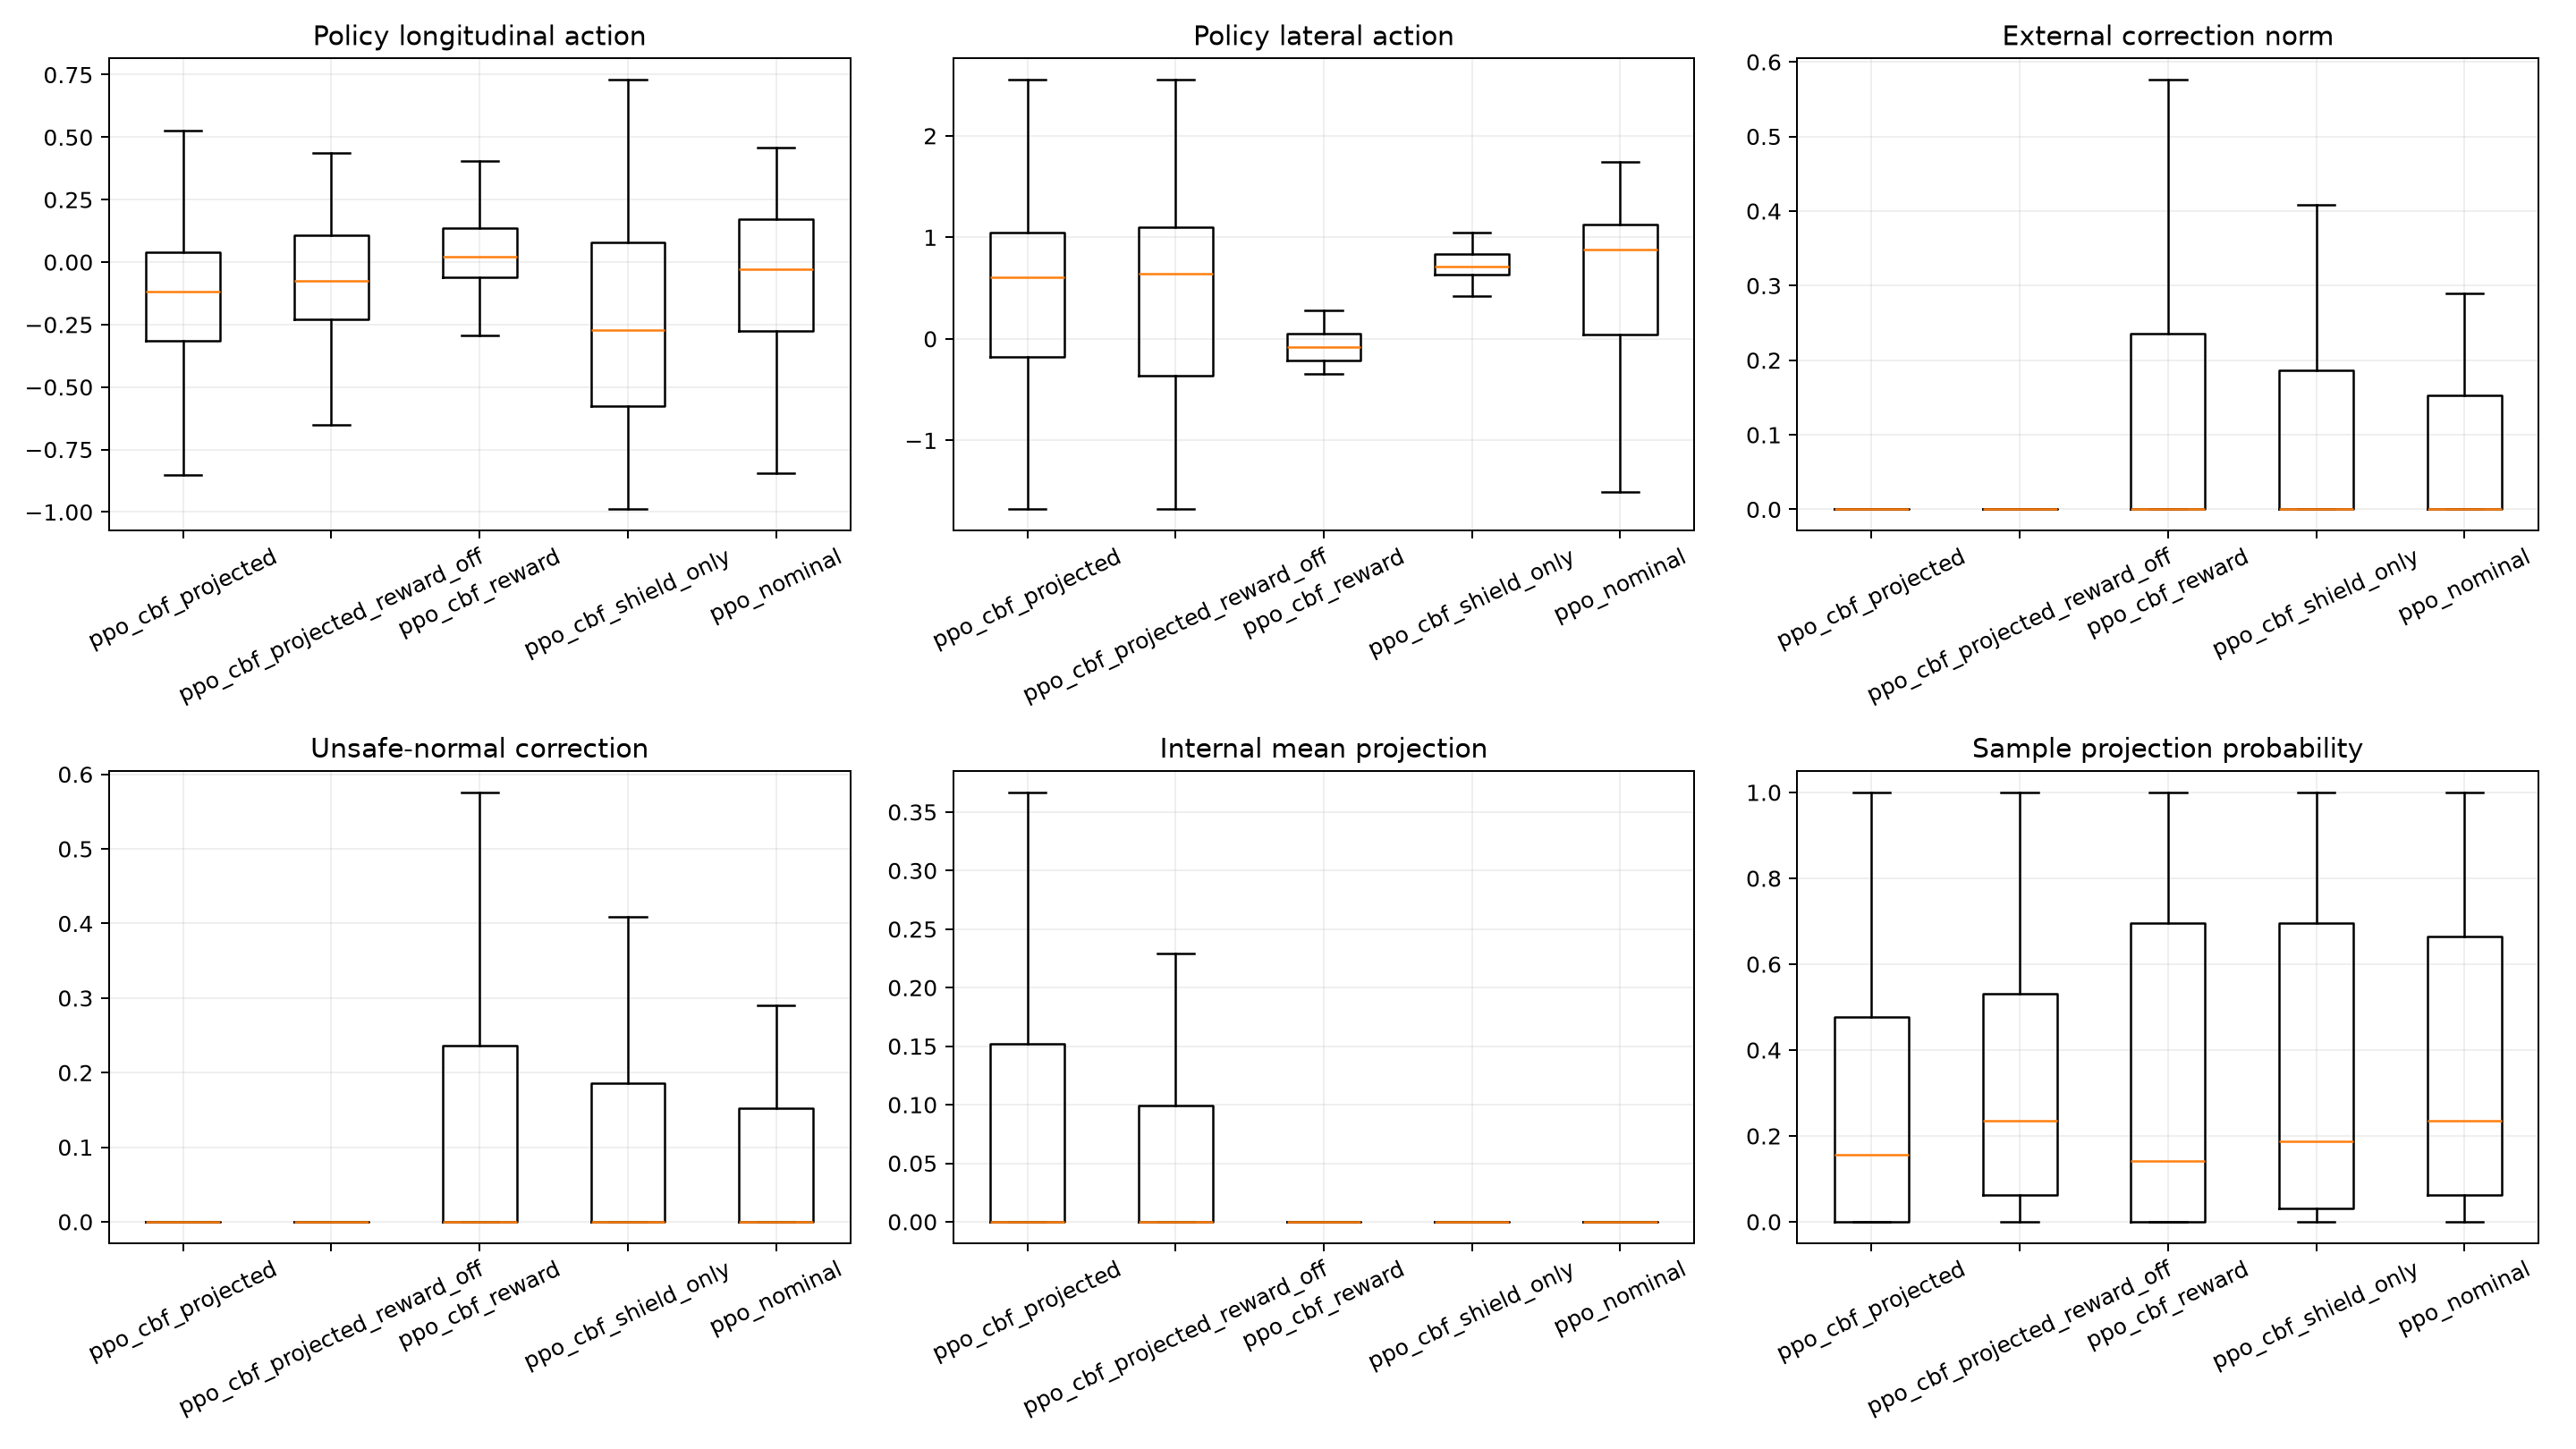

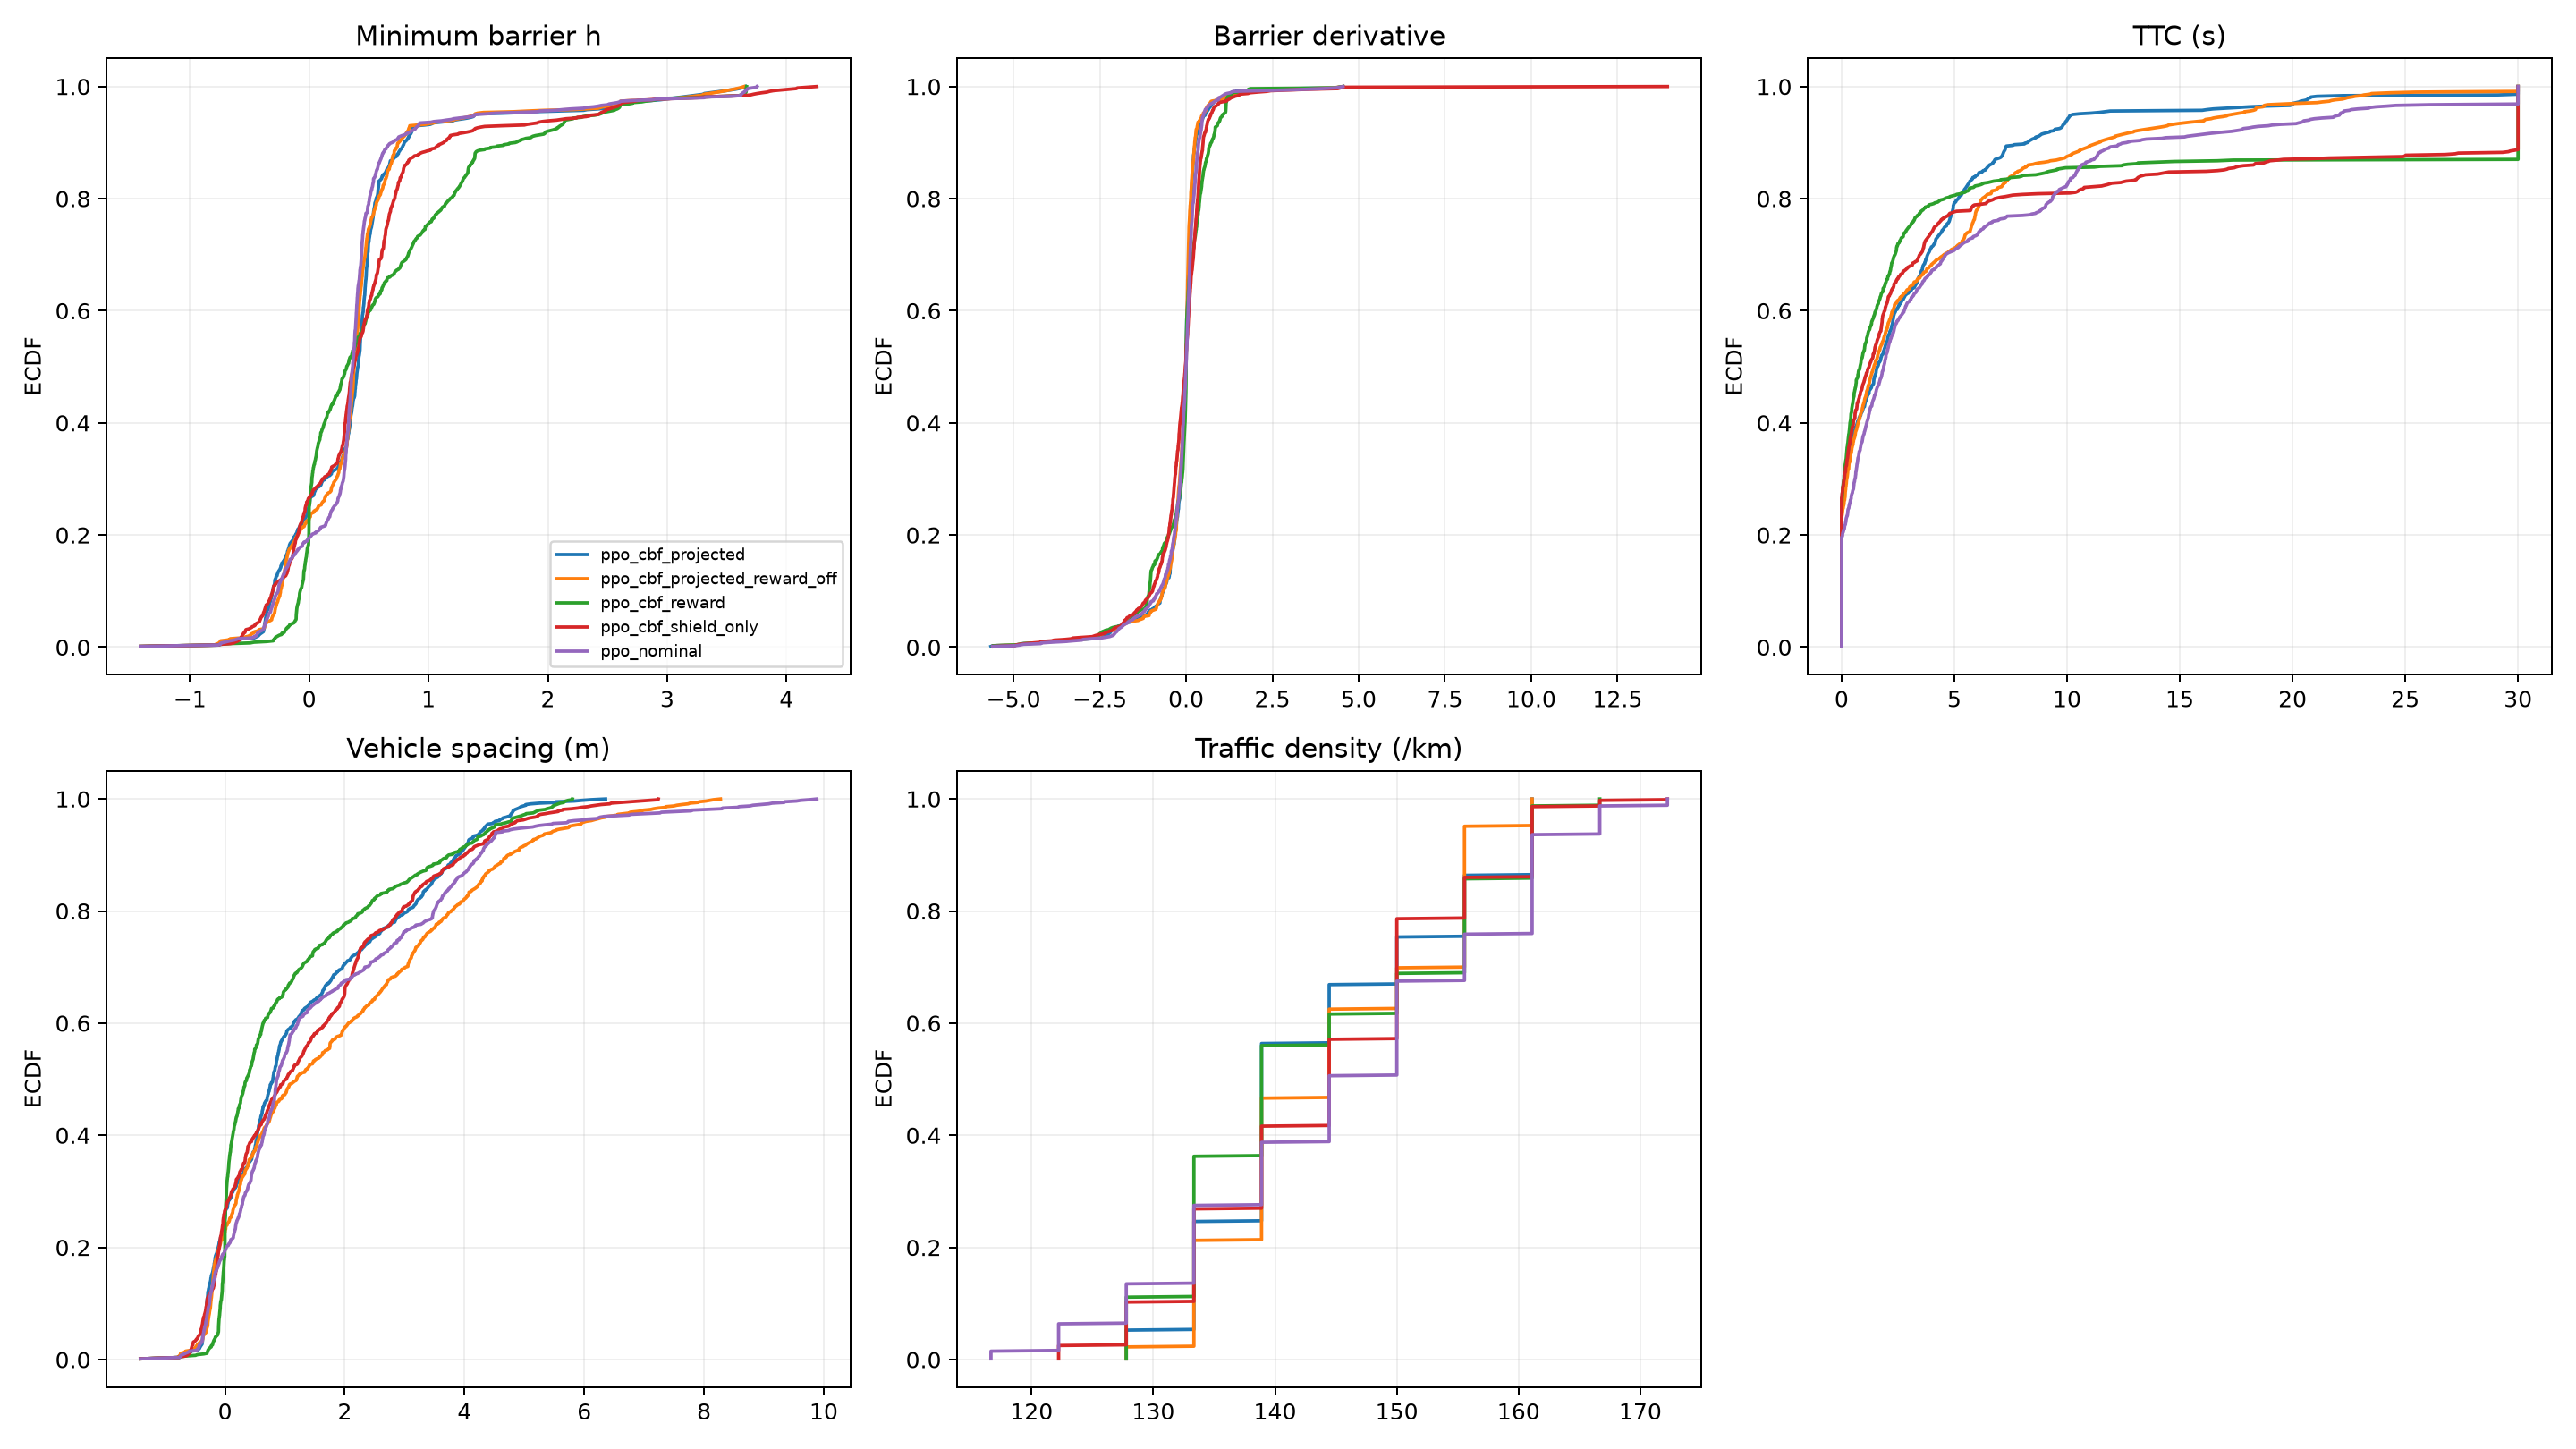

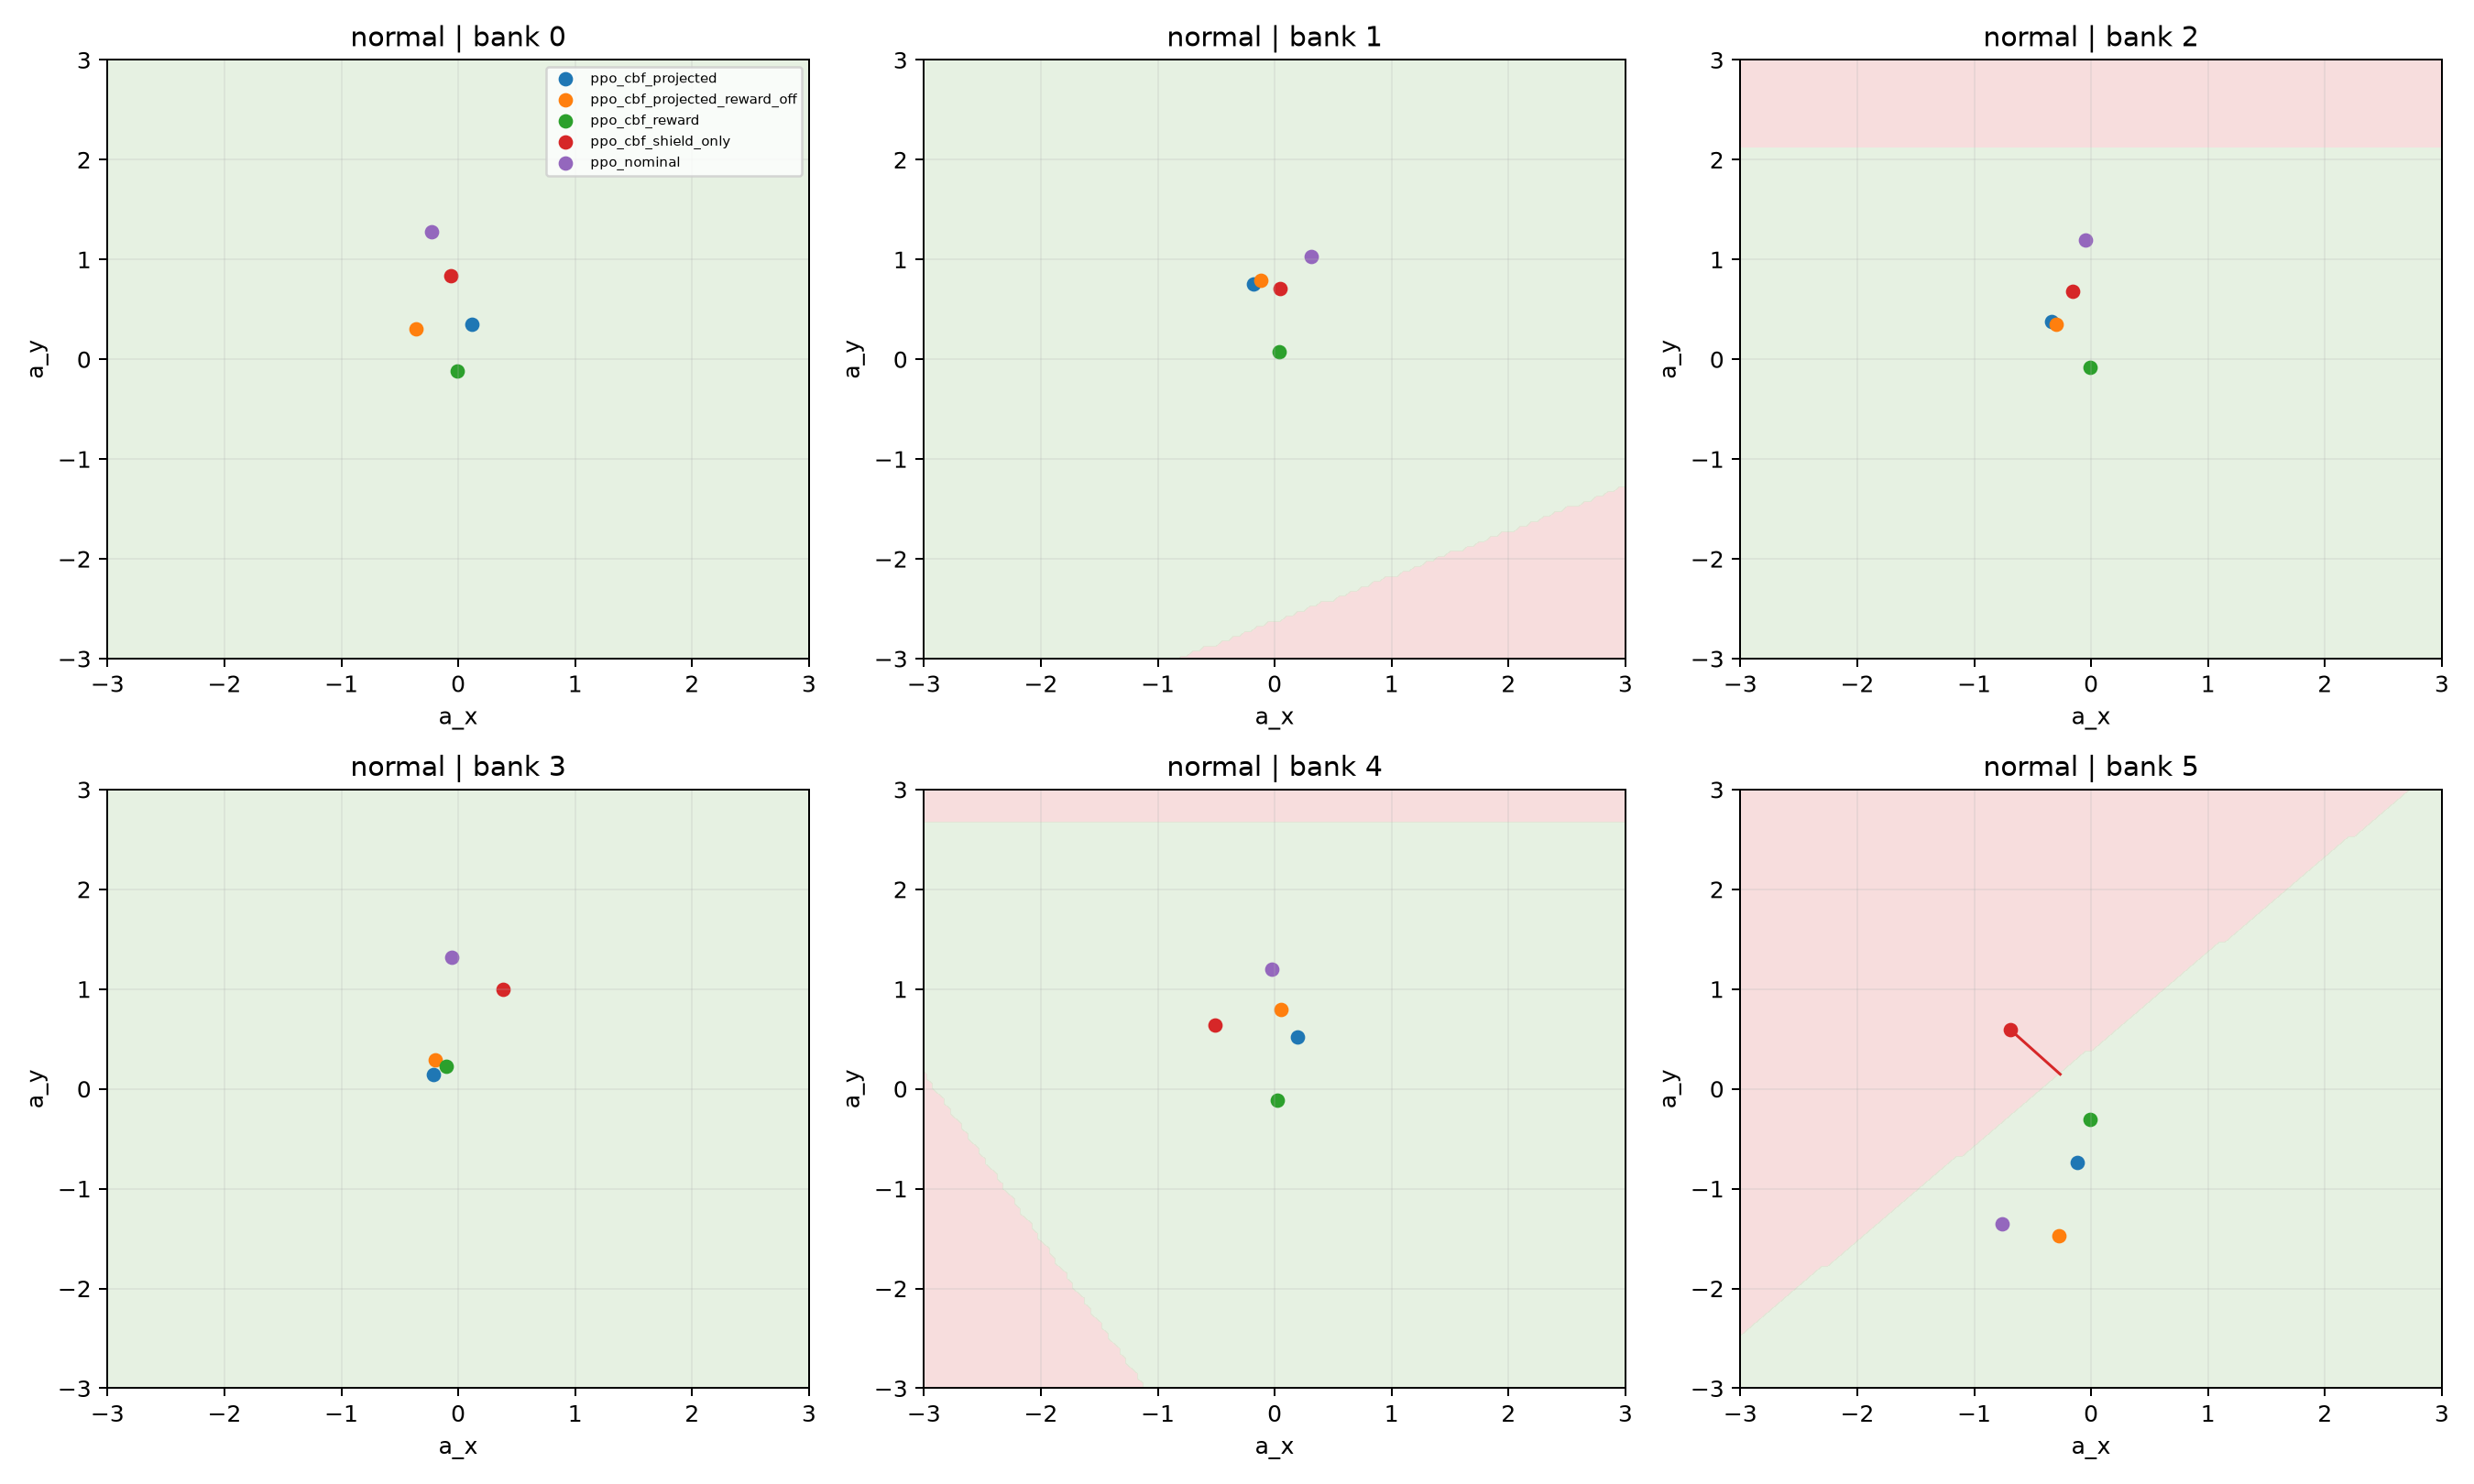

In [124]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

PPO_PROGRESSION_DIR = Path(
    globals().get(
        "PPO_PROGRESSION_DIR",
        PROJECT_ROOT / "artifacts" / "ppo_cbf_progression",
    )
)
_ppo_result_tables = [
    ("Ten-KPI raw-versus-CBF results", PPO_PROGRESSION_DIR / "ten_kpi_summary.csv"),
    ("Paired 2x2 causal effects", PPO_PROGRESSION_DIR / "factorial_effects_summary.csv"),
    (
        "Fixed-state action-map summary",
        PPO_PROGRESSION_DIR / "counterfactuals" / "fixed_state_summary.csv",
    ),
    (
        "On-policy occupancy summary",
        PPO_PROGRESSION_DIR / "counterfactuals" / "occupancy_summary.csv",
    ),
]
for _title, _path in _ppo_result_tables:
    print(f"\n{_title}")
    if _path.exists():
        _frame = pd.read_csv(_path)
        if _path.name == "fixed_state_summary.csv":
            _frame = _frame.loc[_frame["stratum"].eq("all")]
        display(_frame)
    else:
        print("Not available yet:", _path)

for _name in [
    "fixed_state_action_distributions.png",
    "on_policy_occupancy_distributions.png",
    "fixed_state_feasible_action_maps.png",
]:
    _image_path = PPO_PROGRESSION_DIR / "counterfactuals" / _name
    if _image_path.exists():
        display(Image(filename=str(_image_path)))

In [125]:
from pathlib import Path
import pandas as pd
from IPython.display import display

PPO_PROGRESSION_DIR = Path(
    globals().get(
        "PPO_PROGRESSION_DIR",
        PROJECT_ROOT / "artifacts" / "ppo_cbf_progression",
    )
)
_manifest_path = PPO_PROGRESSION_DIR / "model_manifest.csv"
if _manifest_path.exists():
    print("Exact checkpoints used by the current tables")
    display(pd.read_csv(_manifest_path))
else:
    print("No PPO model manifest yet.")

_gradient_frames = []
for _path in PPO_PROGRESSION_DIR.glob("ppo_cbf_projected*/seed_*/actor_gradients.csv"):
    _frame = pd.read_csv(_path)
    _frame["variant"] = _path.parents[1].name
    _frame["training_seed"] = int(_path.parent.name.removeprefix("seed_"))
    _gradient_frames.append(_frame)
if _gradient_frames:
    _gradient_diagnostics = pd.concat(_gradient_frames, ignore_index=True)
    print("Projected actor gradient diagnostics")
    display(
        _gradient_diagnostics[
            [
                "variant",
                "training_seed",
                "num_timesteps",
                "g_ppo_norm",
                "g_cbf_norm",
                "g_cbf_to_g_ppo_ratio",
                "g_ppo_g_cbf_cosine",
                "mean_loss",
                "mean_infeasible_rate",
            ]
        ]
    )
else:
    print("No projected actor-gradient diagnostics yet.")

Exact checkpoints used by the current tables


,training_seed,variant,variant_label,model_path,checkpoint_policy
0,307,ppo_nominal,PPO without CBF,C:\Users\aha173\OneDrive - American University...,ensure_checkpoint
1,307,ppo_cbf_shield_only,PPO trained with CBF execution (reward-off con...,C:\Users\aha173\OneDrive - American University...,ensure_checkpoint
2,307,ppo_cbf_reward,PPO trained with CBF execution + intervention ...,C:\Users\aha173\OneDrive - American University...,ensure_checkpoint
3,307,ppo_cbf_projected_reward_off,PPO projected CBF (reward-off architecture con...,C:\Users\aha173\OneDrive - American University...,ensure_checkpoint
4,307,ppo_cbf_projected,PPO with differentiable CBF final optimization...,C:\Users\aha173\OneDrive - American University...,ensure_checkpoint


Projected actor gradient diagnostics


,variant,training_seed,num_timesteps,g_ppo_norm,g_cbf_norm,g_cbf_to_g_ppo_ratio,g_ppo_g_cbf_cosine,mean_loss,mean_infeasible_rate
0,ppo_cbf_projected,307,1000.0,0.413431,0.050927,0.141673,-0.037373,0.426636,0.091
1,ppo_cbf_projected,307,2000.0,0.489874,0.046594,0.110448,-0.053899,0.257360,0.022
2,ppo_cbf_projected,307,3000.0,0.384844,0.085202,0.249430,-0.026114,0.736851,0.126
3,ppo_cbf_projected,307,4000.0,0.404944,0.110471,0.309543,-0.181294,0.659181,0.039
4,ppo_cbf_projected,307,5000.0,0.325642,0.082853,0.298386,-0.117266,0.358860,0.052
...,...,...,...,...,...,...,...,...,...
95,ppo_cbf_projected_reward_off,307,46000.0,0.751095,0.152519,0.233702,-0.166502,0.410492,0.013
96,ppo_cbf_projected_reward_off,307,47000.0,0.582136,0.131945,0.255398,-0.168828,0.268096,0.028
97,ppo_cbf_projected_reward_off,307,48000.0,0.608651,0.123239,0.222815,-0.093071,0.382297,0.044
98,ppo_cbf_projected_reward_off,307,49000.0,0.653044,0.071624,0.122982,-0.028781,0.209404,0.017


### D.2 Interpretation Guide

The result block above loads only artifacts produced by the canonical PPO runner:

- `ten_kpi_summary.csv`: paired RAW-versus-CBF deployment results;
- `factorial_effects_summary.csv`: reward, projected-actor, and interaction contrasts;
- `counterfactuals/on_policy_occupancy.csv`: which states each policy visits;
- `counterfactuals/fixed_state_actions.csv`: every actor evaluated on the exact same states, including μ_raw, μ_safe, hard correction, normal/tangent components, active constraint type, and sampled-z projection rates;
- `actor_gradients.csv`: PPO-versus-internalization actor-gradient norm ratio and cosine.

PPO has V(s), not Q(s,a), so the DDPG critic-contour plot is replaced by feasible-region action maps. This is a mathematical difference, not a missing result.

### D.3 Re-run All PPO Evaluations Inline Without Retraining

This cell reloads every saved PPO variant and reruns the paired ten-KPI, 2 × 2, occupancy, fixed-state, correction-decomposition, and stochastic-projection evaluations. It does not update model parameters. Subprocess output streams directly beneath the cell.

In [126]:
import subprocess
import sys
from pathlib import Path
import pandas as pd
from IPython.display import display

_ppo_eval_root = Path(globals().get("PROJECT_ROOT", Path.cwd())).resolve()
_ppo_eval_dir = Path(
    globals().get(
        "PPO_PROGRESSION_DIR",
        _ppo_eval_root / "artifacts" / "ppo_cbf_progression",
    )
)
_ppo_eval_command = [
    sys.executable,
    str(_ppo_eval_root / "scripts" / "run_ppo_cbf_progression.py"),
    "--project-root", str(_ppo_eval_root),
    "--output-dir", str(_ppo_eval_dir),
    "--traffic-model", "mtm",
    "--device", str(globals().get("DEVICE", "cpu")),
    "--skip-training",
    "--seeds", "307",
    "--variants",
    "ppo_nominal",
    "ppo_cbf_shield_only",
    "ppo_cbf_reward",
    "ppo_cbf_projected_reward_off",
    "ppo_cbf_projected",
    "--eval-seeds",
    "900000", "900001", "900002", "900003", "900004",
    "900005", "900006", "900007", "900008", "900009",
    "--eval-timesteps", "800",
]
print("Reloading saved PPO checkpoints; evaluation output will stream inline.")
_ppo_eval_result = subprocess.run(
    _ppo_eval_command,
    cwd=str(_ppo_eval_root),
    text=True,
)
if _ppo_eval_result.returncode != 0:
    raise RuntimeError(
        f"PPO evaluation failed with exit code {_ppo_eval_result.returncode}"
    )

PPO_PROGRESSION_KPI_PATH = _ppo_eval_dir / "ten_kpi_summary.csv"
ppo_progression_kpis = pd.read_csv(PPO_PROGRESSION_KPI_PATH)
display(ppo_progression_kpis)

Reloading saved PPO checkpoints; evaluation output will stream inline.


,variant,variant_label,mode,KPI,Mean,SD,N
0,ppo_nominal,PPO without CBF,raw,Episode return,1.468803e+01,6.009684e+00,10
1,ppo_nominal,PPO without CBF,raw,Episode length (steps),5.865267e+01,1.692957e+01,10
2,ppo_nominal,PPO without CBF,raw,Ego collisions / km,5.384885e+00,3.289904e+00,10
3,ppo_nominal,PPO without CBF,raw,Minimum h,-1.595535e+00,4.635256e-01,10
4,ppo_nominal,PPO without CBF,raw,QP failure rate,0.000000e+00,0.000000e+00,10
...,...,...,...,...,...,...,...
95,ppo_cbf_projected,PPO with differentiable CBF final optimization...,cbf,Abs speed error (m/s),3.500152e+00,4.166937e-01,10
96,ppo_cbf_projected,PPO with differentiable CBF final optimization...,cbf,Mean lateral tracking error (m),2.369047e+00,9.995432e-01,10
97,ppo_cbf_projected,PPO with differentiable CBF final optimization...,cbf,Intervention rate,0.000000e+00,0.000000e+00,10
98,ppo_cbf_projected,PPO with differentiable CBF final optimization...,cbf,Correction norm,2.222757e-10,3.267854e-10,10


## E. Optional Legacy Experiment Activation and Diagnostics

The remaining activation cells belong to the retained DDPG workflow. They are not required by the primary PPO runner, which selects MTM explicitly and records the resolved configuration in its artifacts.

In [34]:
# Optional legacy environment: activate force-traffic explicitly.
import copy

BASE_LANELESS_SEED = int(globals().get("BASE_LANELESS_SEED", SEED))
ACTIVE_CBF_EPS_SIDE = float(globals().get(
    "CBF_EPS_SIDE",
    0.10,
))

ACTIVE_ENV_NAME = "current_force"
ACTIVE_ARTIFACT_SUFFIX = ACTIVE_ENV_NAME
ACTIVE_TRAFFIC_MODEL = "force"

CURRENT_FORCE_ENV_CONFIG = copy.deepcopy(ENV_CONFIG)
CURRENT_FORCE_ENV_CONFIG.update(
    {
        "traffic_model": "force",
        "vehicles_count": 35,
        "sensing_range": 80.0,
        "episode_steps": EPISODE_STEPS,
        "duration": EPISODE_STEPS,
        "terminate_on_collision": True,
    }
)

CURRENT_FORCE_TRAINING_CONFIG = {
    "device": DEVICE,
    "ppo_timesteps": TOTAL_TIMESTEPS,
    "ddpg_timesteps": DDPG_TOTAL_TIMESTEPS,
    "ddpg_cbf_timesteps": DDPG_CBF_TOTAL_TIMESTEPS,
    "guided_ddpg_cbf_timesteps": DDPG_CBF_TOTAL_TIMESTEPS,
    "n_envs": DDPG_NUM_ENVS,
    "cbf_n_envs": DDPG_CBF_NUM_ENVS,
    "lambda_filter": CBF_FILTER_REWARD_LAMBDA,
    "k0": CBF_K0,
    "k1": CBF_K1,
    "eps_side": CBF_EPS_SIDE,
    "event_threshold": 0.03,
    "experiment_timesteps": 20_000,
    "train_eval_freq": 5_000,
    "train_eval_episodes": 2,
    "final_eval_episodes": 20,
    "seed": BASE_LANELESS_SEED,
}

ACTIVE_ENV_CONFIG = copy.deepcopy(CURRENT_FORCE_ENV_CONFIG)
ACTIVE_TRAINING_CONFIG = dict(CURRENT_FORCE_TRAINING_CONFIG)

# Make the selected environment active for ordinary notebook cells too.
ENV_CONFIG = copy.deepcopy(ACTIVE_ENV_CONFIG)
if "DEVICE" not in globals():
    DEVICE = ACTIVE_TRAINING_CONFIG["device"]
TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["ppo_timesteps"])
DDPG_TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["ddpg_timesteps"])
DDPG_CBF_TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["ddpg_cbf_timesteps"])
GUIDED_DDPG_CBF_TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["guided_ddpg_cbf_timesteps"])
DDPG_NUM_ENVS = int(ACTIVE_TRAINING_CONFIG["n_envs"])
DDPG_CBF_NUM_ENVS = int(ACTIVE_TRAINING_CONFIG["cbf_n_envs"])
CBF_FILTER_REWARD_LAMBDA = float(ACTIVE_TRAINING_CONFIG["lambda_filter"])
CBF_K0 = float(ACTIVE_TRAINING_CONFIG["k0"])
CBF_K1 = float(ACTIVE_TRAINING_CONFIG["k1"])
CBF_EPS_SIDE = float(ACTIVE_TRAINING_CONFIG["eps_side"])
if "SEED" not in globals():
    SEED = int(ACTIVE_TRAINING_CONFIG["seed"])
print(f"Activated {ACTIVE_ENV_NAME}:", {"traffic_model": ACTIVE_ENV_CONFIG["traffic_model"], "vehicles": ACTIVE_ENV_CONFIG["vehicles_count"], "timesteps": ACTIVE_TRAINING_CONFIG["experiment_timesteps"], "artifact_suffix": ACTIVE_ARTIFACT_SUFFIX})


Activated current_force: {'traffic_model': 'force', 'vehicles': 35, 'timesteps': 20000, 'artifact_suffix': 'current_force'}


In [8]:
# Canonical default environment: activate MTM congested/uncertain traffic.
import copy

BASE_LANELESS_SEED = int(globals().get("BASE_LANELESS_SEED", SEED))
ACTIVE_CBF_EPS_SIDE = float(globals().get(
    "CBF_EPS_SIDE",
    0.10,
))

ACTIVE_ENV_NAME = "mtm_congested_uncertain"
ACTIVE_ARTIFACT_SUFFIX = "mtmcu"
ACTIVE_TRAFFIC_MODEL = "mtm"

MTM_CONGESTED_UNCERTAIN_ENV_CONFIG = copy.deepcopy(ENV_CONFIG)
MTM_CONGESTED_UNCERTAIN_ENV_CONFIG.update(
    {
        "traffic_model": "mtm",
        "ego_controlled": True,
        "road_length": 380.0,
        "vehicles_count": 55,
        "sensing_range": 90.0,
        "desired_speed_range": [15.0, 25.0],
        "initial_speed_fraction_range": [0.55, 1.10],
        "episode_steps": EPISODE_STEPS,
        "duration": EPISODE_STEPS,
        "terminate_on_collision": True,
        "show_trajectories": False,
    }
)
MTM_CONGESTED_UNCERTAIN_ENV_CONFIG["mtm"] = copy.deepcopy(MTM_CONGESTED_UNCERTAIN_ENV_CONFIG.get("mtm", {}))
MTM_CONGESTED_UNCERTAIN_ENV_CONFIG["mtm"].update(
    {
        "leader_range": 90.0,
        "profile_probabilities": {"normal": 0.45, "aggressive": 0.30, "cautious": 0.25},
    }
)

MTM_CONGESTED_UNCERTAIN_TRAINING_CONFIG = {
    "device": DEVICE,
    "ppo_timesteps": TOTAL_TIMESTEPS,
    "ddpg_timesteps": DDPG_TOTAL_TIMESTEPS,
    "ddpg_cbf_timesteps": DDPG_CBF_TOTAL_TIMESTEPS,
    "guided_ddpg_cbf_timesteps": DDPG_CBF_TOTAL_TIMESTEPS,
    "n_envs": DDPG_NUM_ENVS,
    "cbf_n_envs": DDPG_CBF_NUM_ENVS,
    "lambda_filter": CBF_FILTER_REWARD_LAMBDA,
    "k0": CBF_K0,
    "k1": CBF_K1,
    "eps_side": CBF_EPS_SIDE,
    "event_threshold": 0.03,
    "experiment_timesteps": 20_000,
    "train_eval_freq": 5_000,
    "train_eval_episodes": 2,
    "final_eval_episodes": 20,
    "seed": BASE_LANELESS_SEED + 300_000,
}

ACTIVE_ENV_CONFIG = copy.deepcopy(MTM_CONGESTED_UNCERTAIN_ENV_CONFIG)
ACTIVE_TRAINING_CONFIG = dict(MTM_CONGESTED_UNCERTAIN_TRAINING_CONFIG)

# Make the selected environment active for ordinary notebook cells too.
ENV_CONFIG = copy.deepcopy(ACTIVE_ENV_CONFIG)
if "DEVICE" not in globals():
    DEVICE = ACTIVE_TRAINING_CONFIG["device"]
TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["ppo_timesteps"])
DDPG_TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["ddpg_timesteps"])
DDPG_CBF_TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["ddpg_cbf_timesteps"])
GUIDED_DDPG_CBF_TOTAL_TIMESTEPS = int(ACTIVE_TRAINING_CONFIG["guided_ddpg_cbf_timesteps"])
DDPG_NUM_ENVS = int(ACTIVE_TRAINING_CONFIG["n_envs"])
DDPG_CBF_NUM_ENVS = int(ACTIVE_TRAINING_CONFIG["cbf_n_envs"])
CBF_FILTER_REWARD_LAMBDA = float(ACTIVE_TRAINING_CONFIG["lambda_filter"])
CBF_K0 = float(ACTIVE_TRAINING_CONFIG["k0"])
CBF_K1 = float(ACTIVE_TRAINING_CONFIG["k1"])
CBF_EPS_SIDE = float(ACTIVE_TRAINING_CONFIG["eps_side"])
if "SEED" not in globals():
    SEED = int(ACTIVE_TRAINING_CONFIG["seed"])
print(
    f"Activated {ACTIVE_ENV_NAME}:",
    {
        "traffic_model": ACTIVE_ENV_CONFIG["traffic_model"],
        "vehicles": ACTIVE_ENV_CONFIG["vehicles_count"],
        "road_length": ACTIVE_ENV_CONFIG["road_length"],
        "timesteps": ACTIVE_TRAINING_CONFIG["experiment_timesteps"],
        "artifact_suffix": ACTIVE_ARTIFACT_SUFFIX,
    },
)


NameError: name 'CBF_FILTER_REWARD_LAMBDA' is not defined

In [36]:
# Common active-environment script runners.
import json
import subprocess

# Prefer the environment that belongs to this project. The workspace-level
# environment can target a different Python version and incompatible wheels.
WORKSPACE_ROOT = PROJECT_ROOT
SCRIPT_PYTHON = PROJECT_ROOT / ".venv" / "Scripts" / "python.exe"
if not SCRIPT_PYTHON.exists():
    SCRIPT_PYTHON = PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe"
if not SCRIPT_PYTHON.exists():
    SCRIPT_PYTHON = Path(sys.executable)


def _require_active_environment() -> None:
    if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
        raise RuntimeError("Run either the current-force activation cell or the MTM congested/uncertain activation cell first.")


def _active_artifact_suffix() -> str:
    _require_active_environment()
    return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))


def _active_env_args() -> list[str]:
    _require_active_environment()
    return [
        "--traffic-model",
        str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
        "--env-config-json",
        json.dumps(ACTIVE_ENV_CONFIG),
    ]


def _active_cbf_args() -> list[str]:
    _require_active_environment()
    return [
        "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
        "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
        "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
        "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
    ]


def run_laneless_script(script_name: str, *args: str) -> subprocess.CompletedProcess:
    command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
    print("Running:", " ".join(command))
    return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)


def run_active_agent_training(agent: str) -> subprocess.CompletedProcess:
    _require_active_environment()
    agent = agent.lower()
    task_by_agent = {
        "ppo": "ppo-train",
        "ddpg": "ddpg-train",
        "ddpg-cbf": "ddpg-cbf-train",
        "guided-ddpg-cbf": "guided-ddpg-cbf-train",
    }
    timesteps_by_agent = {
        "ppo": ACTIVE_TRAINING_CONFIG["ppo_timesteps"],
        "ddpg": ACTIVE_TRAINING_CONFIG["ddpg_timesteps"],
        "ddpg-cbf": ACTIVE_TRAINING_CONFIG["ddpg_cbf_timesteps"],
        "guided-ddpg-cbf": ACTIVE_TRAINING_CONFIG["guided_ddpg_cbf_timesteps"],
    }
    if agent not in task_by_agent:
        raise ValueError(f"Unknown agent {agent!r}; expected one of {sorted(task_by_agent)}")
    args = [
        task_by_agent[agent],
        "--timesteps", str(int(timesteps_by_agent[agent])),
        "--n-envs", str(int(ACTIVE_TRAINING_CONFIG["cbf_n_envs" if "cbf" in agent else "n_envs"])),
        "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
        "--project-root", str(PROJECT_ROOT),
        "--run-tag", f"{_active_artifact_suffix()}_{agent}",
        "--artifact-suffix", _active_artifact_suffix(),
        *_active_env_args(),
    ]
    if "cbf" in agent:
        args.extend(_active_cbf_args())
    return run_laneless_script("run_laneless_notebook_task.py", *args)


def _active_experiment_common_args() -> list[str]:
    _require_active_environment()
    return [
        "--timesteps", str(int(ACTIVE_TRAINING_CONFIG["experiment_timesteps"])),
        "--train-eval-freq", str(int(ACTIVE_TRAINING_CONFIG["train_eval_freq"])),
        "--train-eval-episodes", str(int(ACTIVE_TRAINING_CONFIG["train_eval_episodes"])),
        "--final-eval-episodes", str(int(ACTIVE_TRAINING_CONFIG["final_eval_episodes"])),
        "--seed", str(int(ACTIVE_TRAINING_CONFIG["seed"])),
        "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
        "--n-envs", str(int(ACTIVE_TRAINING_CONFIG["n_envs"])),
        "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
        "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
        "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
        "--event-threshold", str(float(ACTIVE_TRAINING_CONFIG["event_threshold"])),
        *_active_env_args(),
    ]


def run_active_lambda_event_bc_pilot() -> subprocess.CompletedProcess:
    return run_laneless_script("cbf_lambda_event_bc_pilot_sweep.py", *_active_experiment_common_args())


def run_active_reward_ablation() -> subprocess.CompletedProcess:
    return run_laneless_script("cbf_reward_term_ablation.py", *_active_experiment_common_args())


def run_active_safety_obs_experiment() -> subprocess.CompletedProcess:
    return run_laneless_script("cbf_safety_obs_experiment.py", *_active_experiment_common_args())


def run_active_traffic_smoke() -> subprocess.CompletedProcess:
    _require_active_environment()
    return run_laneless_script(
        "mtm_laneless_smoke.py",
        "--steps", str(min(int(EPISODE_POLICY_STEPS), 400)),
        "--vehicles", str(int(ACTIVE_ENV_CONFIG.get("vehicles_count", 35))),
        "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
    )


def run_active_normal_policy_render(agent: str, episodes: int = 10, steps: Optional[int] = None, seed: Optional[int] = None) -> subprocess.CompletedProcess:
    _require_active_environment()
    agent = agent.lower()
    if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
        raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
    args = [
        "--variant", agent,
        "--episodes", str(int(episodes)),
        "--steps", str(int(steps or EPISODE_POLICY_STEPS)),
        "--seed", str(int(SEED if seed is None else seed)),
        "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
        "--project-root", str(PROJECT_ROOT),
        "--artifact-suffix", _active_artifact_suffix(),
        *_active_env_args(),
    ]
    if "cbf" in agent:
        args.extend(_active_cbf_args())
    return run_laneless_script("render_laneless_karalakou.py", *args)


def run_active_policy_scenario(
    scenario_name: str,
    policies: Any = ("ddpg", "ddpg-cbf", "guided-ddpg-cbf"),
    steps: int = 240,
    episodes: int = 1,
    seed: Optional[int] = None,
) -> subprocess.CompletedProcess:
    _require_active_environment()
    args = [
        "--scenario", scenario_name,
        "--steps", str(int(steps)),
        "--episodes", str(int(episodes)),
        "--seed", str(int(SEED if seed is None else seed)),
        "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
        "--project-root", str(PROJECT_ROOT),
        "--artifact-suffix", _active_artifact_suffix(),
        *_active_cbf_args(),
        *_active_env_args(),
    ]
    for policy in policies:
        args.extend(["--variant", str(policy)])
    return run_laneless_script("render_laneless_policy_scenario.py", *args)


RUN_ACTIVE_TRAFFIC_SMOKE = bool(globals().get("RUN_ACTIVE_TRAFFIC_SMOKE", False))
# PPO is launched only by the primary workflow cell in Section B.
# Keeping it out of this legacy DDPG dispatcher prevents duplicate runs.
RUN_ACTIVE_DDPG_TRAIN = bool(globals().get("RUN_ACTIVE_DDPG_TRAIN", False))
RUN_ACTIVE_DDPG_CBF_TRAIN = bool(globals().get("RUN_ACTIVE_DDPG_CBF_TRAIN", False))
RUN_ACTIVE_GUIDED_DDPG_CBF_TRAIN = bool(globals().get("RUN_ACTIVE_GUIDED_DDPG_CBF_TRAIN", False))
RUN_ACTIVE_LAMBDA_EVENT_BC_PILOT = bool(globals().get("RUN_ACTIVE_LAMBDA_EVENT_BC_PILOT", False))
RUN_ACTIVE_REWARD_ABLATION = bool(globals().get("RUN_ACTIVE_REWARD_ABLATION", False))
RUN_ACTIVE_SAFETY_OBS_EXPERIMENT = bool(globals().get("RUN_ACTIVE_SAFETY_OBS_EXPERIMENT", False))

if RUN_ACTIVE_TRAFFIC_SMOKE:
    run_active_traffic_smoke()
if RUN_ACTIVE_DDPG_TRAIN:
    run_active_agent_training("ddpg")
if RUN_ACTIVE_DDPG_CBF_TRAIN:
    run_active_agent_training("ddpg-cbf")
if RUN_ACTIVE_GUIDED_DDPG_CBF_TRAIN:
    run_active_agent_training("guided-ddpg-cbf")
if RUN_ACTIVE_LAMBDA_EVENT_BC_PILOT:
    run_active_lambda_event_bc_pilot()
if RUN_ACTIVE_REWARD_ABLATION:
    run_active_reward_ablation()
if RUN_ACTIVE_SAFETY_OBS_EXPERIMENT:
    run_active_safety_obs_experiment()


<!-- GENERATED_POLICY_RENDER_SECTION -->
### E.1 Normal Policy Renders
Run one activation cell first, then run any of these cells to watch five ordinary episodes in the active traffic environment.

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT
        SCRIPT_PYTHON = PROJECT_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=10, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or EPISODE_POLICY_STEPS)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# DDPG alone: five normal episodes in the active traffic environment.
run_active_normal_policy_render("ddpg", episodes=5)

Running: C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\.venv\Scripts\python.exe C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\scripts\render_laneless_karalakou.py --variant ddpg --episodes 5 --steps 800 --seed 7 --device cpu --project-root C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making --artifact-suffix mtmcu --traffic-model mtm --env-config-json {"road_length": 380.0, "road_width": 10.2, "dt": 0.25, "simulation_frequency": 4, "policy_frequency": 4, "vehicles_count": 55, "neighbors_count": 5, "sensing_range": 90.0, "episode_steps": 800, "duration": 800, "terminate_on_collision": true, "gamma_nudge": 0.0, "bounds": {"ax_min": -3.0, "ax_max": 3.0, "ay_min": -3.0, "ay_max": 3.0}, "ego_controlled": true, 

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT
        SCRIPT_PYTHON = PROJECT_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=10, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or EPISODE_POLICY_STEPS)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# DDPG + CBF reward: five normal episodes in the active traffic environment.
run_active_normal_policy_render("ddpg-cbf", episodes=5)

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT
        SCRIPT_PYTHON = PROJECT_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=10, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or EPISODE_POLICY_STEPS)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# DDPG + CBF reward + actor loss: five normal episodes in the active traffic environment.
run_active_normal_policy_render("guided-ddpg-cbf", episodes=5)

<!-- GENERATED_POLICY_RENDER_SECTION -->
### E.2 Fixed Diagnostic Scenario Simulations
Each cell launches the same designed scene for DDPG, DDPG-CBF reward, and DDPG-CBF reward + actor loss, sequentially, in the active traffic environment.

<!-- GENERATED_POLICY_RENDER_SECTION -->
#### E.2.1 Open Passing Gap
A clear side gap exists behind a slow leader; the policy should commit smoothly if it learned passing.

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT
        SCRIPT_PYTHON = PROJECT_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=10, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or EPISODE_POLICY_STEPS)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# Open Passing Gap: live simulation for all three DDPG policies.
run_active_policy_scenario("safe_overtake_open_upper_gap", steps=240, episodes=1)

<!-- GENERATED_POLICY_RENDER_SECTION -->
#### E.2.2 Fast Closing Side Vehicle
A tempting side gap is actually closing fast; the policy should reject it.

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT
        SCRIPT_PYTHON = PROJECT_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=10, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or EPISODE_POLICY_STEPS)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# Fast Closing Side Vehicle: live simulation for all three DDPG policies.
run_active_policy_scenario("unsafe_overtake_fast_closing_upper", steps=240, episodes=1)

<!-- GENERATED_POLICY_RENDER_SECTION -->
#### E.2.3 Boxed In
No clean nearby side gap exists; the policy should avoid forcing a pass.

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT
        SCRIPT_PYTHON = PROJECT_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=10, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or EPISODE_POLICY_STEPS)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# Boxed In: live simulation for all three DDPG policies.
run_active_policy_scenario("boxed_in_hold_position", steps=240, episodes=1)

<!-- GENERATED_POLICY_RENDER_SECTION -->
#### E.2.4 Rear Pressure Escape
A fast rear vehicle closes on ego; the policy should escape only through the cleaner side.

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT
        SCRIPT_PYTHON = PROJECT_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=10, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or EPISODE_POLICY_STEPS)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# Rear Pressure Escape: live simulation for all three DDPG policies.
run_active_policy_scenario("rear_pressure_escape", steps=240, episodes=1)

<!-- GENERATED_POLICY_RENDER_SECTION -->
#### E.2.5 Boundary Recovery
Ego starts near the road edge with a blocker ahead; the policy should recover inward.

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT
        SCRIPT_PYTHON = PROJECT_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=10, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or EPISODE_POLICY_STEPS)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# Boundary Recovery: live simulation for all three DDPG policies.
run_active_policy_scenario("boundary_recovery_no_upper_squeeze", steps=240, episodes=1)

<!-- GENERATED_POLICY_RENDER_SECTION -->
#### E.2.6 Sudden Lead Slowdown
The leader is much slower and both side gaps are risky; the policy should react without diving into traffic.

In [ ]:
# Auto-bootstrap active render helpers if the common runner cell was not executed.
if "run_active_normal_policy_render" not in globals() or "run_active_policy_scenario" not in globals():
    def _bootstrap_active_render_helpers():
        import json
        import subprocess
        import sys
        from pathlib import Path

        if "PROJECT_ROOT" not in globals():
            raise RuntimeError("Run the notebook setup cells first so PROJECT_ROOT is defined.")

        global WORKSPACE_ROOT, SCRIPT_PYTHON
        global _require_active_environment, _active_artifact_suffix, _active_env_args, _active_cbf_args
        global run_laneless_script, run_active_normal_policy_render, run_active_policy_scenario

        WORKSPACE_ROOT = PROJECT_ROOT
        SCRIPT_PYTHON = PROJECT_ROOT / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = PROJECT_ROOT.parent / ".venv" / "Scripts" / "python.exe"
        if not SCRIPT_PYTHON.exists():
            SCRIPT_PYTHON = Path(sys.executable)

        def _require_active_environment():
            if "ACTIVE_ENV_CONFIG" not in globals() or "ACTIVE_TRAINING_CONFIG" not in globals():
                raise RuntimeError("Run one environment activation cell first, then run this render cell again.")

        def _active_artifact_suffix():
            _require_active_environment()
            return str(globals().get("ACTIVE_ARTIFACT_SUFFIX", ACTIVE_ENV_NAME))

        def _active_env_args():
            _require_active_environment()
            return [
                "--traffic-model", str(ACTIVE_ENV_CONFIG.get("traffic_model", "force")),
                "--env-config-json", json.dumps(ACTIVE_ENV_CONFIG),
            ]

        def _active_cbf_args():
            _require_active_environment()
            return [
                "--lambda-filter", str(float(ACTIVE_TRAINING_CONFIG["lambda_filter"])),
                "--k0", str(float(ACTIVE_TRAINING_CONFIG["k0"])),
                "--k1", str(float(ACTIVE_TRAINING_CONFIG["k1"])),
                "--eps-side", str(float(ACTIVE_TRAINING_CONFIG["eps_side"])),
            ]

        def run_laneless_script(script_name, *args):
            command = [str(SCRIPT_PYTHON), str(PROJECT_ROOT / "scripts" / script_name), *map(str, args)]
            print("Running:", " ".join(command))
            return subprocess.run(command, cwd=str(WORKSPACE_ROOT), text=True, check=True)

        def run_active_normal_policy_render(agent, episodes=10, steps=None, seed=None):
            _require_active_environment()
            agent = agent.lower()
            if agent not in {"ddpg", "ddpg-cbf", "guided-ddpg-cbf"}:
                raise ValueError("Normal policy render supports 'ddpg', 'ddpg-cbf', or 'guided-ddpg-cbf'.")
            args = [
                "--variant", agent,
                "--episodes", str(int(episodes)),
                "--steps", str(int(steps or EPISODE_POLICY_STEPS)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_env_args(),
            ]
            if "cbf" in agent:
                args.extend(_active_cbf_args())
            return run_laneless_script("render_laneless_karalakou.py", *args)

        def run_active_policy_scenario(scenario_name, policies=("ddpg", "ddpg-cbf", "guided-ddpg-cbf"), steps=240, episodes=1, seed=None):
            _require_active_environment()
            args = [
                "--scenario", scenario_name,
                "--steps", str(int(steps)),
                "--episodes", str(int(episodes)),
                "--seed", str(int(SEED if seed is None else seed)),
                "--device", str(ACTIVE_TRAINING_CONFIG["device"]),
                "--project-root", str(PROJECT_ROOT),
                "--artifact-suffix", _active_artifact_suffix(),
                *_active_cbf_args(),
                *_active_env_args(),
            ]
            for policy in policies:
                args.extend(["--variant", str(policy)])
            return run_laneless_script("render_laneless_policy_scenario.py", *args)

    _bootstrap_active_render_helpers()

# Sudden Lead Slowdown: live simulation for all three DDPG policies.
run_active_policy_scenario("sudden_lead_slowdown", steps=240, episodes=1)

## Appendix — CBF Safety-Potential Reward Variant

This trains the plain DDPG policy without a CBF action shield, but replaces the legacy vehicle potential field with the CBF-clearance-based `safety_cf` reward term. It writes to a separate directory, so it cannot resume a legacy DDPG run.

In [26]:
# Set this to True, then run this cell to train only the reward-only DDPG variant.
RUN_DDPG_CBF_SAFETY_REWARD = bool(globals().get("RUN_DDPG_CBF_SAFETY_REWARD", False))

if RUN_DDPG_CBF_SAFETY_REWARD:
    import json
    import subprocess
    from collections import deque

    _ddpg_safety_env_config = dict(globals().get("ACTIVE_ENV_CONFIG", ENV_CONFIG))
    _ddpg_safety_suffix = str(globals().get("ACTIVE_ARTIFACT_SUFFIX", "default"))
    DDPG_CBF_SAFETY_REWARD_OUTPUT_DIR = ARTIFACT_DIR / f"ddpg_cbf_safety_reward_{_ddpg_safety_suffix}"
    DDPG_CBF_SAFETY_REWARD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    DDPG_CBF_SAFETY_REWARD_ENV_CONFIG_PATH = DDPG_CBF_SAFETY_REWARD_OUTPUT_DIR / "env_config.json"
    DDPG_CBF_SAFETY_REWARD_ENV_CONFIG_PATH.write_text(json.dumps(_ddpg_safety_env_config, indent=2), encoding="utf-8")
    DDPG_CBF_SAFETY_REWARD_LOG_PATH = DDPG_CBF_SAFETY_REWARD_OUTPUT_DIR / "training.log"
    _ddpg_safety_command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "train_safety_potential_variants.py"),
        "--variants", "ddpg",
        "--timesteps", str(int(globals().get("DDPG_TOTAL_TIMESTEPS", 50_000))),
        "--n-envs", str(int(globals().get("DDPG_NUM_ENVS", 1))),
        "--device", str(globals().get("DEVICE", "cpu")),
        "--seed", str(int(globals().get("SEED", 7))),
        "--k0", str(float(globals().get("CBF_K0", 5.29))),
        "--k1", str(float(globals().get("CBF_K1", 3.68))),
        "--eps-side", str(float(globals().get("CBF_EPS_SIDE", 0.10))),
        "--progress-reward-weight", str(float(REWARD_CONFIG.get("progress_reward_weight", 0.0))),
        "--progress-clip", str(float(REWARD_CONFIG.get("progress_clip", 1.25))),
        "--final-eval-episodes", str(int(globals().get("FINAL_EVAL_EPISODES", 20))),
        "--project-root", str(PROJECT_ROOT),
        "--output-dir", str(DDPG_CBF_SAFETY_REWARD_OUTPUT_DIR),
        "--env-config-file", str(DDPG_CBF_SAFETY_REWARD_ENV_CONFIG_PATH),
        "--skip-videos",
    ]
    print("Running:", " ".join(_ddpg_safety_command))
    _ddpg_safety_log_lines = deque(maxlen=80)
    with DDPG_CBF_SAFETY_REWARD_LOG_PATH.open("w", encoding="utf-8") as _ddpg_safety_log_file:
        with subprocess.Popen(
            _ddpg_safety_command,
            cwd=str(PROJECT_ROOT),
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            bufsize=1,
        ) as _ddpg_safety_process:
            if _ddpg_safety_process.stdout is None:
                raise RuntimeError("DDPG CBF-safety-reward subprocess did not expose stdout")
            for _ddpg_safety_line in _ddpg_safety_process.stdout:
                print(_ddpg_safety_line, end="", flush=True)
                _ddpg_safety_log_file.write(_ddpg_safety_line)
                _ddpg_safety_log_lines.append(_ddpg_safety_line)
            _ddpg_safety_returncode = _ddpg_safety_process.wait()
    if _ddpg_safety_returncode != 0:
        _ddpg_safety_log_tail = "".join(_ddpg_safety_log_lines[-80:])
        raise RuntimeError(
            f"DDPG CBF-safety-reward training failed with exit code {_ddpg_safety_returncode}."
            f"\nLast subprocess output:\n{_ddpg_safety_log_tail}"
        )

    DDPG_CBF_SAFETY_REWARD_SUMMARY_PATH = DDPG_CBF_SAFETY_REWARD_OUTPUT_DIR / "summary.csv"
    if DDPG_CBF_SAFETY_REWARD_SUMMARY_PATH.exists():
        display(pd.read_csv(DDPG_CBF_SAFETY_REWARD_SUMMARY_PATH))
else:
    print("Set RUN_DDPG_CBF_SAFETY_REWARD = True and run this cell to start the reward-only DDPG run.")


Running: C:\venvs\highwayrl312\Scripts\python.exe C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\scripts\train_safety_potential_variants.py --variants ddpg --timesteps 50000 --n-envs 8 --device cpu --seed 7 --k0 5.29 --k1 3.68 --eps-side 0.1 --progress-reward-weight 0.0 --progress-clip 1.25 --final-eval-episodes 50 --project-root C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making --output-dir C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou\ddpg_cbf_safety_reward_mtmcu --env-config-file C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou\ddpg_cbf_safety_reward_mtmc

,variant,label,model_path,elapsed_sec,timesteps,traffic_model,k0,k1,eps_side,lambda_norm,...,mean_jerk_norm,action_saturation_rate,lateral_shift_total_m_mean,lateral_shift_rate_mps_mean,overtakes_count_mean,overtaken_count_mean,mean_neighbor_count,mean_neighbor_density_per_km,max_neighbor_density_per_km,behavior_score
0,ddpg,DDPG (CBF safety reward),C:\Users\aha173\OneDrive - American University...,340.560657,50000.0,force,5.29,3.68,0.1,0.0,...,5.200256,0.514433,17.700882,0.295015,116.7,12.5,17.467467,109.171667,200.0,-4731.080559
